# Avance 4 — Modelos alternativos (Equipo 17, AgroSatCopilot)

## Proyecto Integrador MNA · Tec de Monterrey

**Equipo 17**

- Carlos Isaac Ávila Gutiérrez — A01796035
- Carlos Aaron Bocanegra Buitrón — A01796345
- Arthur Jafed Zizumbo Velasco — A01796363

**Curso**: Proyecto Integrador

**Sponsor académico**: Dr. Gerardo José Camacho — gjcamacho@tec.mx

**Fecha de entrega**: 2026-05-31.

---

## Resumen ejecutivo

Este cuaderno **consolida** las **6 arquitecturas individuales** (no ensambles) de segmentación semántica densa de cultivos sobre PASTIS-R, repartidas entre el equipo. Consume los parquets comparativos que cada integrante entreno, construye la tabla de los 6 modelos ordenada por la métrica principal (mIoU), selecciona el top-2, documenta el ajuste fino (Optuna) y la elección del modelo individual final.

| # | Modelo | Tipo |
|---|--------|------|
| 1 | U-Net ResNet-50 | CNN clásica 2D |
| 2 | DeepLabv3+ MobileNet | CNN eficiente ASPP |
| 3 | SegFormer-B0 | Transformer spatial |
| 4 | U-TAE | Temporal Attention |
| 5 | TSViT | Transformer temporal |
| 6 | AnySat frozen + linear head | Foundation model congelado |


## Objetivos

- Explorar una gama diversa de técnicas de segmentación (6 arquitecturas).
- Encontrar la configuración óptima de los dos mejores (ajuste fino).

**Cómo se organiza el cuaderno**:

- **Comparativa**: las 6 arquitecturas en una tabla ordenada por mIoU, con F1-macro, pixel-accuracy y tiempos de entrenamiento.
- **Ajuste fino**: Optuna (30 trials por modelo) sobre los 2 mejores.
- **Modelo individual**: justificación del modelo final con sus trade-offs (no solo la métrica).

In [1]:
# --- Setup Colab + Drive compartido del equipo ---
import os, subprocess, sys
from pathlib import Path

# Monta Drive y prefija las rutas con shared_folder_path (vacio en local).
_IN_COLAB = False
shared_folder_path = ''
try:
    from google.colab import drive
    drive.mount('/content/drive')
    shared_folder_path = '/content/drive/MyDrive/Integrador/'
    _IN_COLAB = True
except ImportError:
    pass

# Este cuaderno es integrador: solo consolida parquets/figuras desde Drive y NO
# importa codigo del repo. Si el repo esta presente se usa como cwd, pero no es
# obligatorio (a diferencia de los notebooks de modelo, que si clonan el repo).
_search = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
if _IN_COLAB:
    _search = [Path('/content/agrosat-copilot'), *_search]
for _cand in _search:
    if (_cand / 'pyproject.toml').is_file():
        if str(_cand) not in sys.path:
            sys.path.insert(0, str(_cand))
        os.chdir(_cand)
        break

# Dependencias de visualizacion (polars no viene por defecto en Colab).
if _IN_COLAB:
    subprocess.run([sys.executable, '-m', 'pip', '-q', 'install', 'polars'], check=False)

import matplotlib.pyplot as plt
# render PNG inline (barplot + galeria) en papermill:
%matplotlib inline
import polars as pl
print('repo:', Path.cwd(), '| colab:', _IN_COLAB, '| drive:', shared_folder_path or '(local)')

repo: C:\Users\arthu\Proyectos\MNA\agro_sat_copilot | colab: False | drive: (local)


## Metodología

- **Dataset**: PASTIS-R (2433 patches Sentinel-2 multitemporales; folds 1=487, 2=494, 3=474, 4=482, 5=496). Los folds son oficiales y espacialmente disjuntos, así que el split train=[1,2,3] / val=[4] / test=[5] no tiene leakage espacial.
- **Clases**: PASTIS-R define **20 etiquetas** (18 cultivos + fondo + void). Hay dos convenciones en el equipo, por eso las métricas no son todas directamente comparables 1:1:
  - U-Net, SegFormer, U-TAE y AnySat predicen las **20 clases** e ignoran la etiqueta void (`ignore_index=19`).
  - DeepLabv3+ y TSViT/`tsvit-pheno` (us-025) predicen las **18 clases de cultivo** (fondo y void se ignoran, `ignore_index=255`). DeepLabv3+ además tiene una variante agrupada a **6 grupos HCAT**.
- **Resolución**: también varía por integrante (AnySat 64px, TSViT/DeepLabv3+ 128px, U-Net 256px); cada modelo evalúa a su propia resolución de entrenamiento.

### Qué métricas usamos y por qué

En segmentación la unidad de evaluación es el **píxel**: cada píxel del parche se compara contra su etiqueta verdadera. Reportamos tres métricas, todas pixel-level:

- **mIoU (mean Intersection over Union) — métrica principal.** Para una clase, el IoU es la intersección (píxeles bien predichos de esa clase) dividida por la unión (todos los píxeles que son de esa clase **o** que el modelo predijo como esa clase). Vale 1 si la predicción calza perfecto y 0 si no hay solape. El **mIoU** es el promedio del IoU sobre todas las clases. Se elige como principal porque **promedia por clase, no por píxel**: una clase de cultivo rara pesa lo mismo que una frecuente. Eso es justo lo que importa en cultivos, donde unas pocas clases (cereal, pasto) ocupan la mayoría del área y muchas otras son minoritarias; una métrica que solo contara píxeles las ignoraría.
- **F1-macro.** Promedio (por clase) del balance entre precisión y recall. Complementa al mIoU: penaliza tanto los falsos positivos como los falsos negativos y, al ser macro, también da el mismo peso a cada clase.
- **Pixel-accuracy.** Porcentaje de píxeles bien clasificados. Es la más intuitiva pero la **menos informativa** aquí: está dominada por las clases mayoritarias, así que un modelo puede tener pixel-accuracy alta acertando solo el cultivo dominante. Se reporta como referencia, no para rankear.

La columna `*_grouped` de la tabla, cuando existe, es el mIoU sobre los **6 grupos HCAT** (agrupación agronómica de las 18-20 clases): es la métrica que **sí** es comparable entre modelos de distinta resolución o número de clases.

- **Tracking**: 1 run MLflow por modelo. Los modelos us-025 (DeepLabv3+, TSViT) registran tags `data_version` + `code_version`.

## Comparativa de los 6 modelos

In [2]:
# --- Consolidar los parquets de los integrantes (desde el Drive compartido) ---
REPORTS = Path((shared_folder_path if shared_folder_path else '')
               + 'reports/segmentation/metrics')
FIGURES = Path((shared_folder_path if shared_folder_path else '')
               + 'reports/segmentation/figures')
# Los 6 modelos del Avance 4. El integrador muestra los que ya exportaron su
# parquet y deja placeholder para los pendientes (no hay que tocar el notebook).
EXPECTED = ['unet', 'anysat', 'deeplabv3plus', 'segformer', 'utae', 'tsvit']
parts = sorted(REPORTS.glob('model_comparison_avance4_*.parquet'))
_avail = {p.stem.replace('model_comparison_avance4_', '').replace('_fast', '')
          for p in parts}
print('disponibles:', sorted(_avail))
print('pendientes :', [m for m in EXPECTED if m not in _avail])

if parts:
    table = pl.concat([pl.read_parquet(p) for p in parts], how='vertical_relaxed')
    table = table.unique(subset=['model'], keep='last').sort('miou', descending=True)
else:
    print('Aun no hay parquets en', REPORTS)
    table = pl.DataFrame()

_cols = ['model', 'miou_grouped', 'f1_macro_grouped', 'pixel_accuracy_grouped',
         'miou', 'f1_macro', 'pixel_accuracy', 'train_time_s', 'epochs']
table.select([c for c in _cols if c in table.columns]) if table.height else table

disponibles: ['anysat', 'deeplabv3plus', 'segformer', 'tsvit', 'unet', 'utae']
pendientes : []


model,miou_grouped,f1_macro_grouped,pixel_accuracy_grouped,miou,f1_macro,pixel_accuracy,train_time_s,epochs
str,f64,f64,f64,f64,f64,f64,f64,i64
"""tsvit-pheno""",null,null,null,0.6253,0.75,0.8759,1915.4,30
"""tsvit""",null,null,null,0.6215,0.7473,0.8724,1894.4,30
"""utae""",0.4998,null,null,0.4742,0.6087,null,null,null
"""anysat""",0.591262,0.720331,0.717393,0.445935,0.571575,0.750092,2.824724,30
"""deeplabv3plus""",0.4682,0.6009,0.8018,0.2709,0.3864,0.6743,44676.4,15
"""unet""",0.452094,0.590586,0.723277,0.242317,0.346336,0.691786,1.177502,30
"""segformer""",0.2369,null,null,0.2325,0.3423,null,null,null


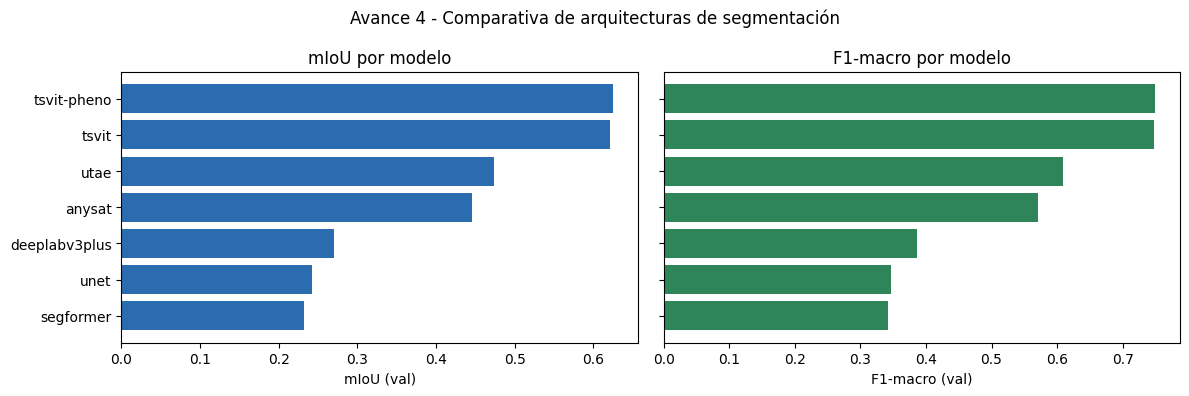

In [3]:
# --- Barplot comparativo: mIoU y F1-macro por modelo ---
# Dos paneles con las dos metricas que rankean (mIoU principal + F1-macro).
# plt.close(fig) tras display evita el doble render de %matplotlib inline.
if table.height:
    _order = table.sort('miou', descending=False)  # ascendente: el mejor arriba en barh
    _models = _order['model'].to_list()
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
    axes[0].barh(_models, _order['miou'].to_list(), color='#2b6cb0')
    axes[0].set_xlabel('mIoU (val)')
    axes[0].set_title('mIoU por modelo')
    axes[1].barh(_models, _order['f1_macro'].to_list(), color='#2f855a')
    axes[1].set_xlabel('F1-macro (val)')
    axes[1].set_title('F1-macro por modelo')
    fig.suptitle('Avance 4 - Comparativa de arquitecturas de segmentación')
    fig.tight_layout()
    display(fig)
    plt.close(fig)
else:
    print('Tabla vacia: nada que graficar todavia.')

In [4]:
# --- Top-2 del equipo: solo se considera `tsvit-pheno` como variante TSViT
#     candidata (la mejor); `tsvit` base queda en la tabla como referencia del
#     aporte de la fenologia, pero no compite por el top-2. El resto del ranking
#     sale por mIoU de la tabla consolidada (data-driven, desde los parquets).
from IPython.display import Markdown, display

if table.height:
    _ranking = table.filter(pl.col("model") != "tsvit")
    _top2 = _ranking.head(2)["model"].to_list()
    _msg = ", ".join(f"`{m}`" for m in _top2)
    display(Markdown(
        f"**Top-2 al momento (por mIoU, contando solo `tsvit-pheno` como "
        f"variante TSViT):** {_msg}. `tsvit` base se reporta en la tabla como "
        f"referencia del aporte de la fenologia, no como candidato."
    ))
else:
    display(Markdown("_Tabla vacia: aun no hay parquets de modelos._"))

**Top-2 al momento (por mIoU, contando solo `tsvit-pheno` como variante TSViT):** `tsvit-pheno`, `utae`. `tsvit` base se reporta en la tabla como referencia del aporte de la fenologia, no como candidato.

## Arquitecturas y reportes visuales por modelo

A continuación se describe cada una de las 6 arquitecturas y se muestran sus reportes visuales. Cada modelo lleva primero una explicación de cómo funciona y luego sus figuras de evaluación sobre el fold de validación.

### Cómo leer las figuras

Cada modelo deja hasta cuatro figuras. Conviene saber qué muestra cada una antes de mirarlas:

- **Curvas de entrenamiento.** Dos líneas por época: la métrica (loss o mIoU) sobre el conjunto de entrenamiento y sobre el de validación. Sirven para ver si el modelo aprende (la curva baja/sube y se estabiliza) y si hay sobreajuste (la de entrenamiento sigue mejorando mientras la de validación se estanca o empeora).
- **IoU por clase.** Un barra por clase de cultivo con su IoU. Es el desglose del mIoU: revela **qué cultivos** reconoce bien el modelo (barras altas) y cuáles le cuestan (barras bajas, normalmente las clases minoritarias o de señal ambigua).
- **Matriz de confusión.** Tabla clase-real (filas) contra clase-predicha (columnas). La **diagonal** son los aciertos; los valores fuera de la diagonal son confusiones, e indican **qué pares de cultivos** se mezclan entre sí (por ejemplo dos cereales de calendario parecido).
- **RGB / verdad / predicción.** Tres paneles del mismo parche: la imagen Sentinel-2 en color, el mapa de cultivos real y el mapa que predijo el modelo. Es la lectura cualitativa: deja ver si los errores son ruido disperso o regiones enteras mal asignadas.

> Nota: no todos los modelos exportaron las cuatro figuras; se muestran las disponibles de cada uno.

In [5]:
# --- Helpers de galeria de figuras (una celda por modelo los usa abajo) ---
from IPython.display import Image, Markdown, display

def _find_fig(key, model):
    # Acepta el nombre exacto y variantes con sufijo (p.ej. anysat -> anysat_fast).
    _exact = FIGURES / f'{key}_{model}.png'
    if _exact.exists():
        return _exact
    _alt = sorted(FIGURES.glob(f'{key}_{model}_*.png'))
    if _alt:
        return _alt[0]
    # Fallback us-025: figuras de DeepLab/TSViT en paper/figures/us-025/ con sus
    # nombres reales (complementa el Drive compartido, no lo reemplaza).
    _US025_FIG = Path('paper/figures/us-025')
    _US025_MAP = {
        ('confusion', 'deeplabv3plus'): 'deeplab_confusion_semantic18.png',
        ('samples', 'deeplabv3plus'): 'deeplab_semantic18_pred_example_0.png',
        ('confusion', 'tsvit'): 'tsvit_confusion_tsvit-pheno.png',
        ('samples', 'tsvit'): 'tsvit_pred_example_0.png',
    }
    _name = _US025_MAP.get((key, model))
    if _name:
        _p = _US025_FIG / _name
        if _p.exists():
            return _p
    return None

_FIG_TYPES = [('curves', 'Curvas de entrenamiento'),
              ('per_class_iou', 'IoU por clase'),
              ('confusion', 'Matriz de confusion'),
              ('samples', 'RGB / verdad / prediccion')]

def show_model_figs(model):
    """Muestra las figuras disponibles de un modelo (las que existan de los 4 tipos)."""
    shown = False
    for key, label in _FIG_TYPES:
        fpath = _find_fig(key, model)
        if fpath is not None:
            display(Markdown(f'**{label}**'))
            display(Image(filename=str(fpath)))
            shown = True
    if not shown:
        display(Markdown(f'_Aun no hay figuras para `{model}` (correr su notebook de entrenamiento)._'))

### U-Net ResNet-50 (modelo #1)

**U-Net** es la CNN encoder-decoder clásica de segmentación. El **encoder** (aquí un **ResNet-50** preentrenado) va reduciendo la resolución mientras extrae features cada vez más abstractas; el **decoder** la recupera paso a paso, y las **skip connections** reinyectan en cada nivel del decoder las features de alta resolución del encoder, para no perder el detalle fino de los bordes de parcela.

Es un segmentador **2D**: trabaja sobre una imagen, no sobre la serie temporal. Aquí actúa como línea base "CNN fuerte sin tiempo": un encoder potente (ResNet-50) sobre una composición de la temporada.

**Resultados:** mIoU 0.24 en las 18 clases planas (0.45 sobre los 6 grupos HCAT). Queda por debajo de los modelos temporales: con una sola vista de la temporada, ni un encoder grande separa cultivos que solo se distinguen por su evolución en el tiempo.

**Curvas de entrenamiento**

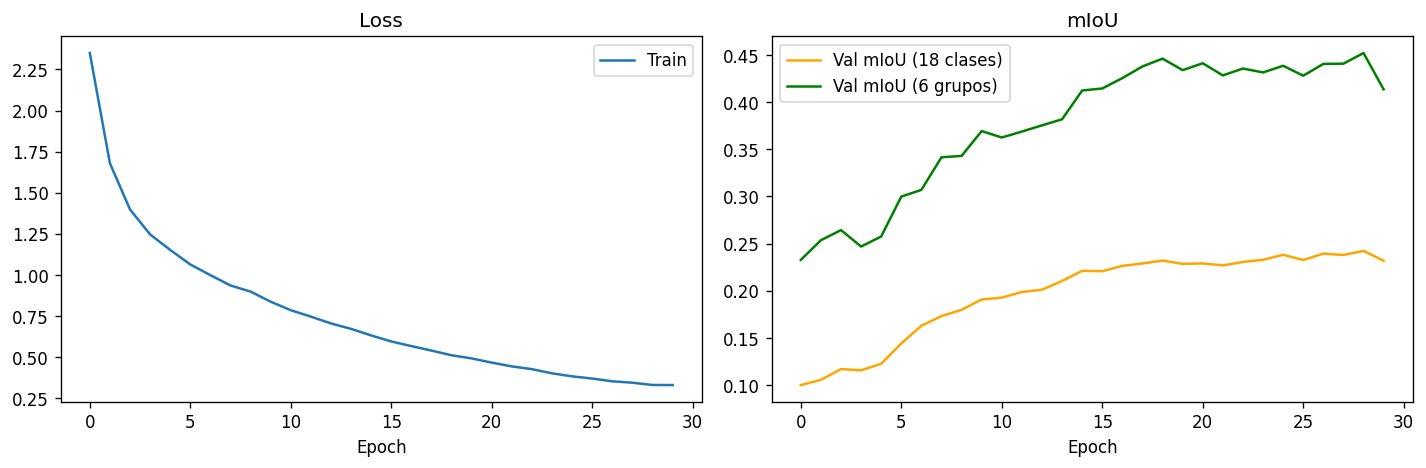

**IoU por clase**

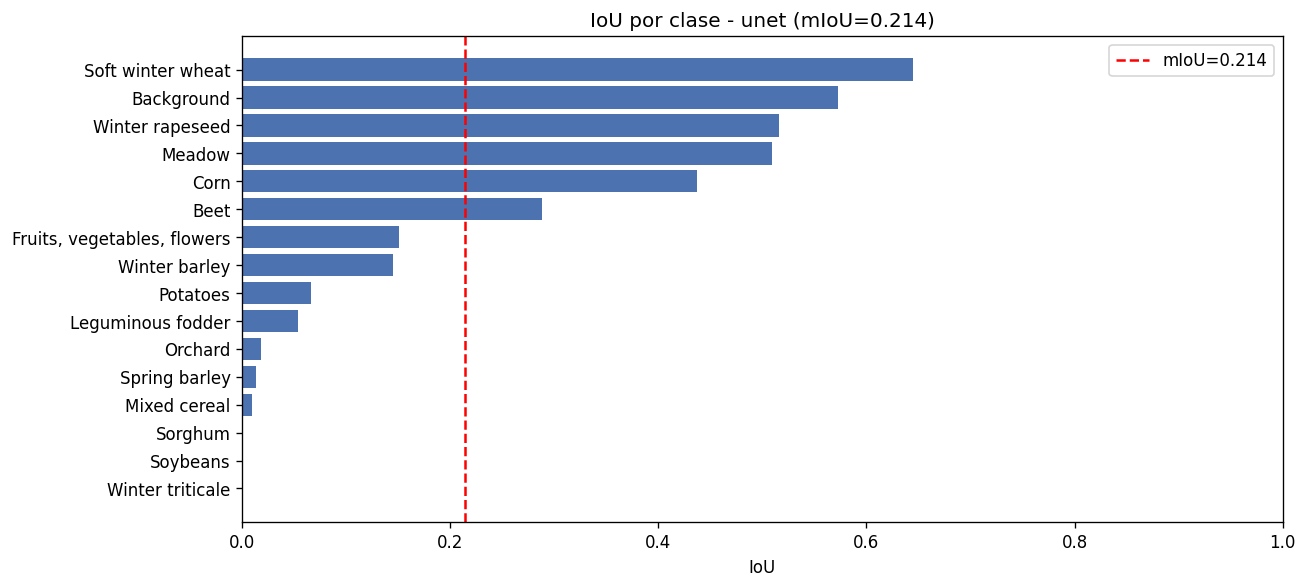

**Matriz de confusion**

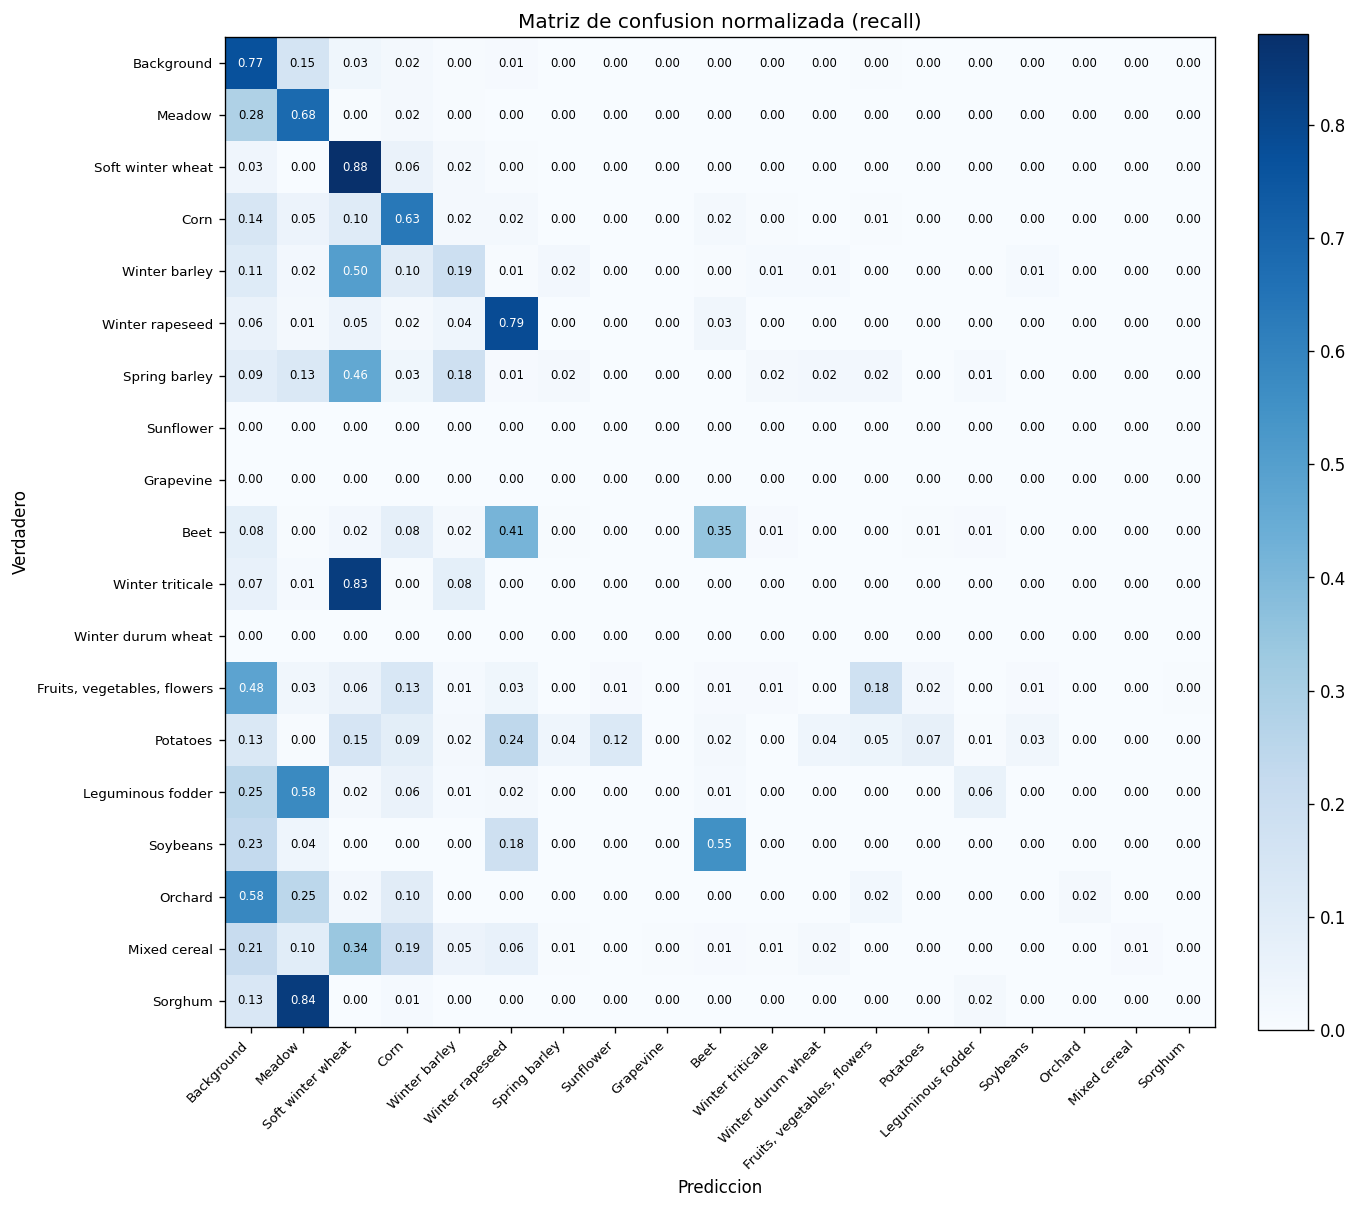

**RGB / verdad / prediccion**

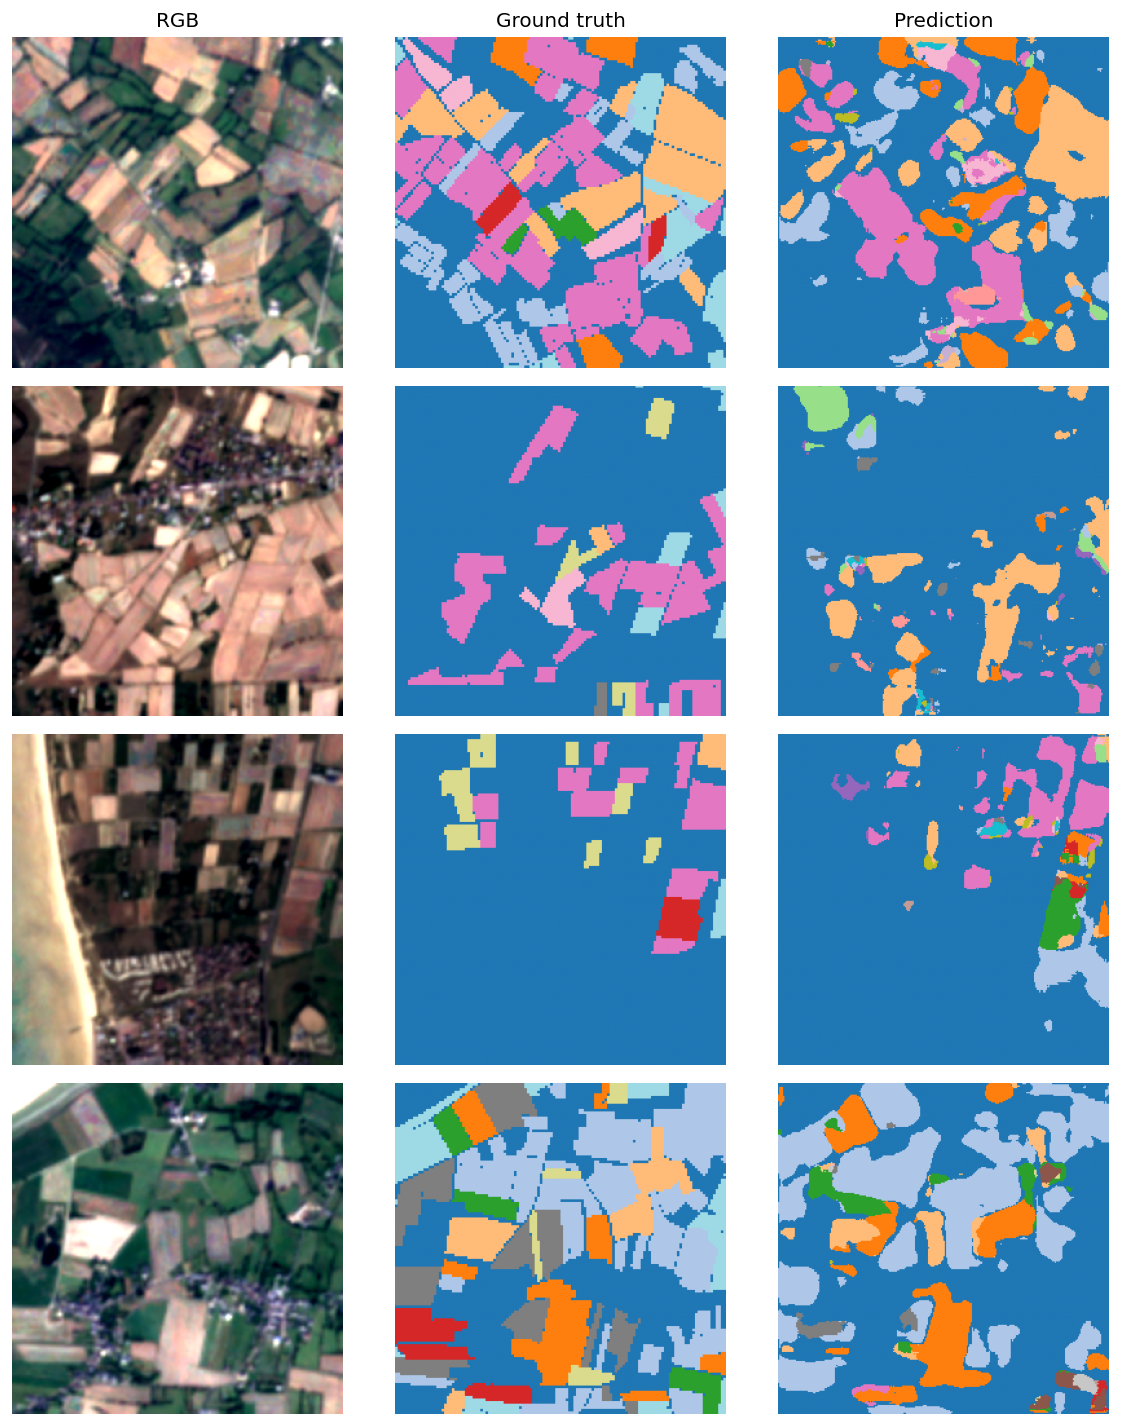

In [6]:
show_model_figs('unet')

### AnySat congelado + cabeza lineal (modelo #6)

**AnySat** (Astruc et al. 2024) es un *foundation model* de observación de la Tierra: una red grande preentrenada que ya consume series temporales multiespectrales y produce features densas. Aquí se usa con el **encoder congelado** (sus pesos no se actualizan, `requires_grad=False`) y solo se entrena una **cabeza ligera** (una convolución 1x1 que mapea las features del encoder a las clases de cultivo). Es la estrategia de *transfer learning* más económica: aprovecha todo lo que el modelo ya aprendió y solo ajusta los ~30 mil parámetros de la cabeza.

**Resultados:** mIoU 0.45 sobre los 6 grupos HCAT (0.45 en 18 clases planas). Notable para entrenar tan poco: las features del foundation model ya separan bien los cultivos, y eso lo vuelve la opción más eficiente en cómputo del conjunto.

**Curvas de entrenamiento**

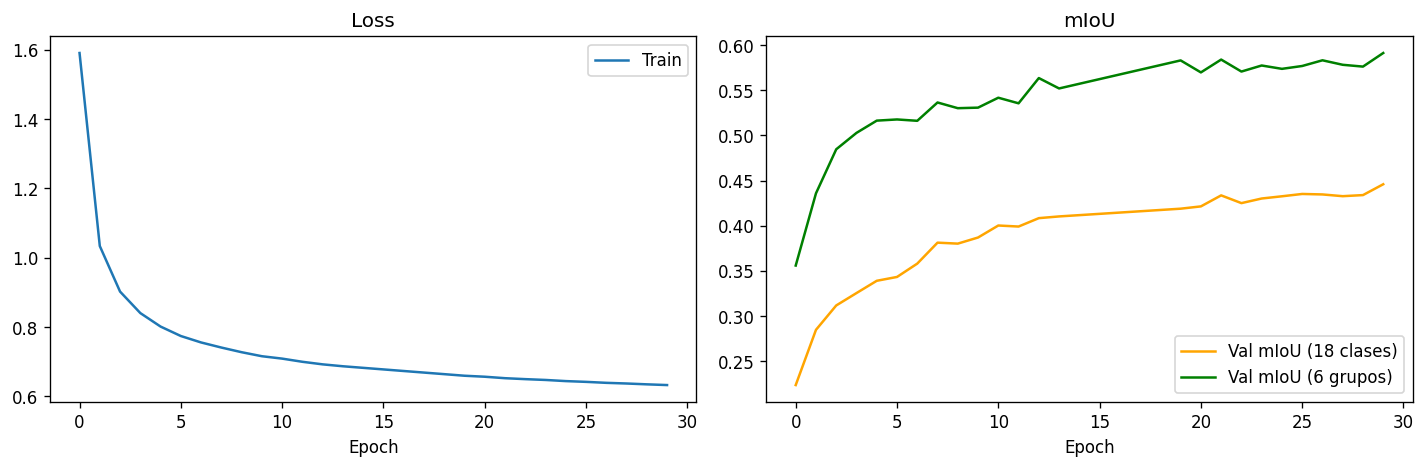

**IoU por clase**

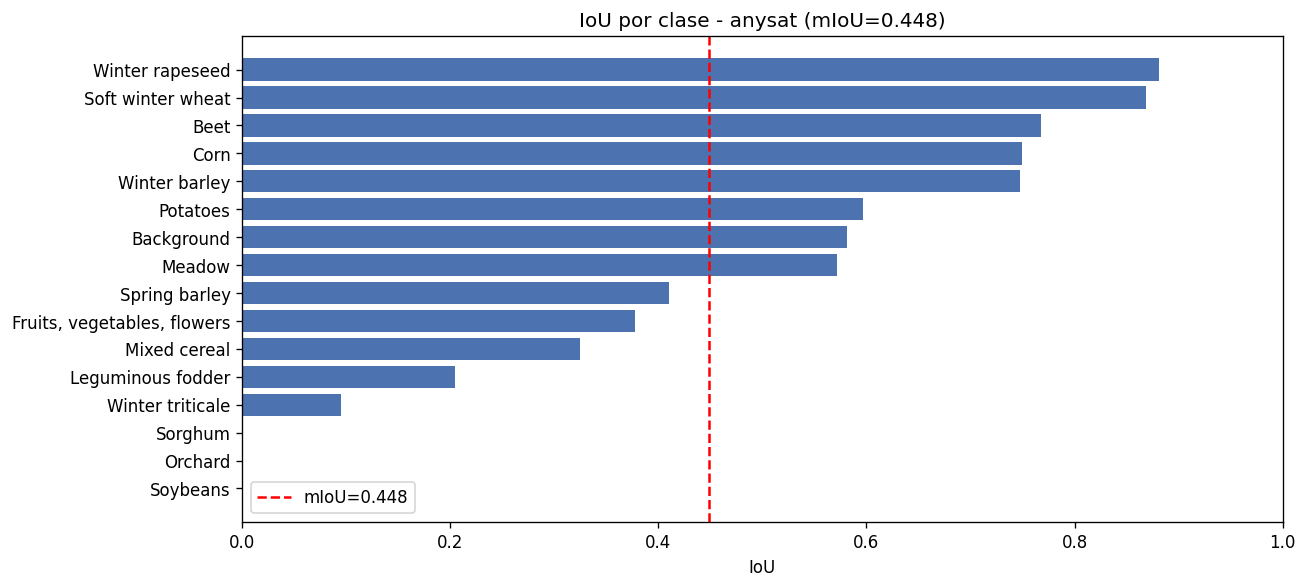

**Matriz de confusion**

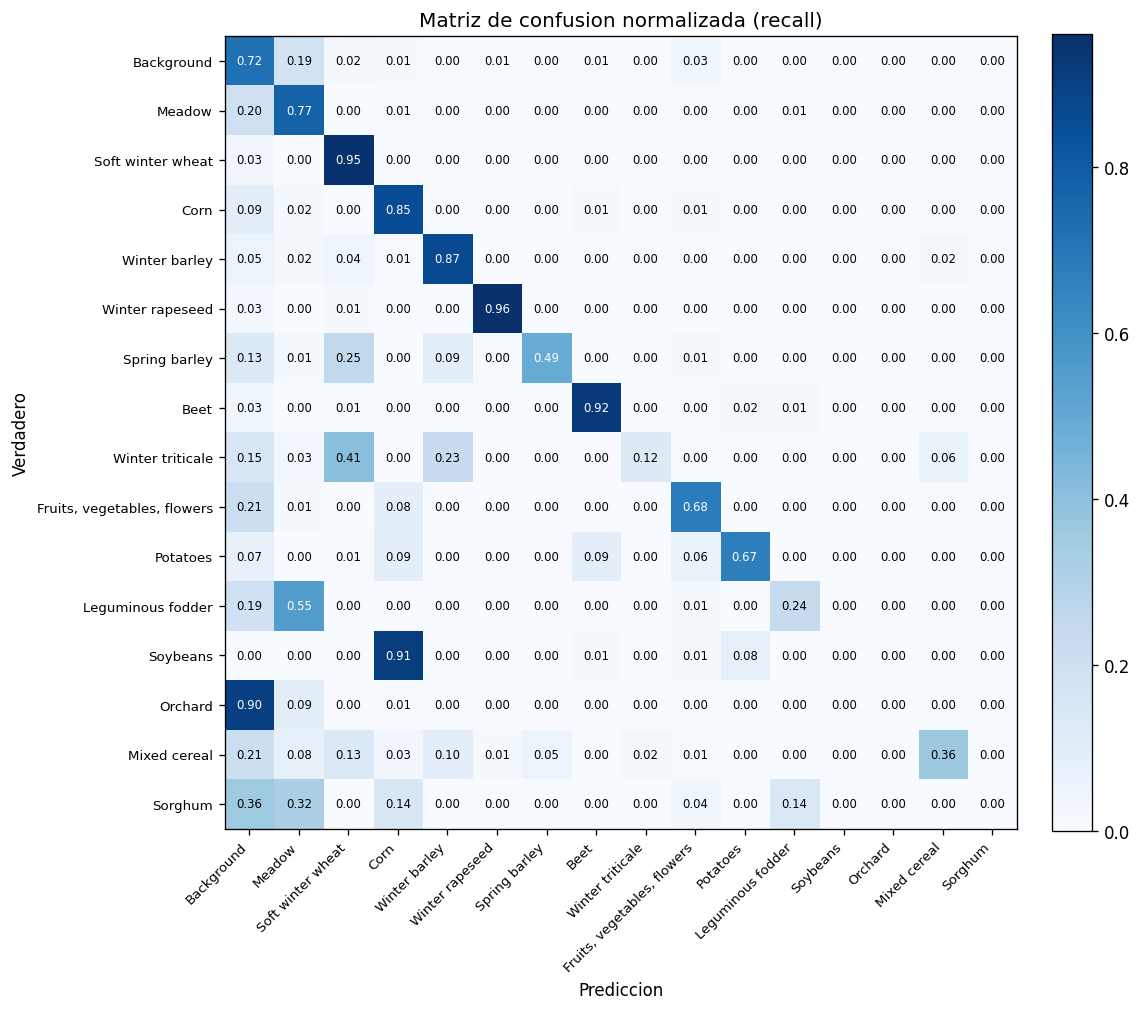

**RGB / verdad / prediccion**

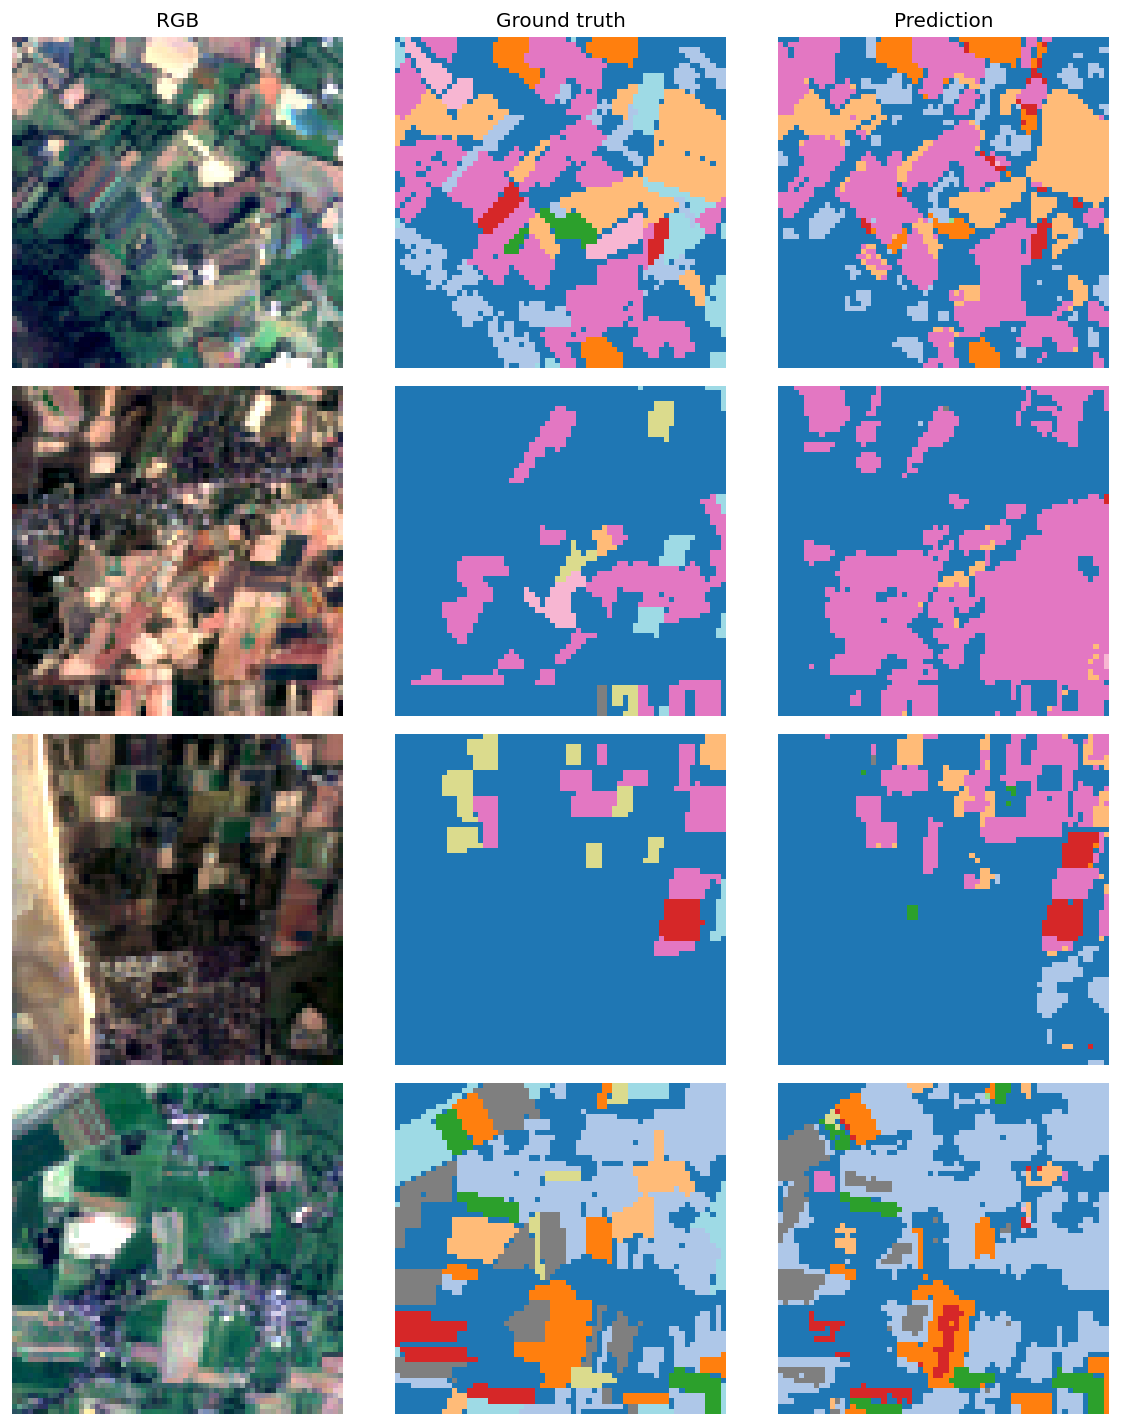

In [7]:
show_model_figs('anysat')

### DeepLabv3+ MobileNet (modelo #2)

**DeepLabv3+** es una CNN encoder-decoder cuyo núcleo es el módulo **ASPP** (Atrous Spatial Pyramid Pooling): un banco de convoluciones dilatadas a varias escalas que captura contexto fino y grueso sin perder resolución espacial. El encoder es **MobileNetV3-Large**, una columna vertebral ligera que permite entrenar incluso sin GPU dedicada.

Es un segmentador **2D**: no consume la serie temporal completa, sino una composición de la temporada (el dataset colapsa las `T` fechas Sentinel-2 por **mediana por píxel** antes del forward). Es deliberadamente el punto de comparación "sin tiempo" frente a los modelos temporales.

**Resultados (fold 4, 482 parches):** mIoU 0.2709 / F1-macro 0.3864 en las 18 clases; con la agrupación HCAT de 6 grupos sube a mIoU 0.4682 / F1-macro 0.6009. La brecha frente a TSViT cuantifica cuánto aporta leer el calendario de crecimiento. Detalle en `notebooks/segmentation/5a_deeplabv3plus.ipynb`.

**Curvas de entrenamiento**

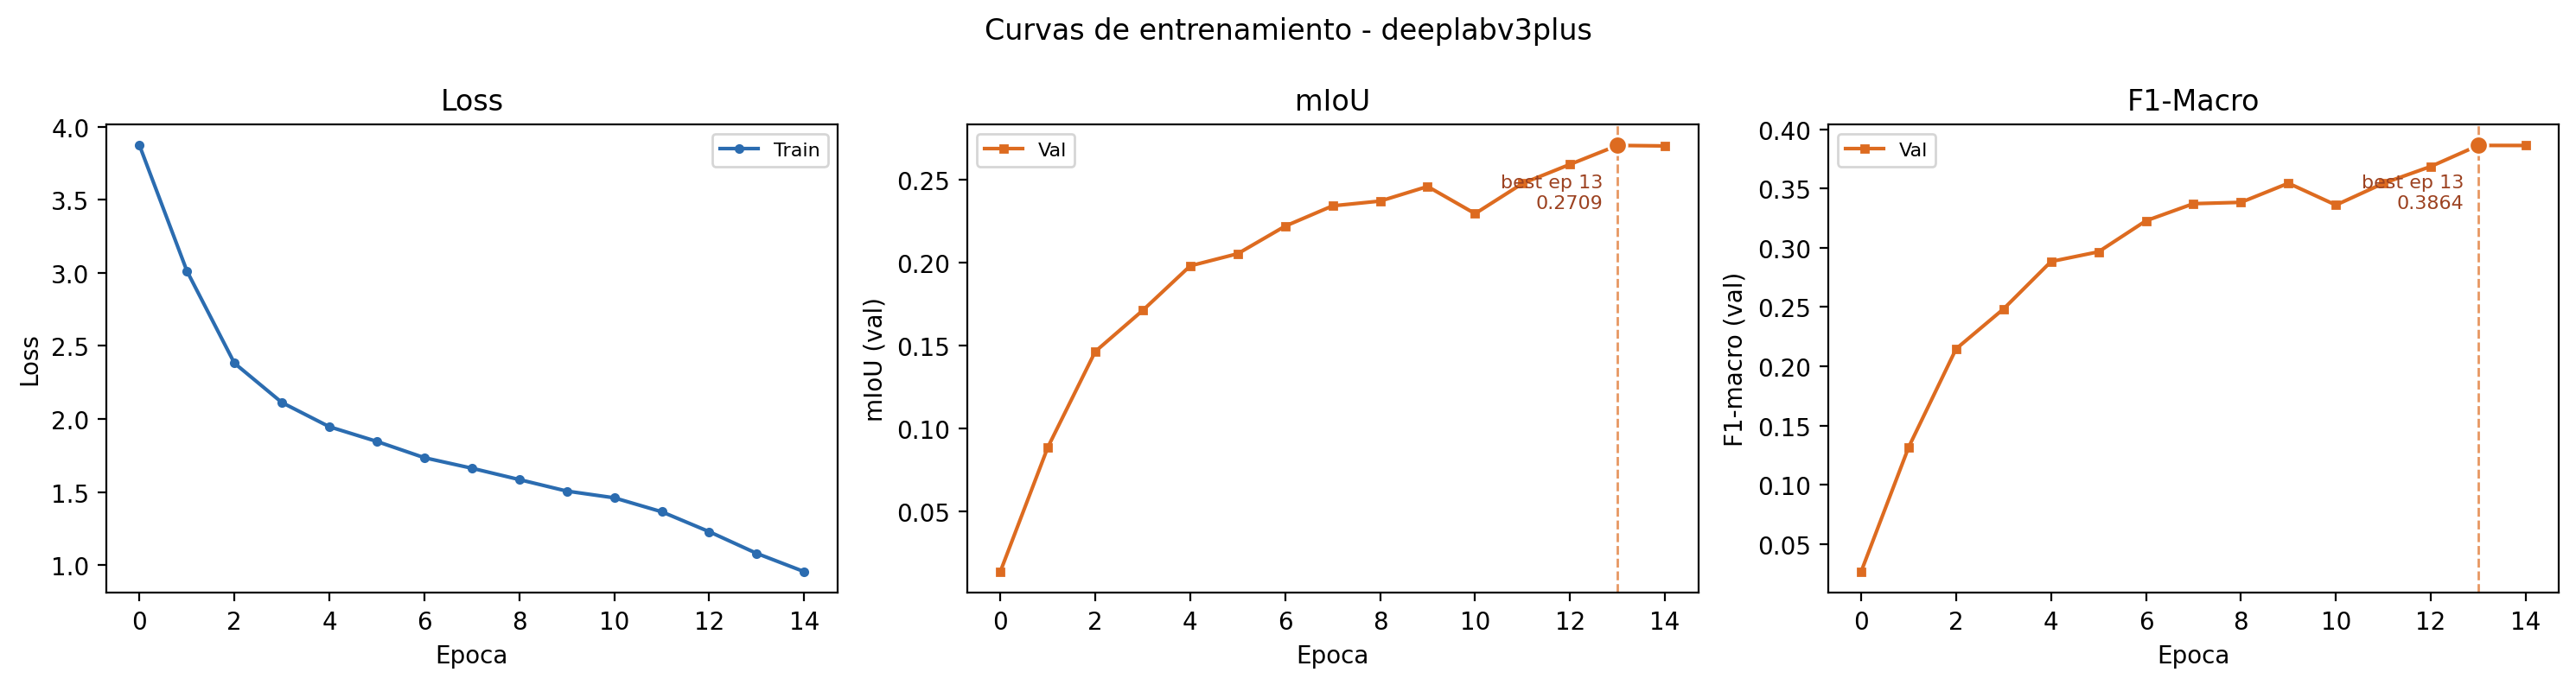

**IoU por clase**

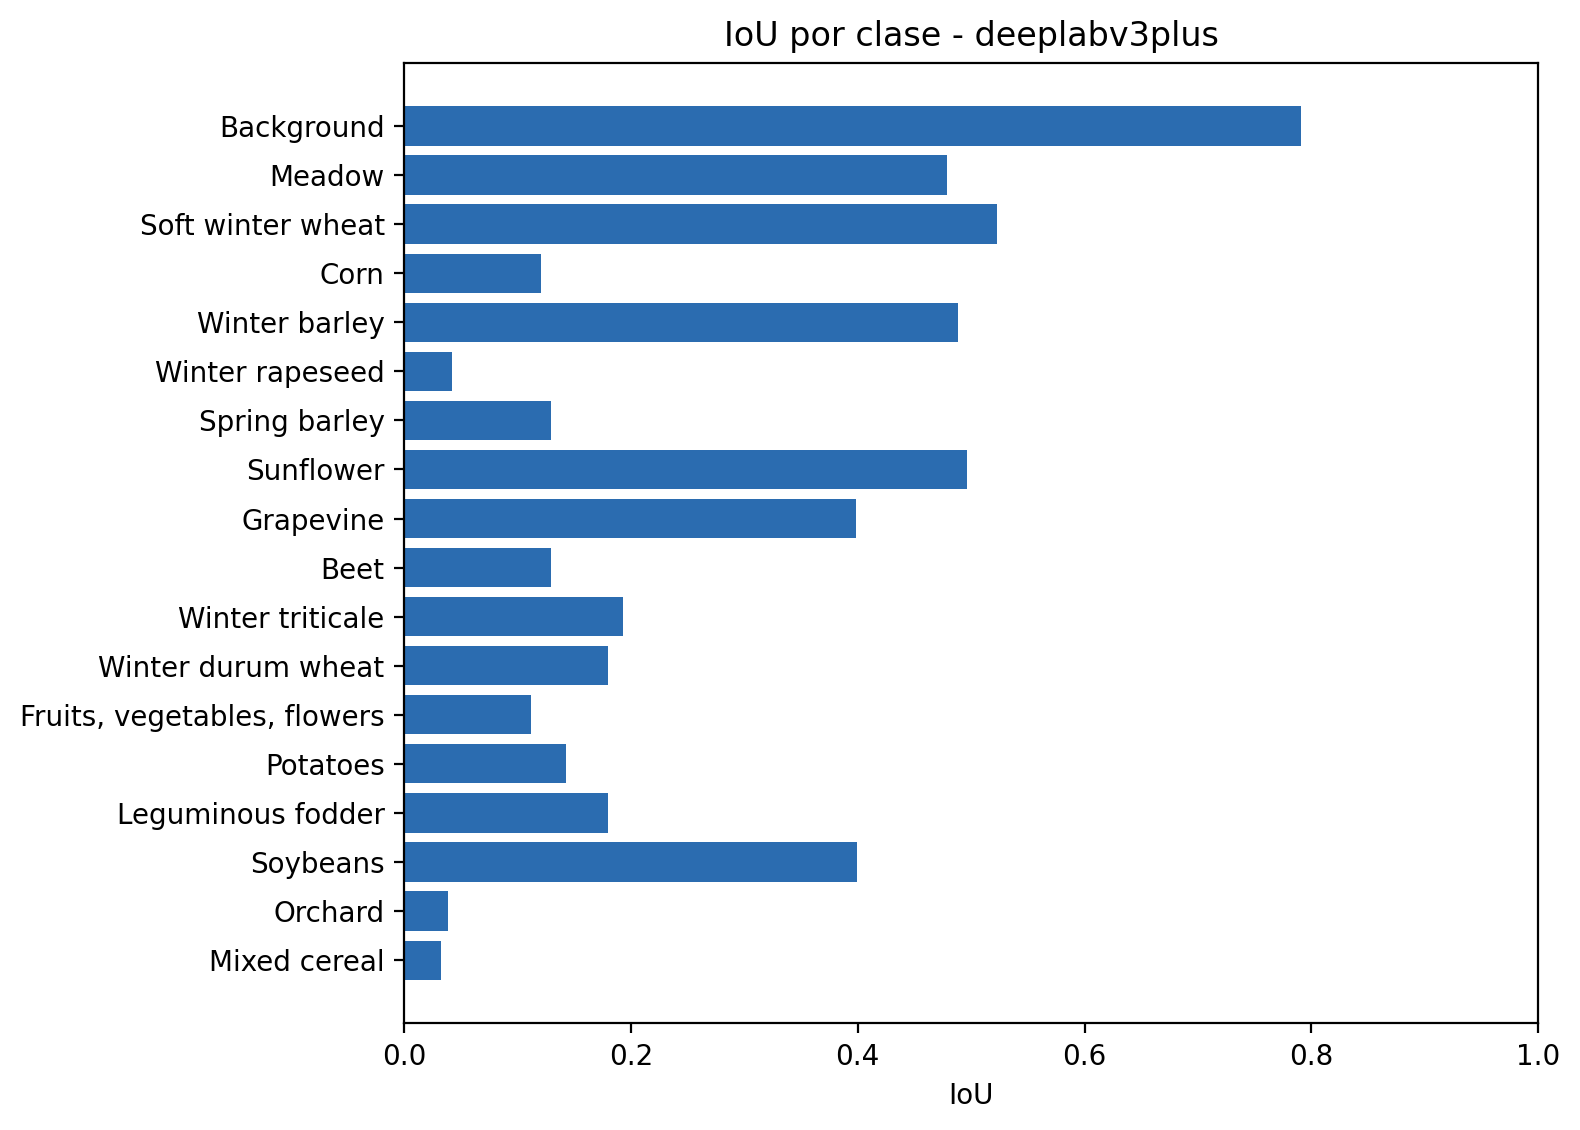

**Matriz de confusion**

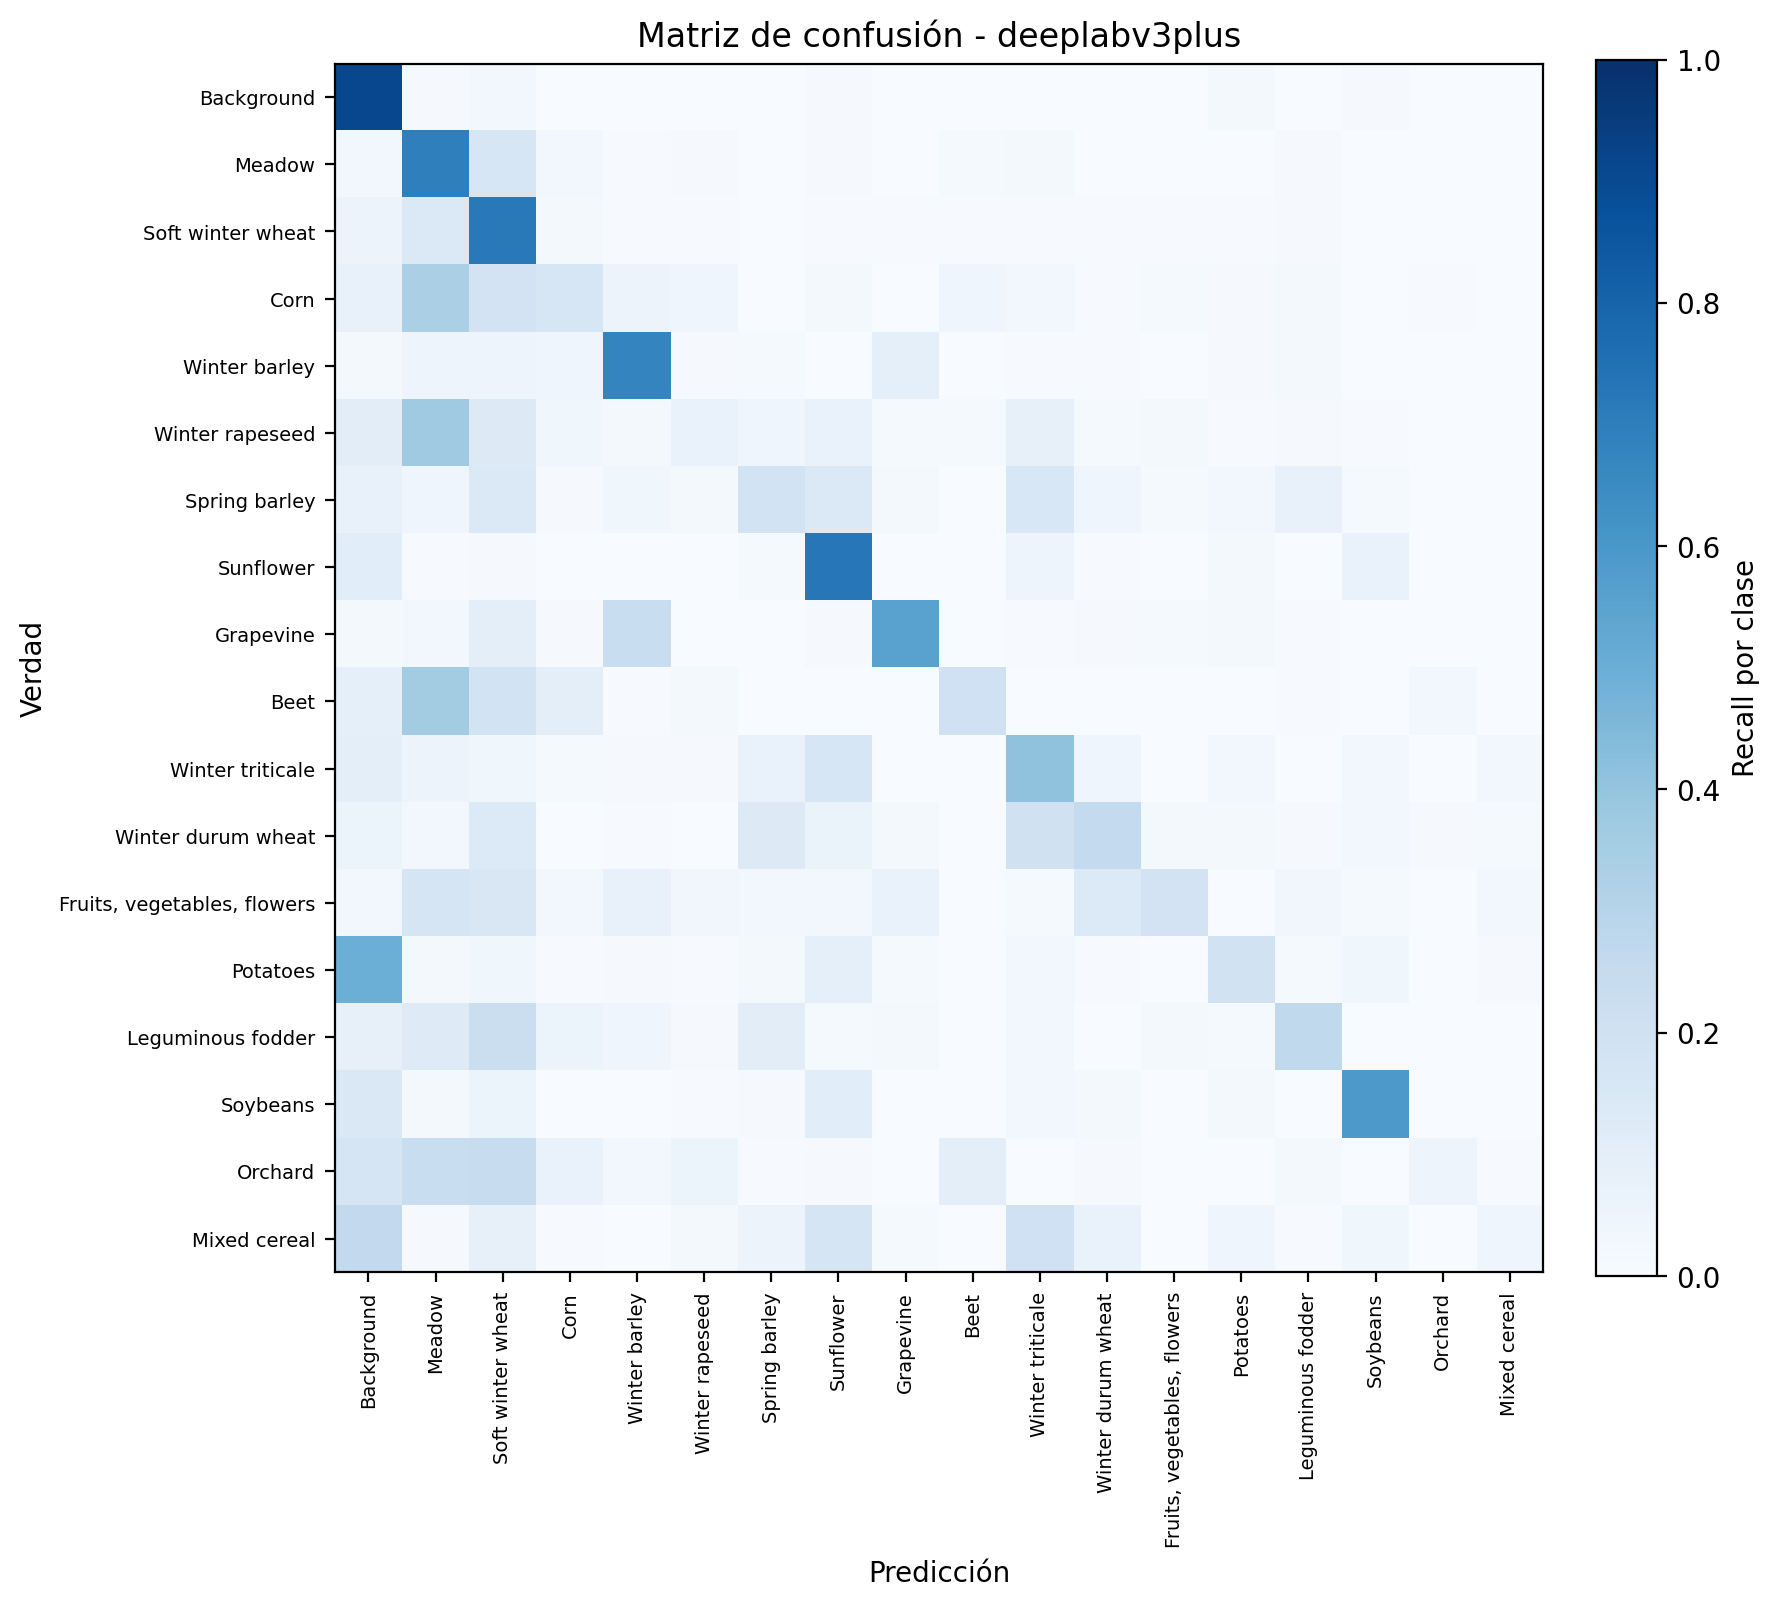

**RGB / verdad / prediccion**

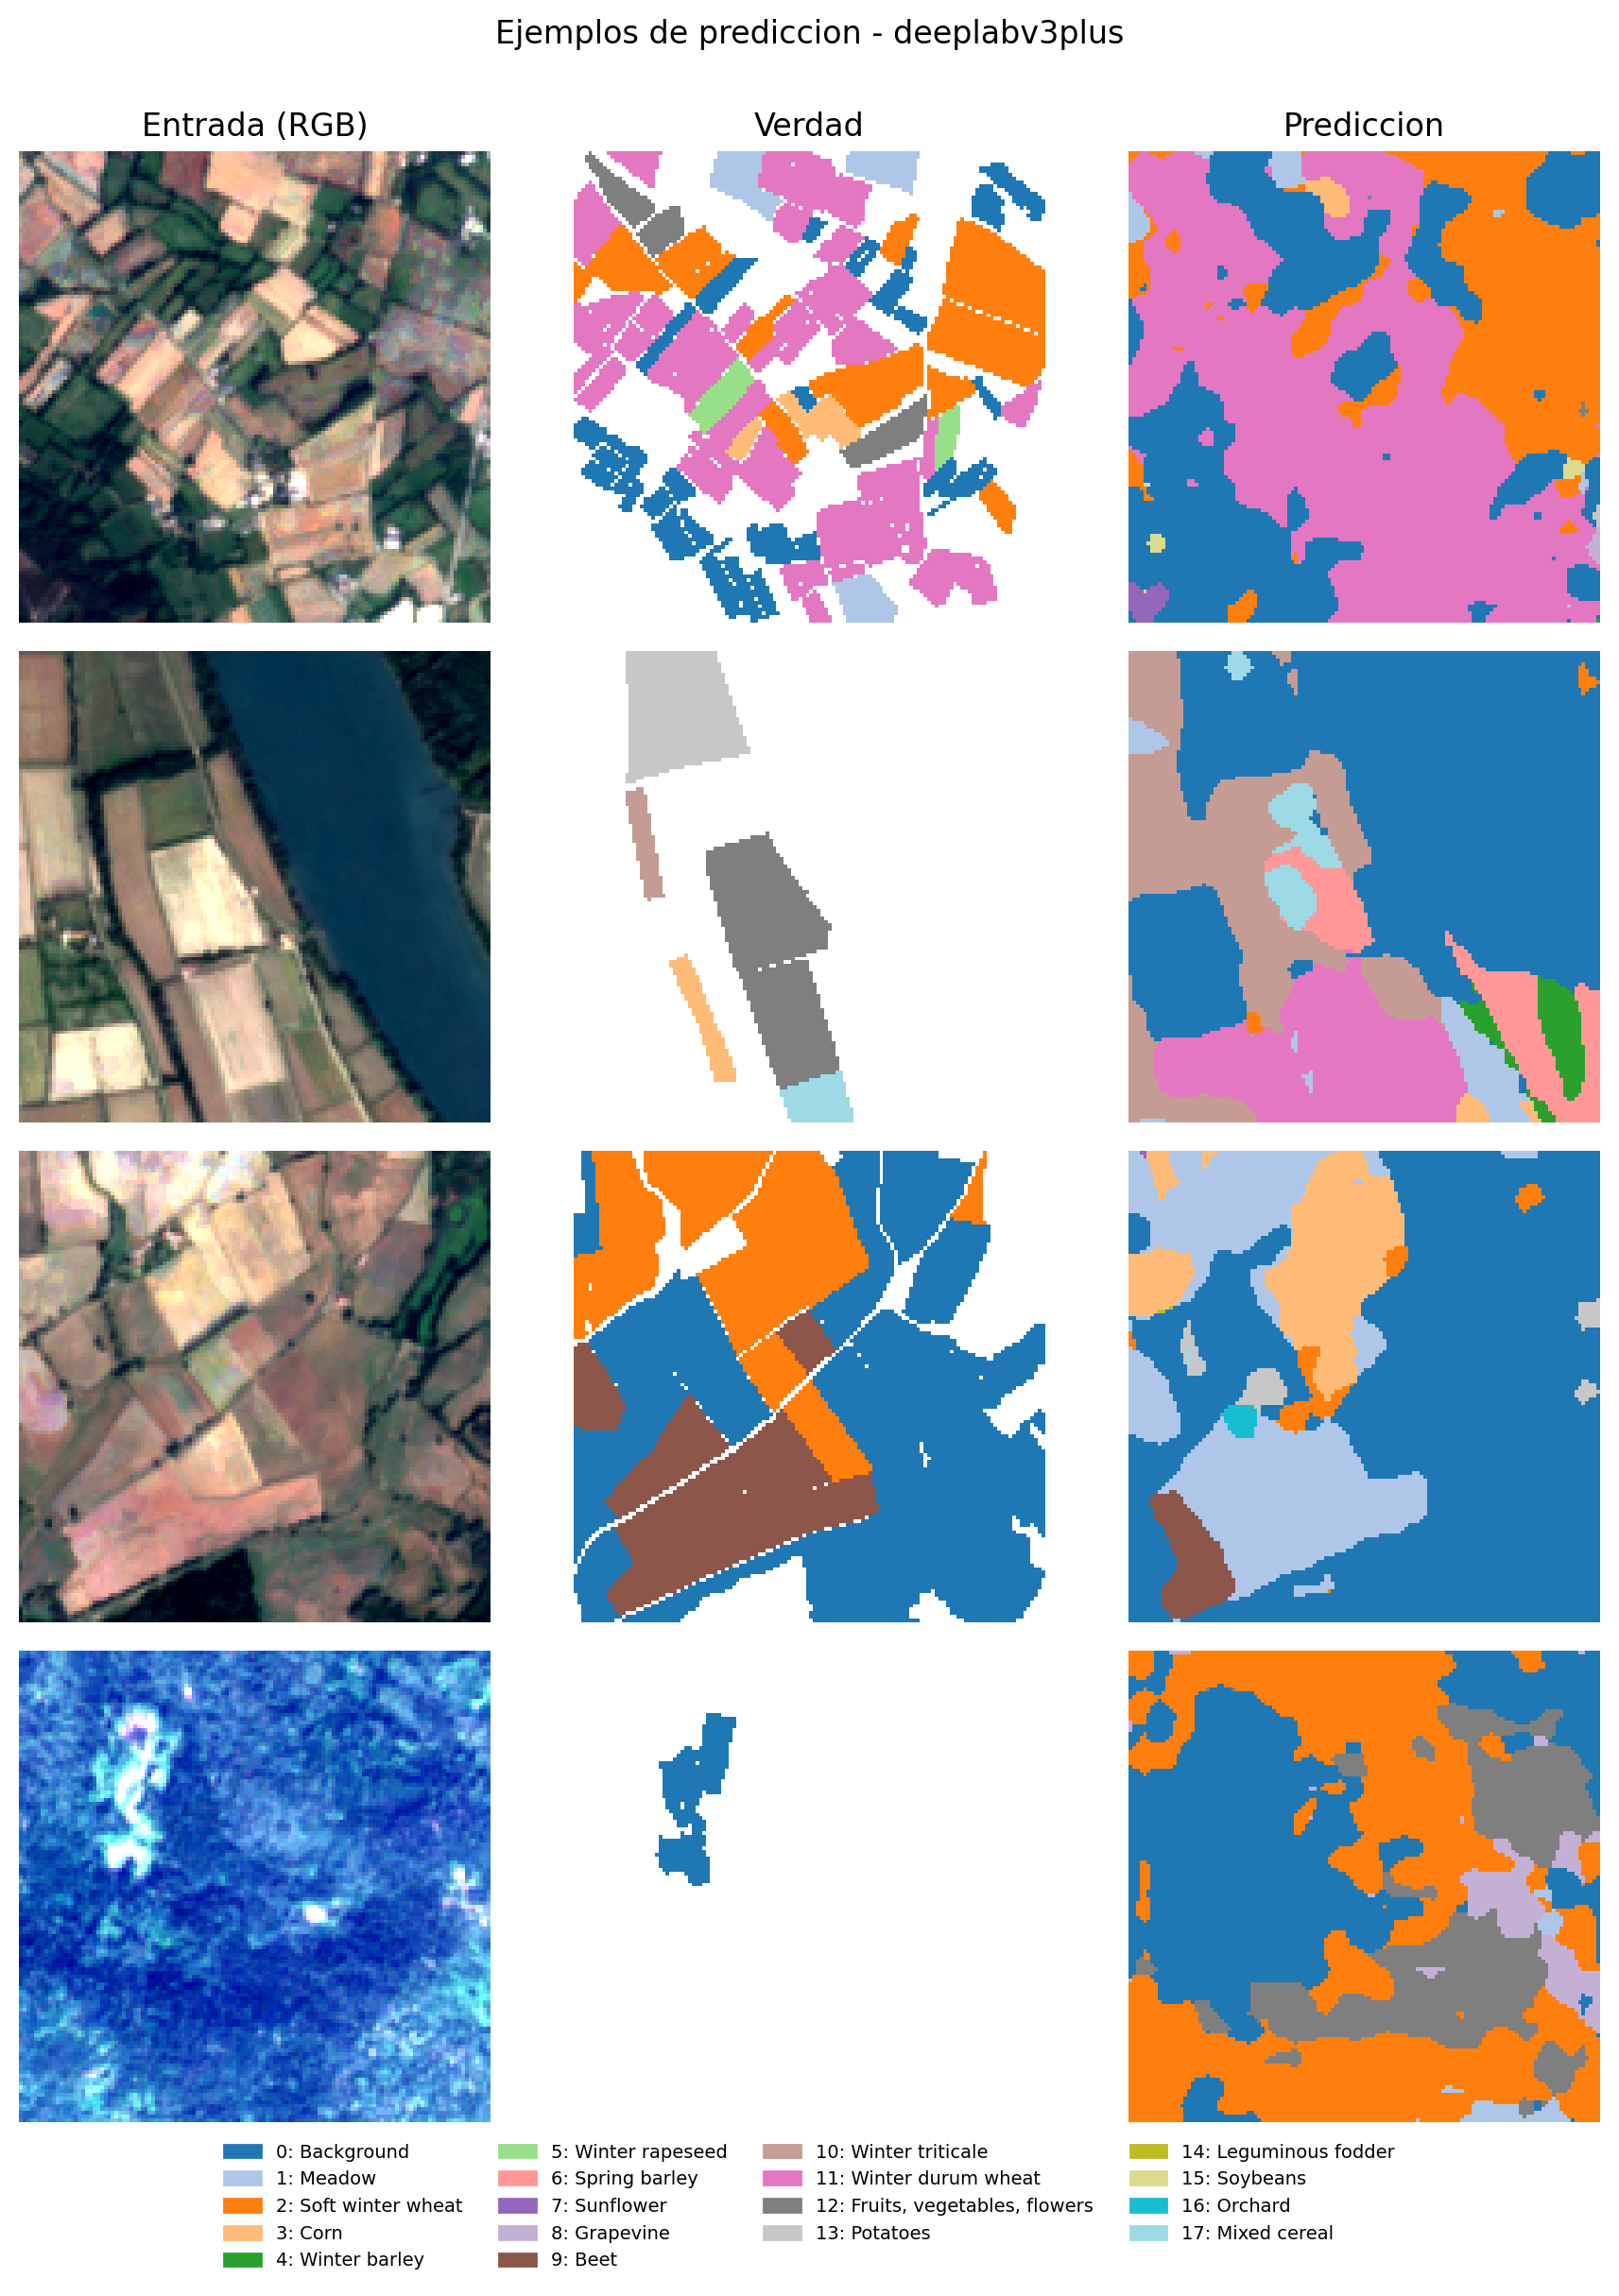

In [8]:
show_model_figs('deeplabv3plus')

### SegFormer-B0 (modelo #3)

**SegFormer** es un transformer de segmentación con un encoder jerárquico (produce features a 4 escalas, anchos [32, 64, 160, 256] en la variante B0) y un decoder MLP muy ligero que las fusiona. A diferencia de los ViT clásicos, **no usa positional encoding explícito**: la posición se aprende dentro de las convoluciones del propio transformer, lo que lo hace robusto a cambios de resolución. B0 es la variante más pequeña de la familia.

Es un segmentador **2D** (espacial, sin tiempo), igual que U-Net y DeepLabv3+, pero con backbone transformer en vez de CNN. Predice las 20 clases de PASTIS-R.

**Resultados:** mIoU 0.2369 sobre los 6 grupos HCAT (0.2325 en plano). Es de los más bajos del conjunto: al ser puramente espacial y la variante más pequeña, le cuesta separar cultivos sin la información temporal.

**Curvas de entrenamiento**

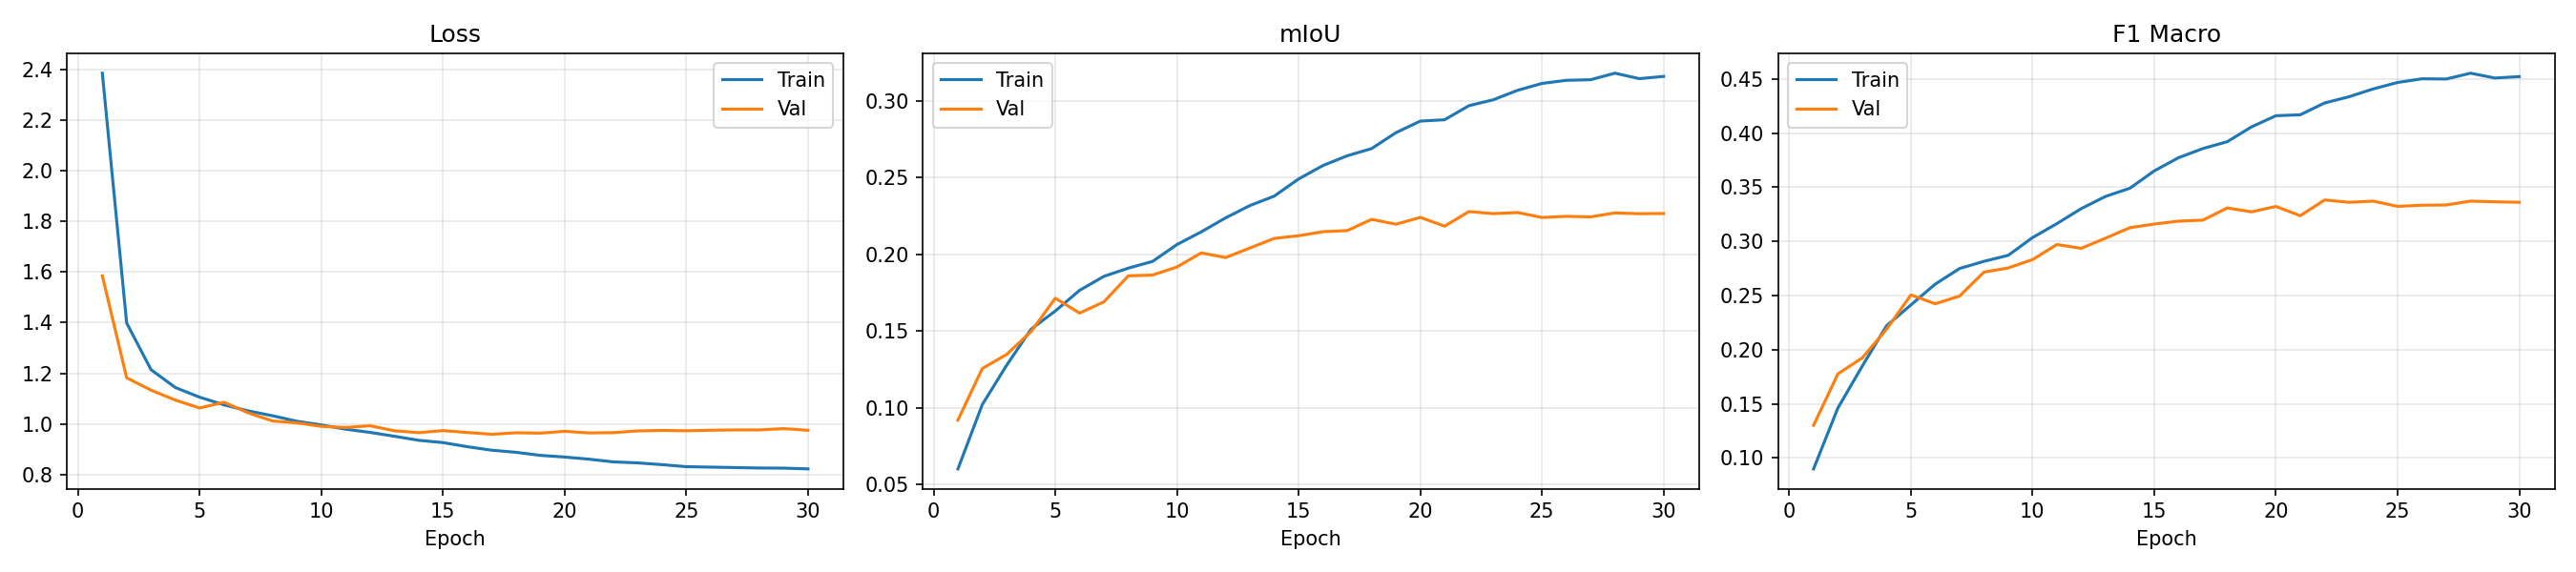

**IoU por clase**

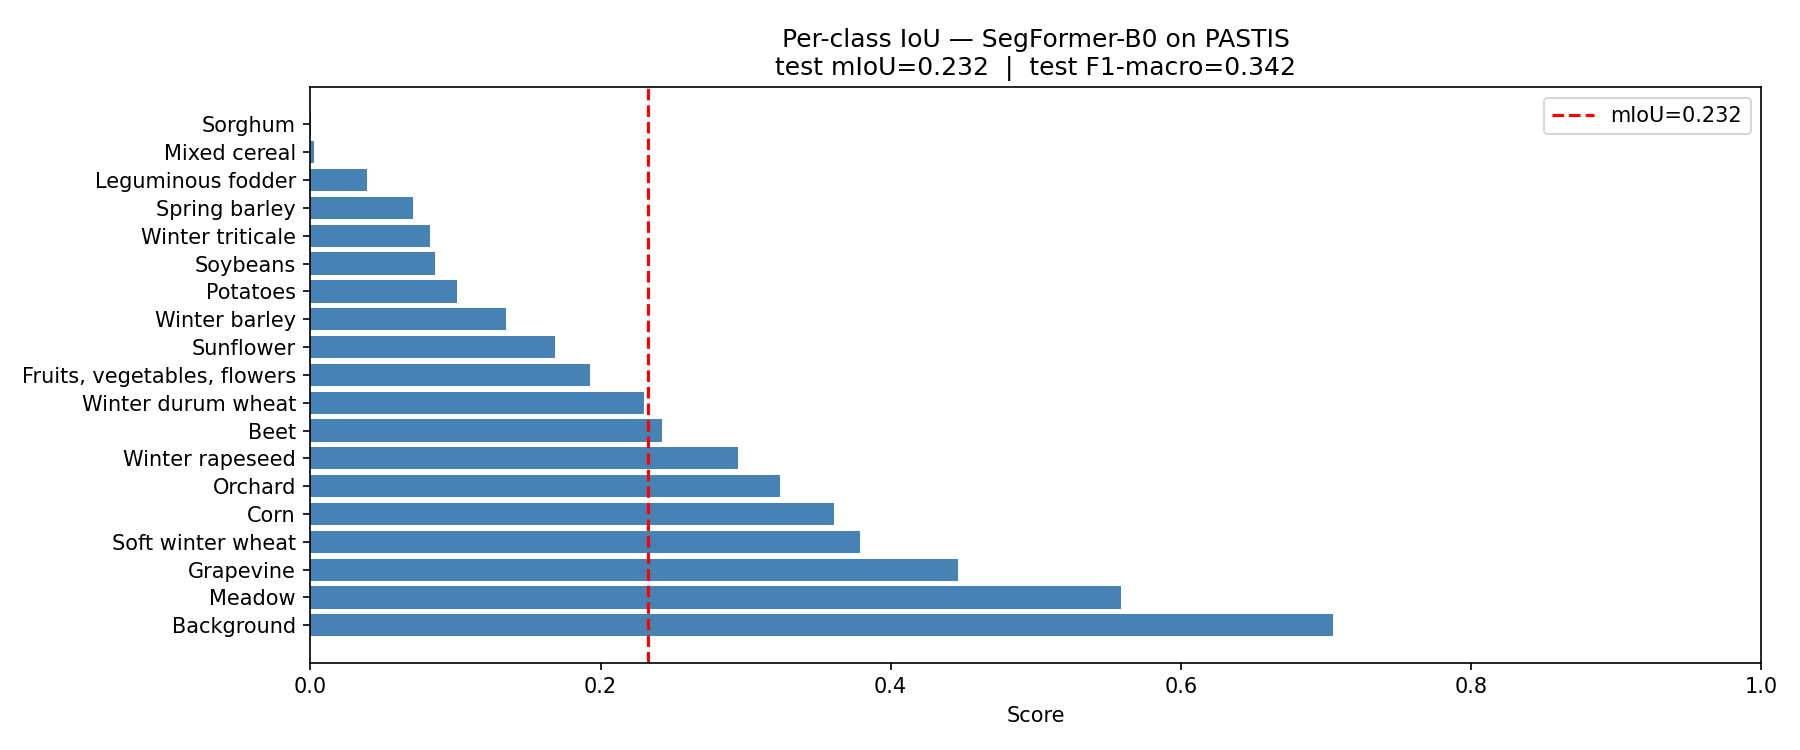

**Matriz de confusion**

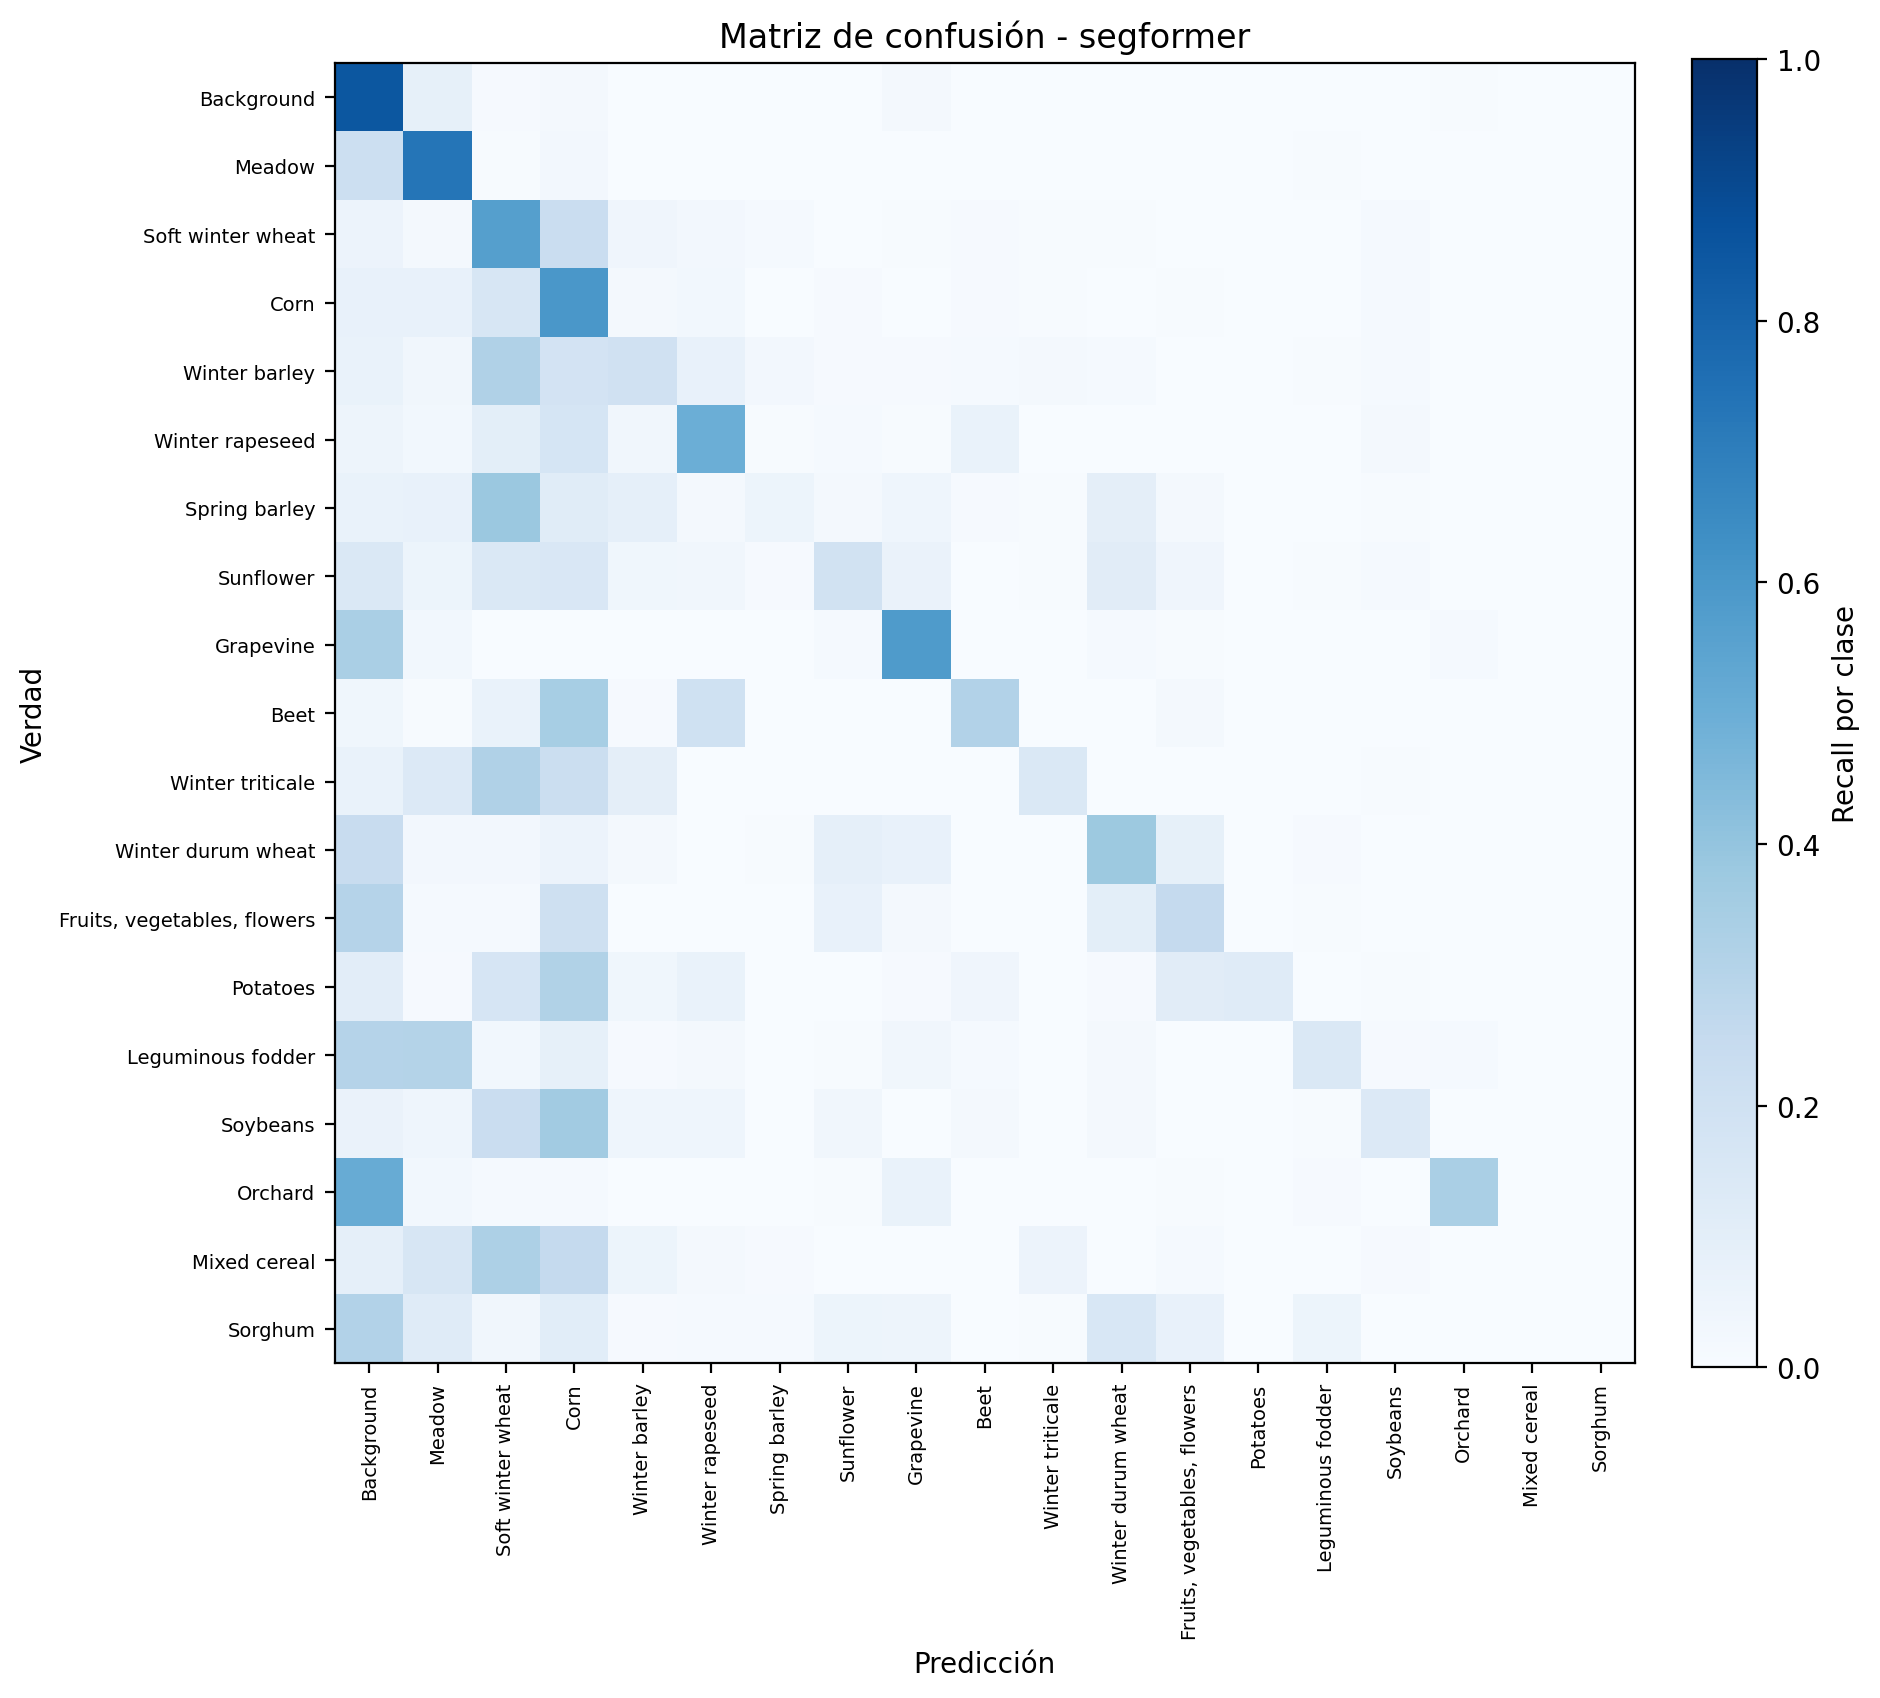

**RGB / verdad / prediccion**

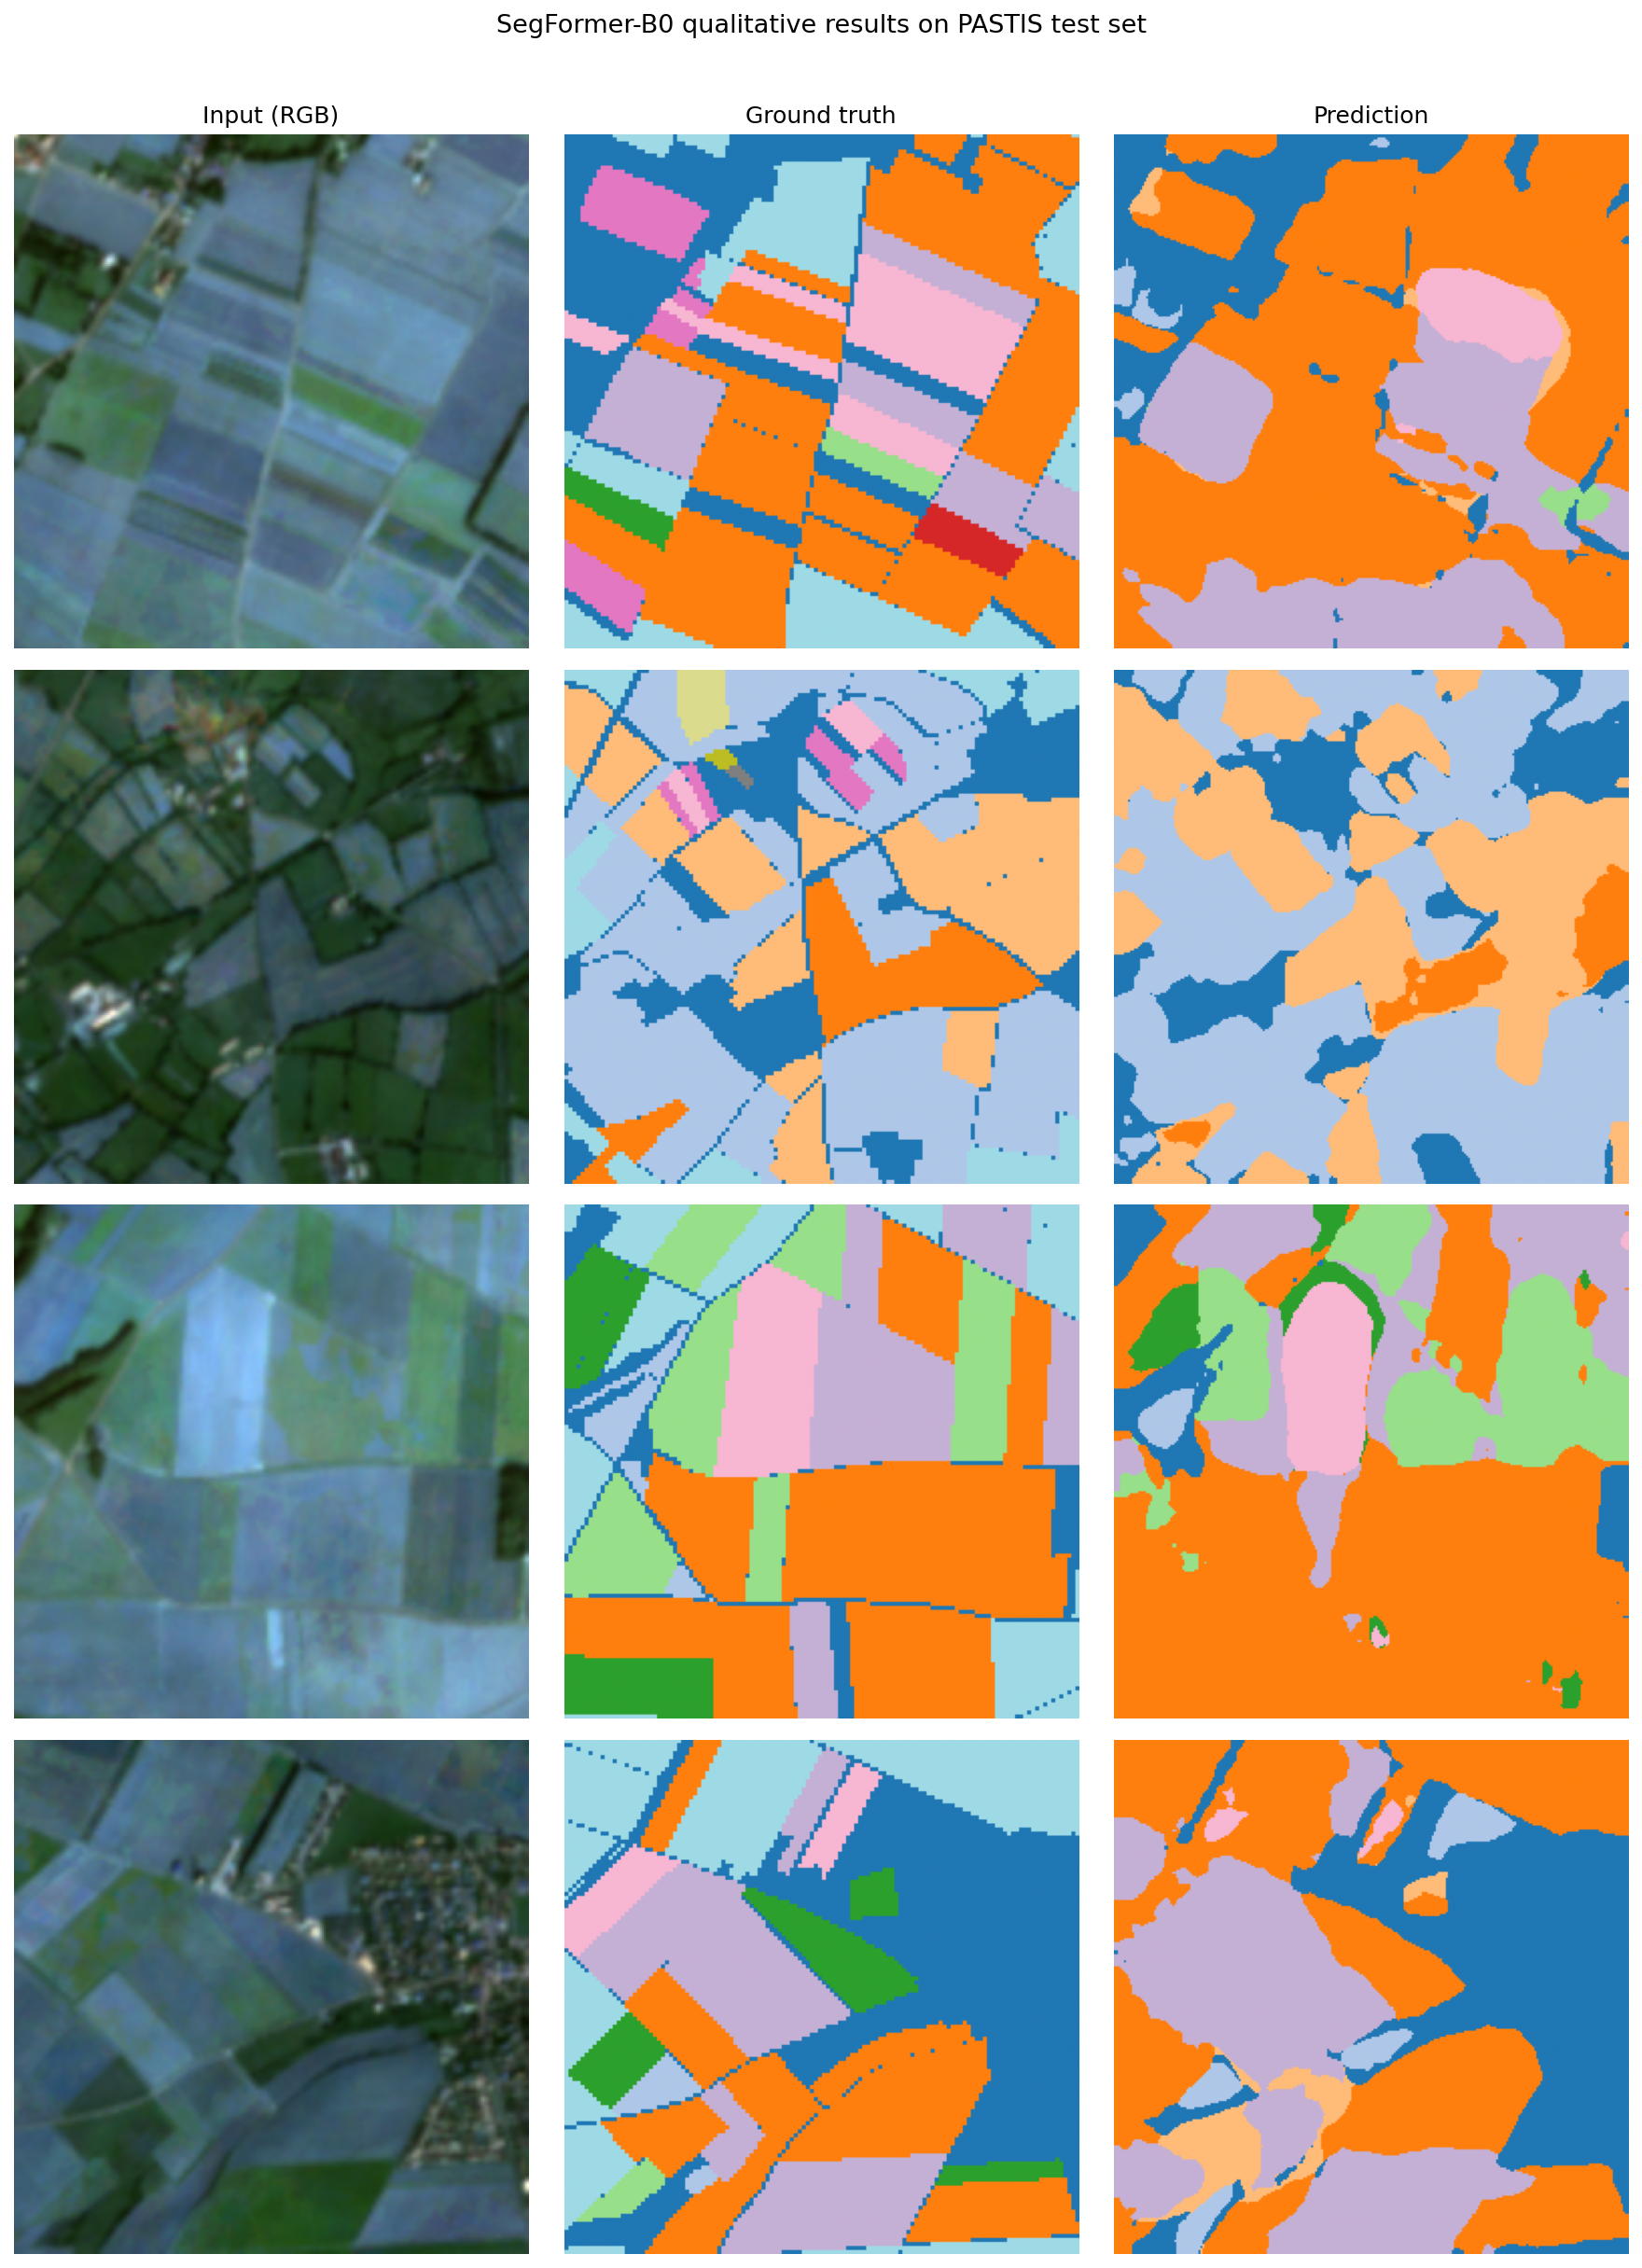

In [9]:
show_model_figs('segformer')

### U-TAE (modelo #4)

**U-TAE** (Garnot y Landrieu 2021) es el primer modelo **temporal** del conjunto: combina un U-Net con un **L-TAE** (Lightweight Temporal Attention Encoder). Cada fecha de la serie Sentinel-2 pasa por el encoder U-Net de forma independiente; en el cuello de botella, el L-TAE **agrega la dimensión temporal por atención** (aprende qué fechas pesan más para cada píxel), y esos mismos pesos de atención re-ponderan las skip connections antes del decoder. Así la reconstrucción espacial conserva el detalle fino **y** la información de cuándo ocurre cada cosa.

A diferencia de TSViT (transformer puro), U-TAE es un híbrido CNN + atención temporal: más ligero y rápido de entrenar, pero con menos capacidad de modelar dependencias temporales largas.

**Resultados:** mIoU 0.4742 / F1-macro 0.6087 (0.4998 sobre 6 grupos HCAT). Es el segundo mejor del top-2: la atención temporal lo pone muy por encima de los modelos 2D, aunque por debajo de TSViT.

**Curvas de entrenamiento**

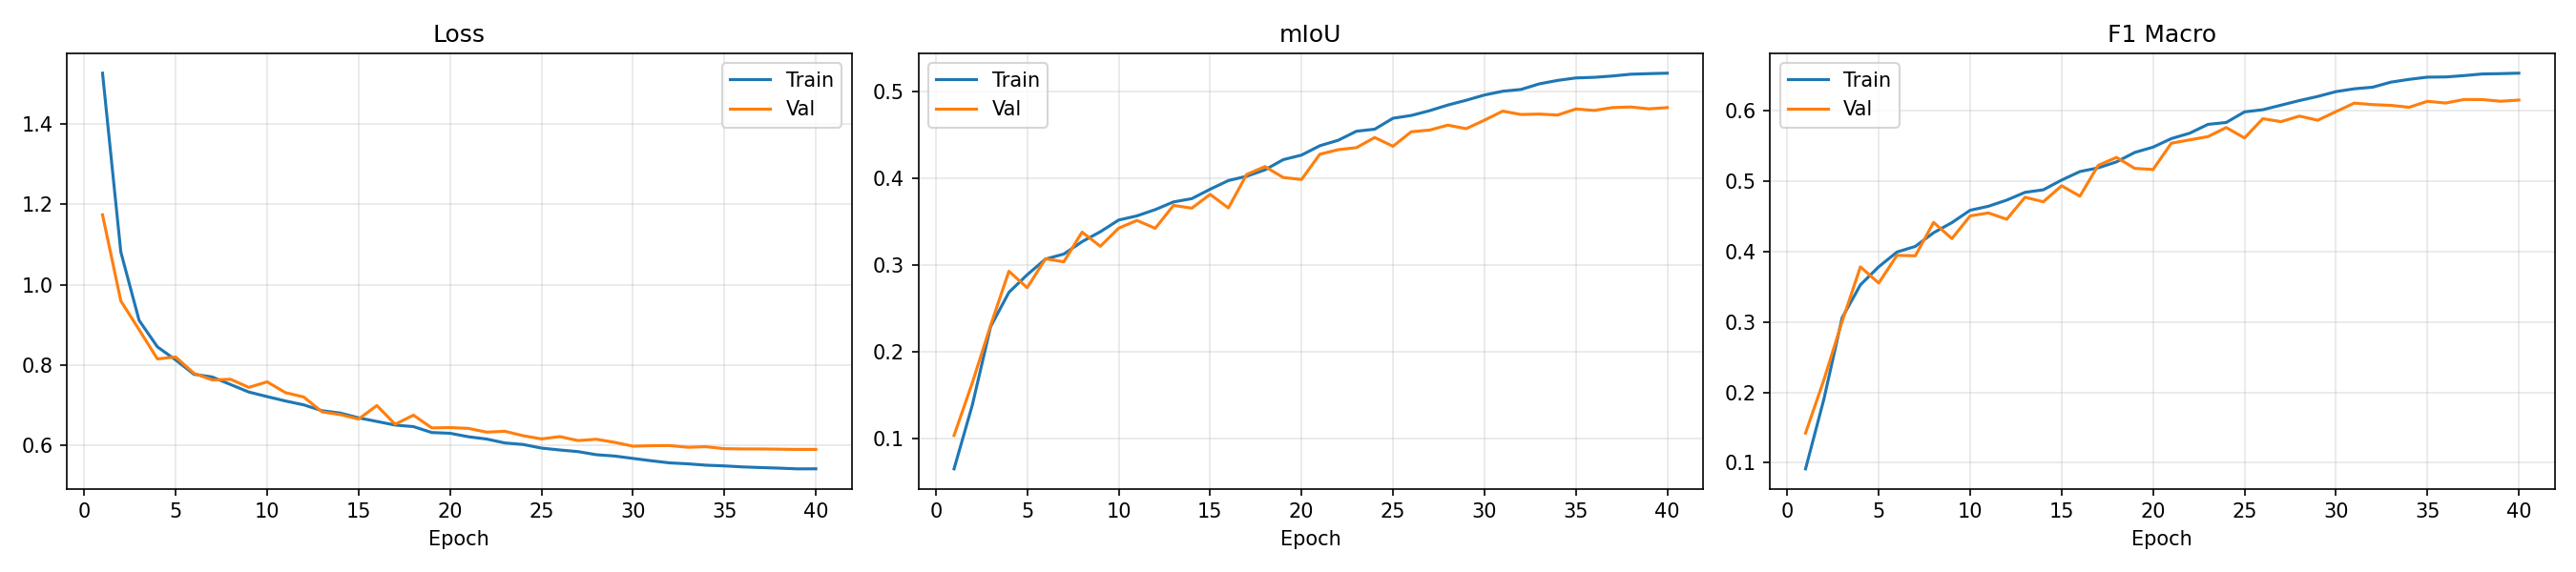

**IoU por clase**

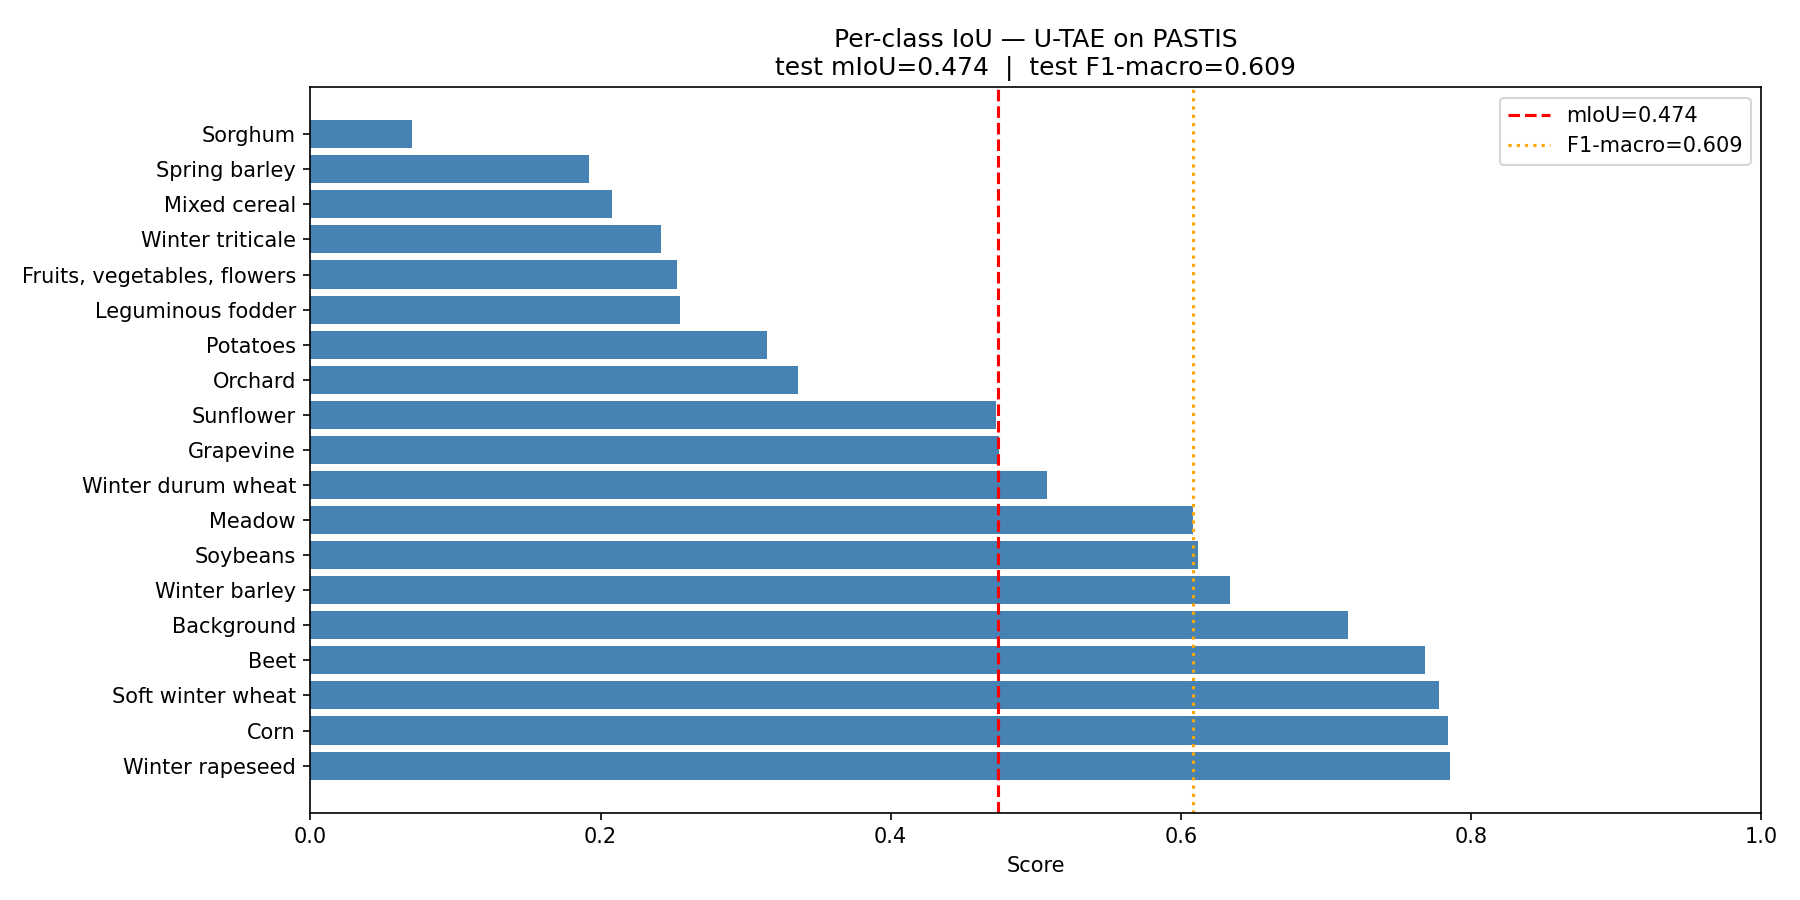

**Matriz de confusion**

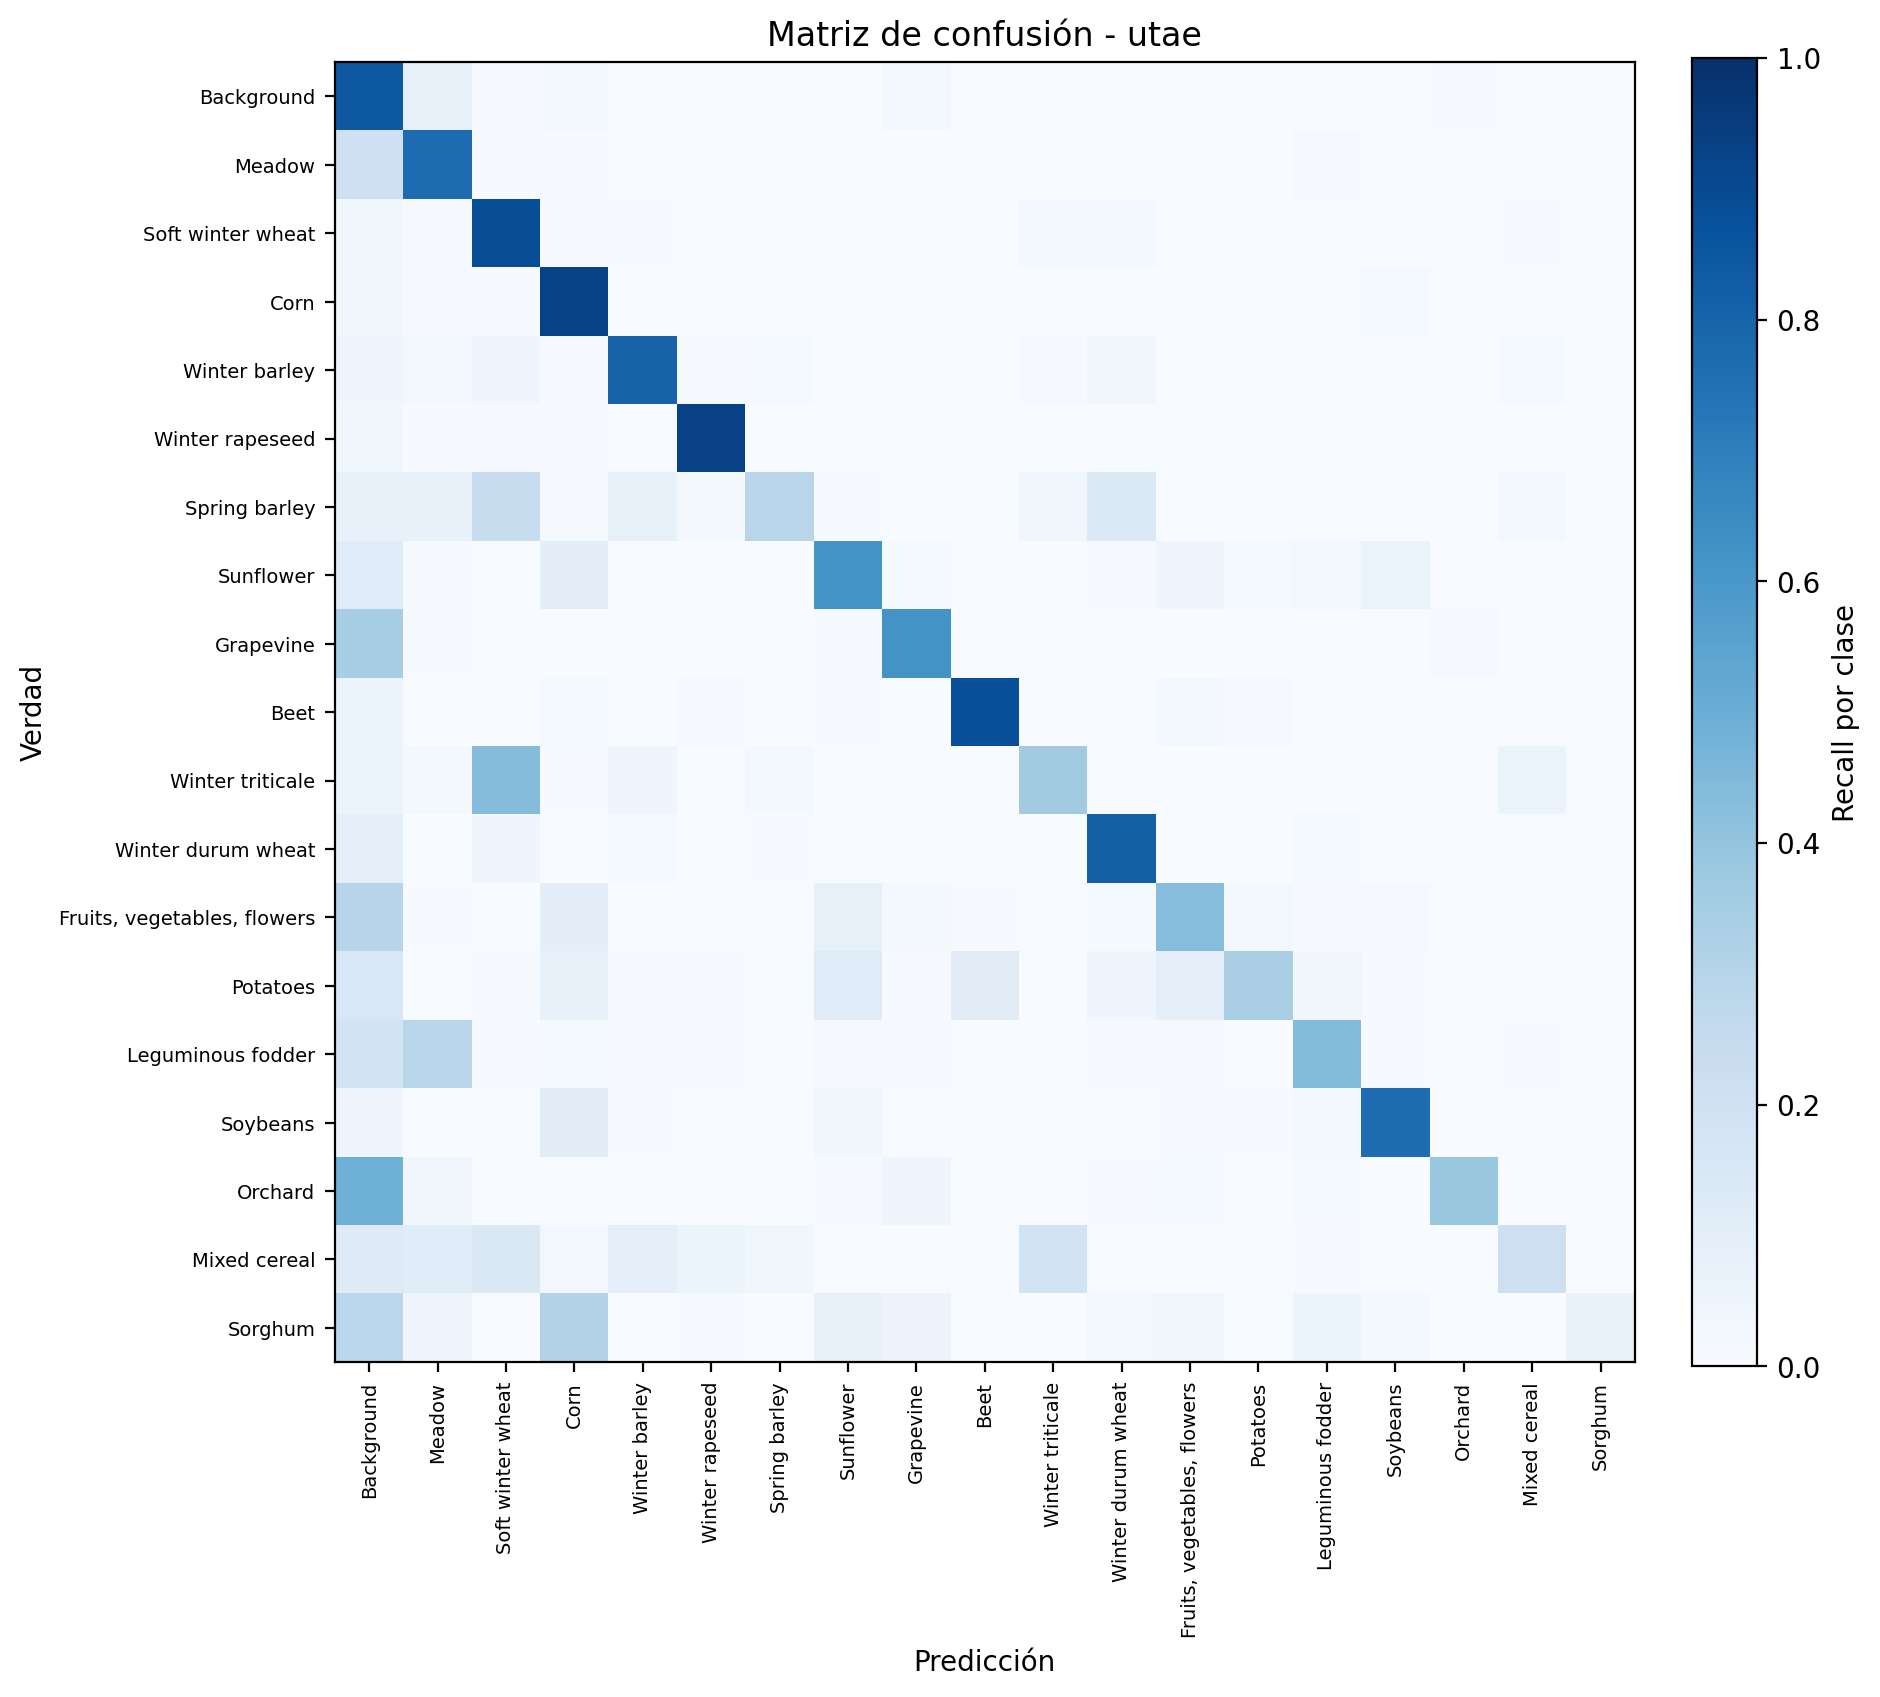

**RGB / verdad / prediccion**

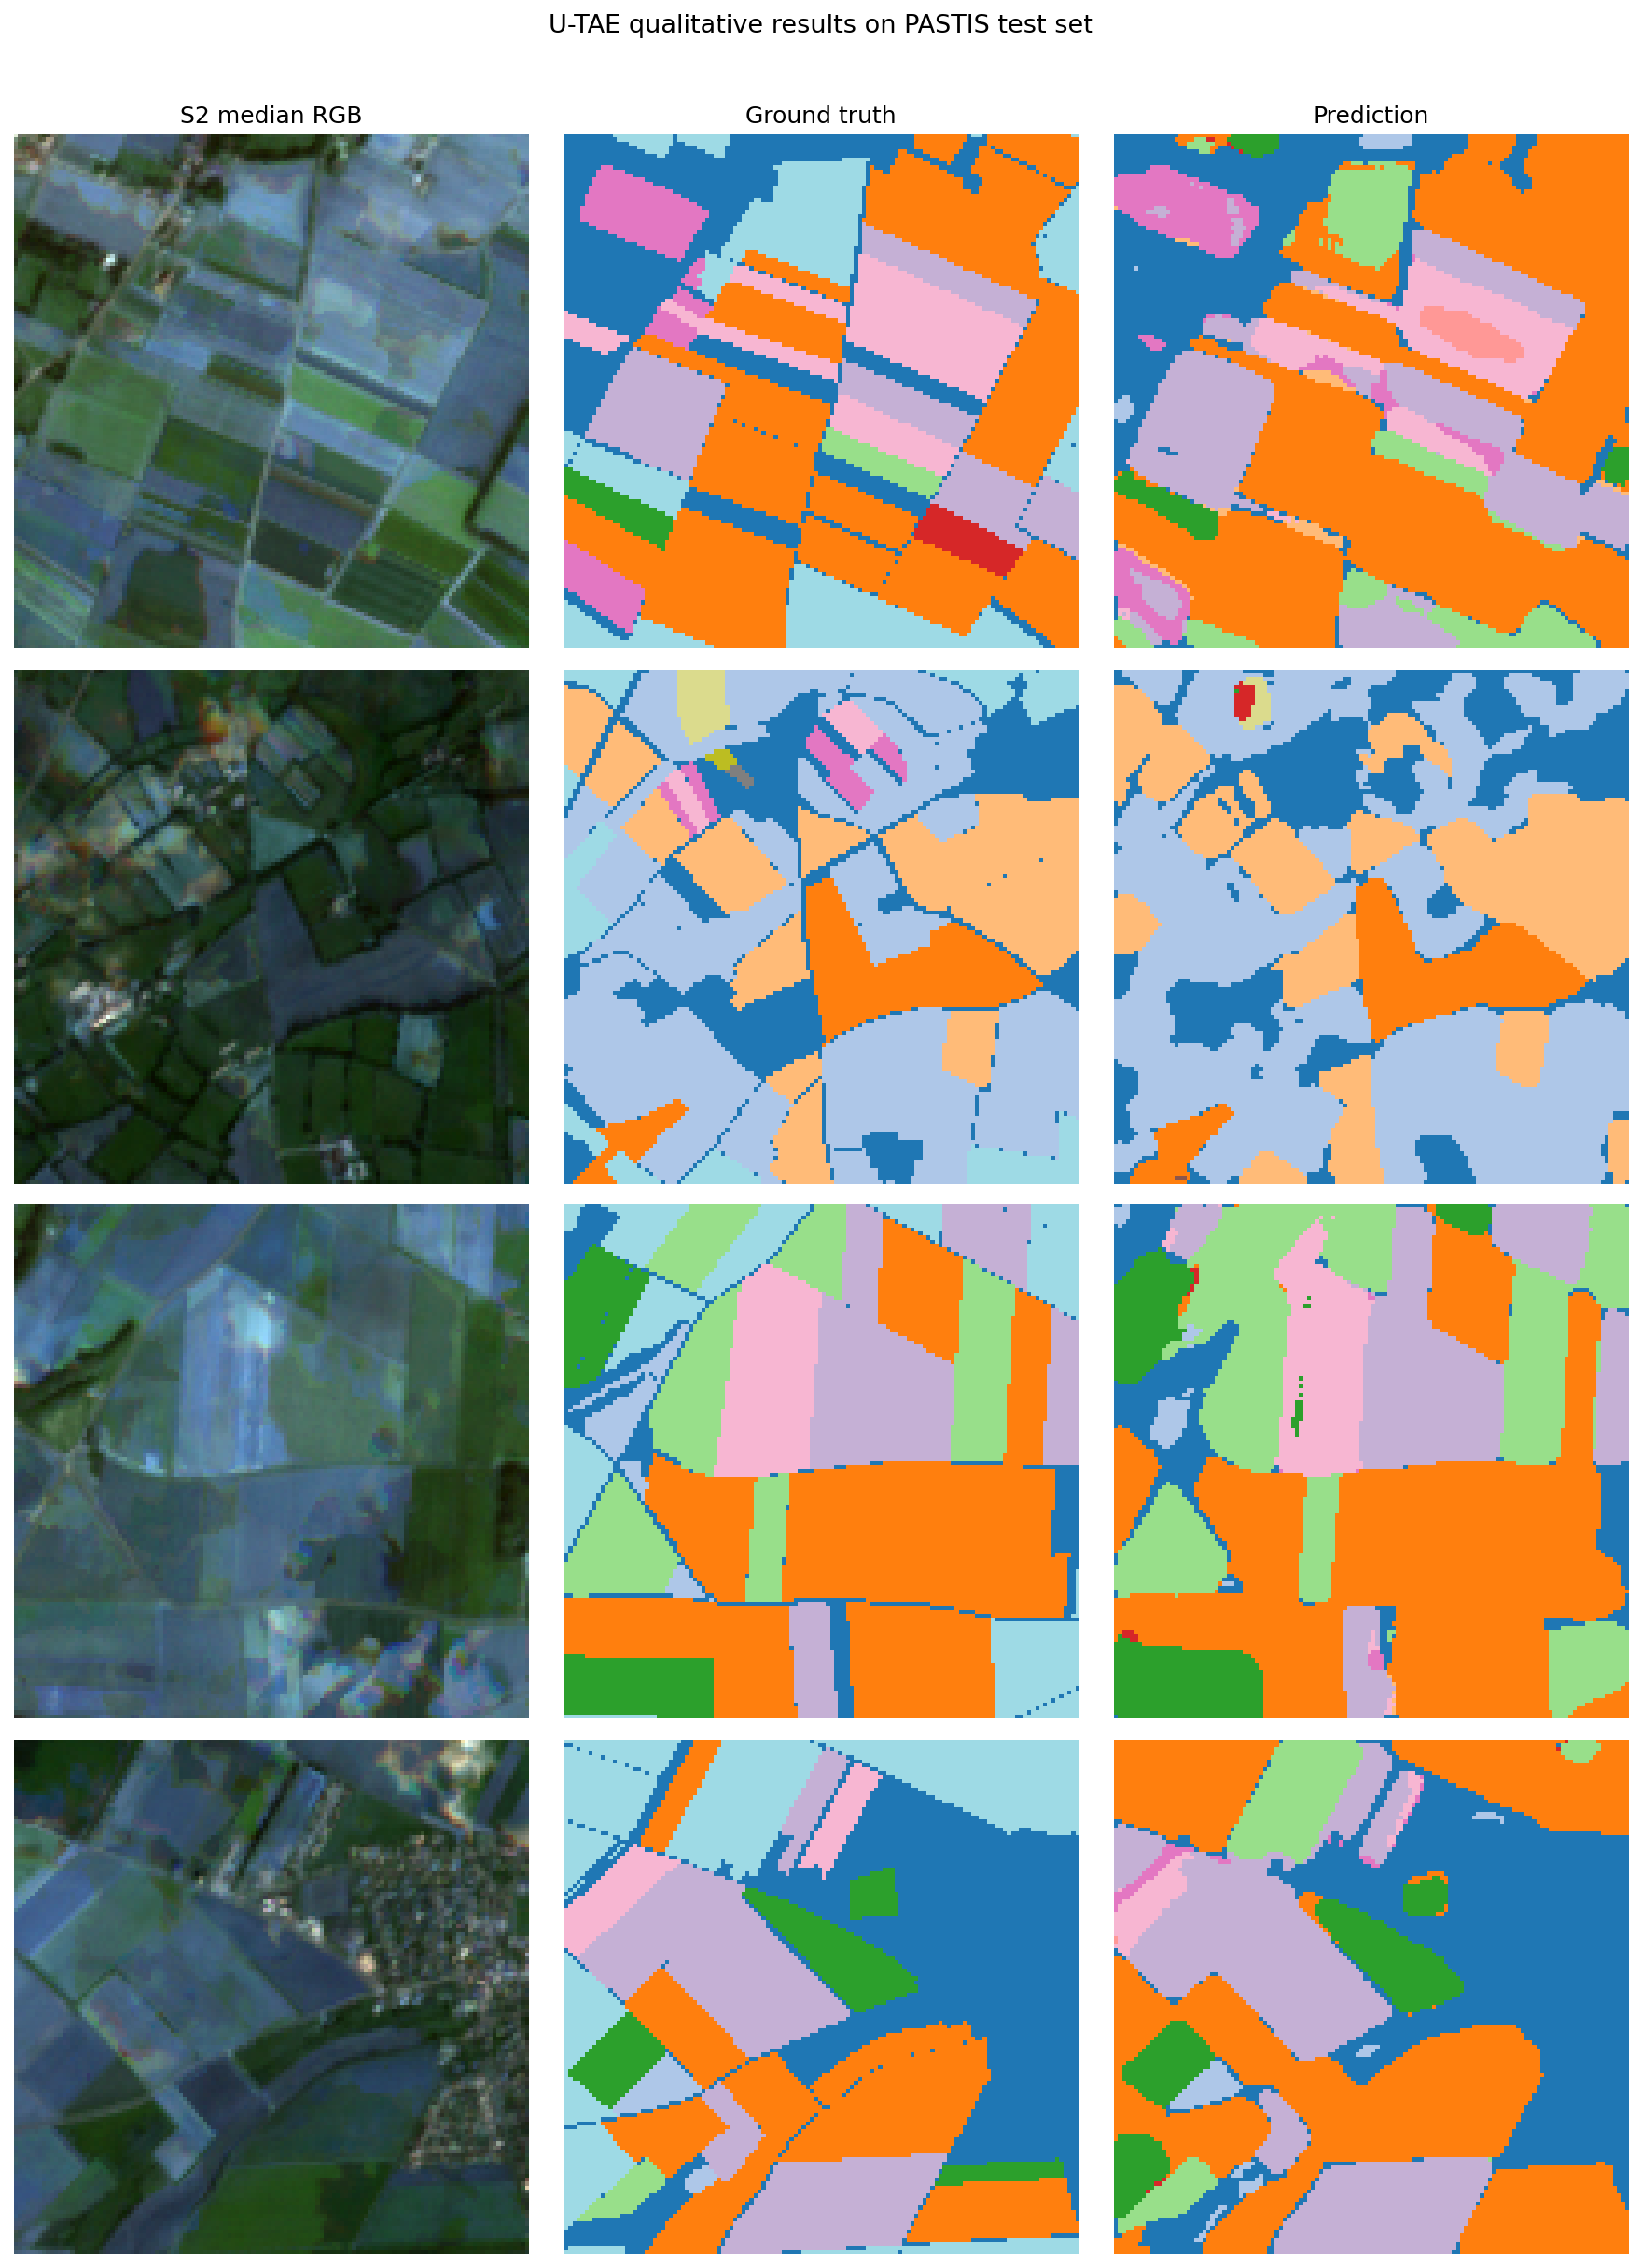

In [10]:
show_model_figs('utae')

### TSViT + rama fenológica (modelo #5)

**TSViT** (*Temporo-Spatial Vision Transformer*, Tarasiou et al. 2023) segmenta consumiendo la **serie temporal completa** de cada parche. Invierte el orden de un video-ViT: aplica primero un **encoder temporal** sobre las `T` fechas (con positional encoding indexado por el día del año real, robusto a las revisitas irregulares de Sentinel-2) y después el **encoder espacial**. Usa **K cls tokens**, uno por clase de cultivo.

Comparamos dos variantes:

- **`tsvit`** (base): solo el transformer factorizado temporal-espacial.
- **`tsvit-pheno`**: agrega una **rama fenológica-contrastiva** (Wen et al. 2025) que alinea por contraste las features visuales de cada píxel con descripciones fenológicas por clase generadas por un LLM (InfoNCE píxel<->prototipo).

**Resultados (fold 4, 482 parches):** la base alcanza mIoU 0.6215 / F1-macro 0.7473; la variante con fenología la supera en las cinco métricas (**mIoU 0.6253** / F1-macro 0.7500), comparable al 65.1 que reporta el paper original. La mejora se concentra en las clases minoritarias de señal ambigua. Detalle en `notebooks/segmentation/5b_tsvit.ipynb`.

> **El mejor modelo individual es `tsvit-pheno`** (la variante con la rama fenológica). Solo se considera esta variante como candidata al top-2: `tsvit` base queda como referencia para cuantificar el aporte de la fenología.

**Curvas de entrenamiento**

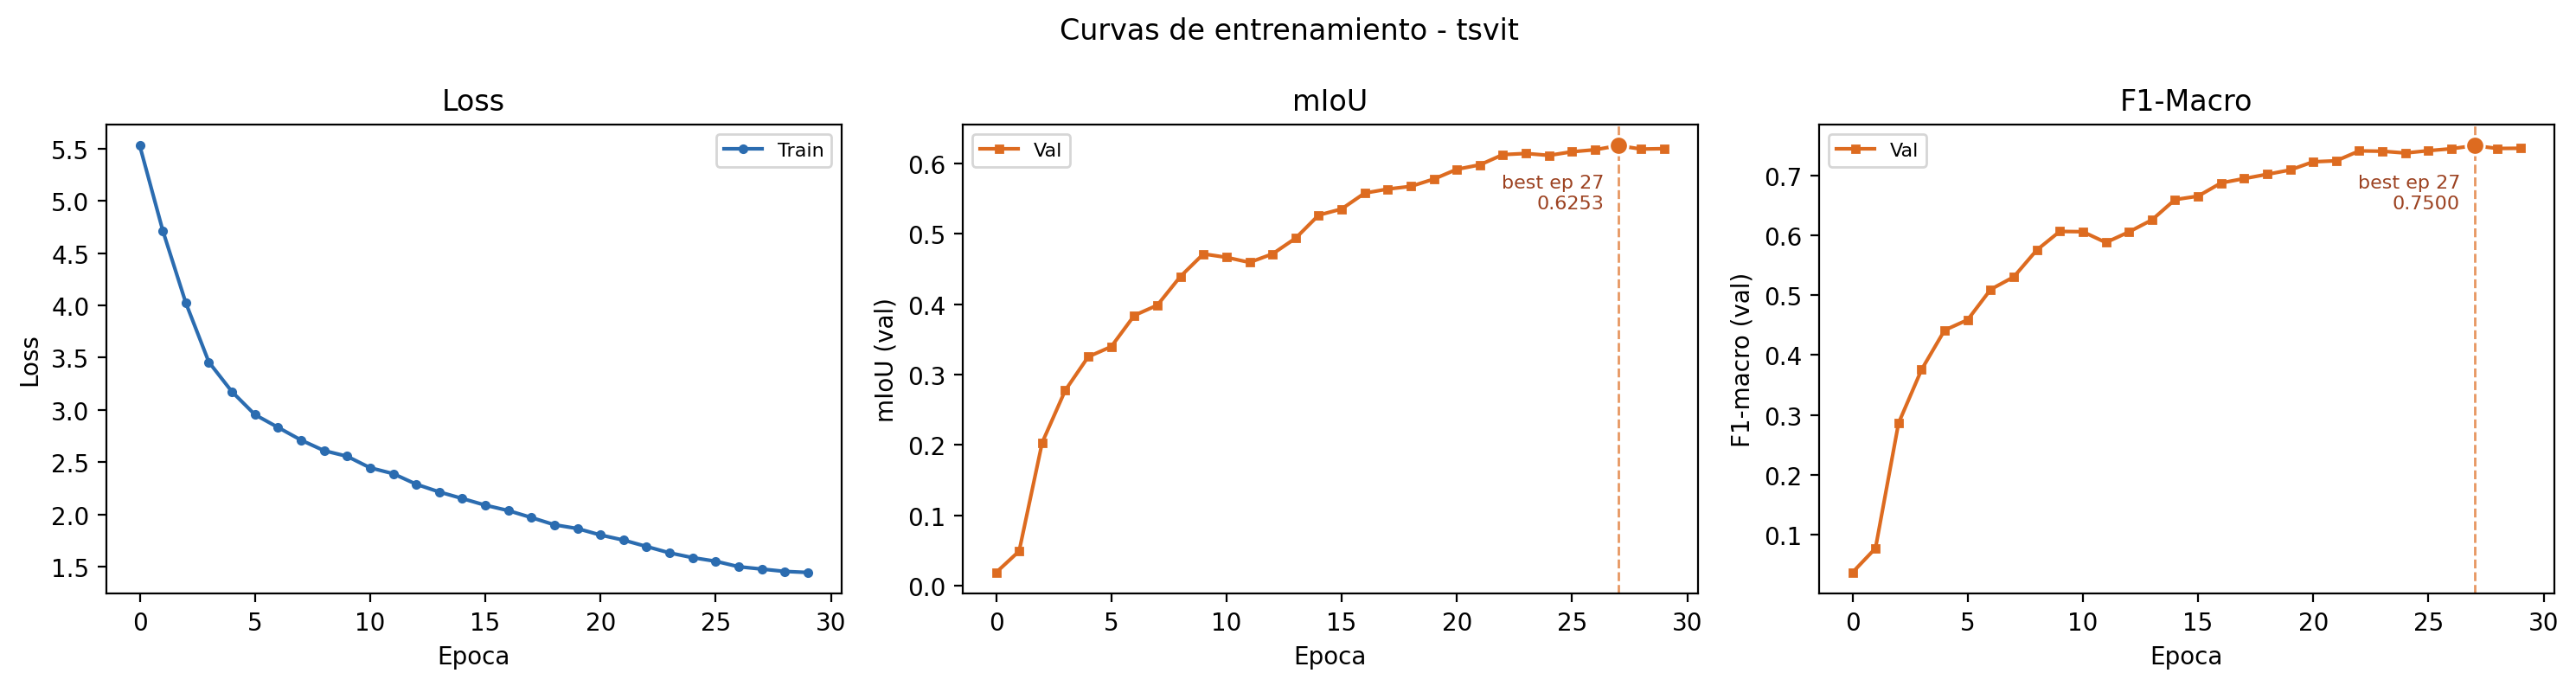

**IoU por clase**

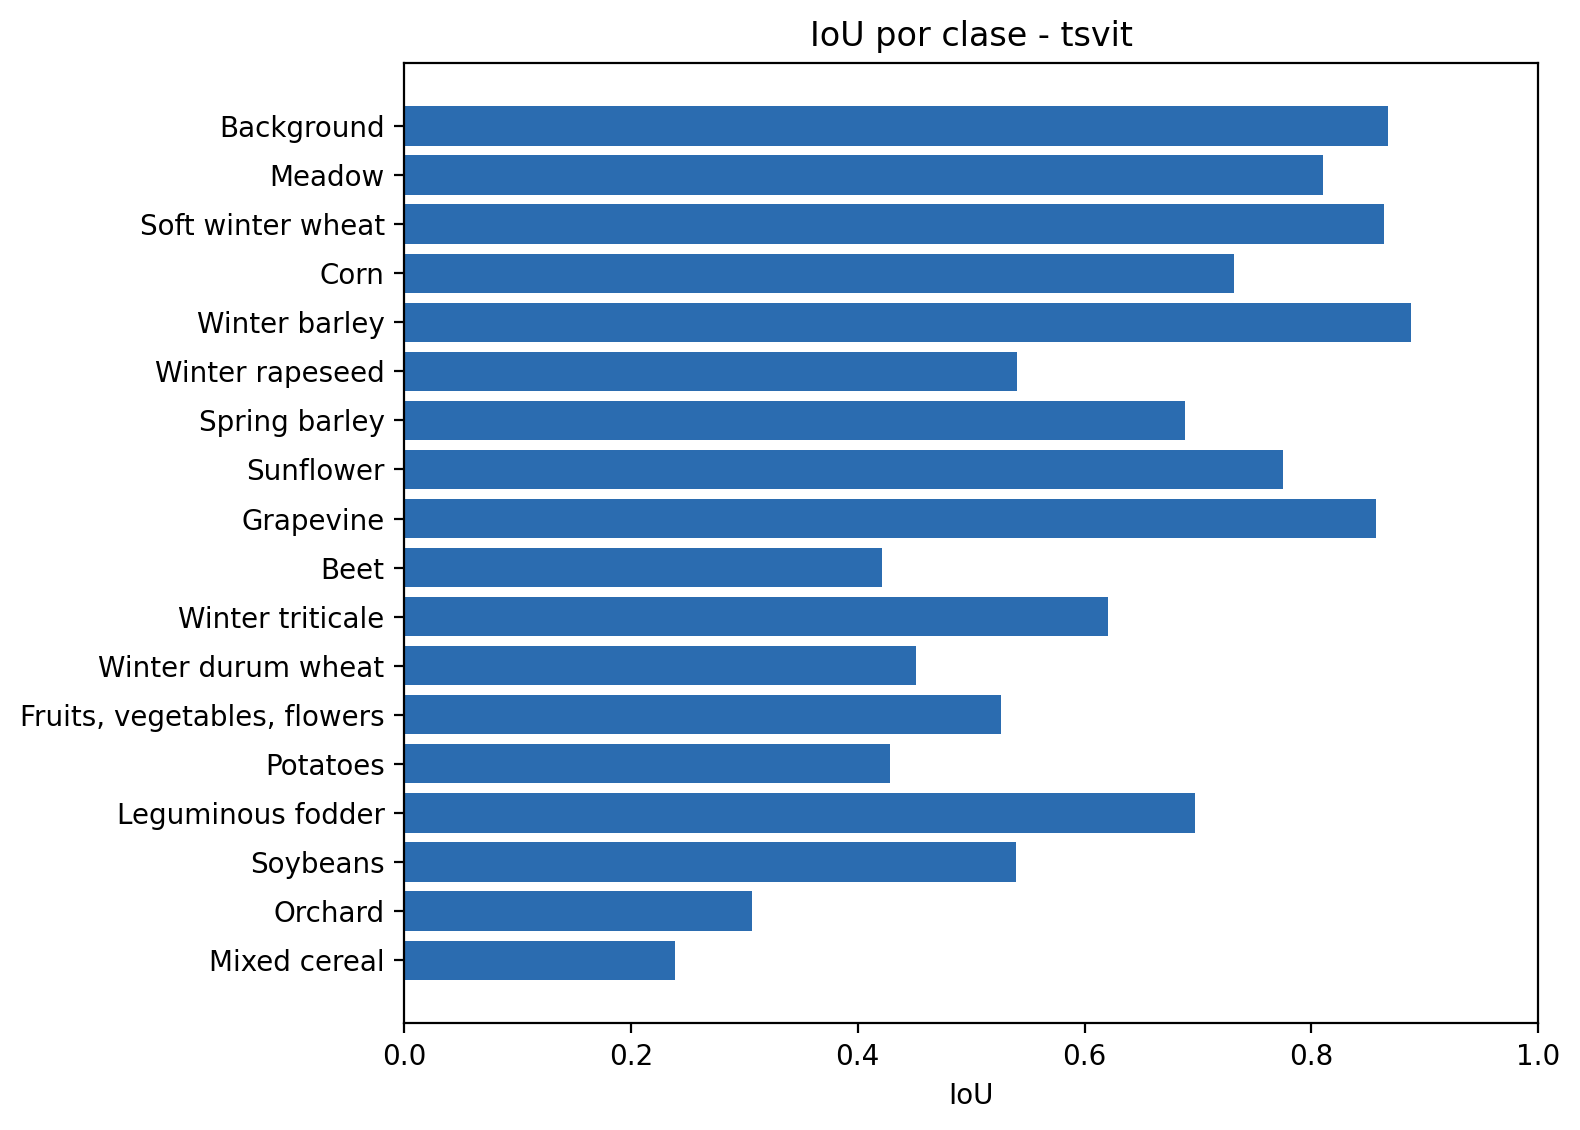

**Matriz de confusion**

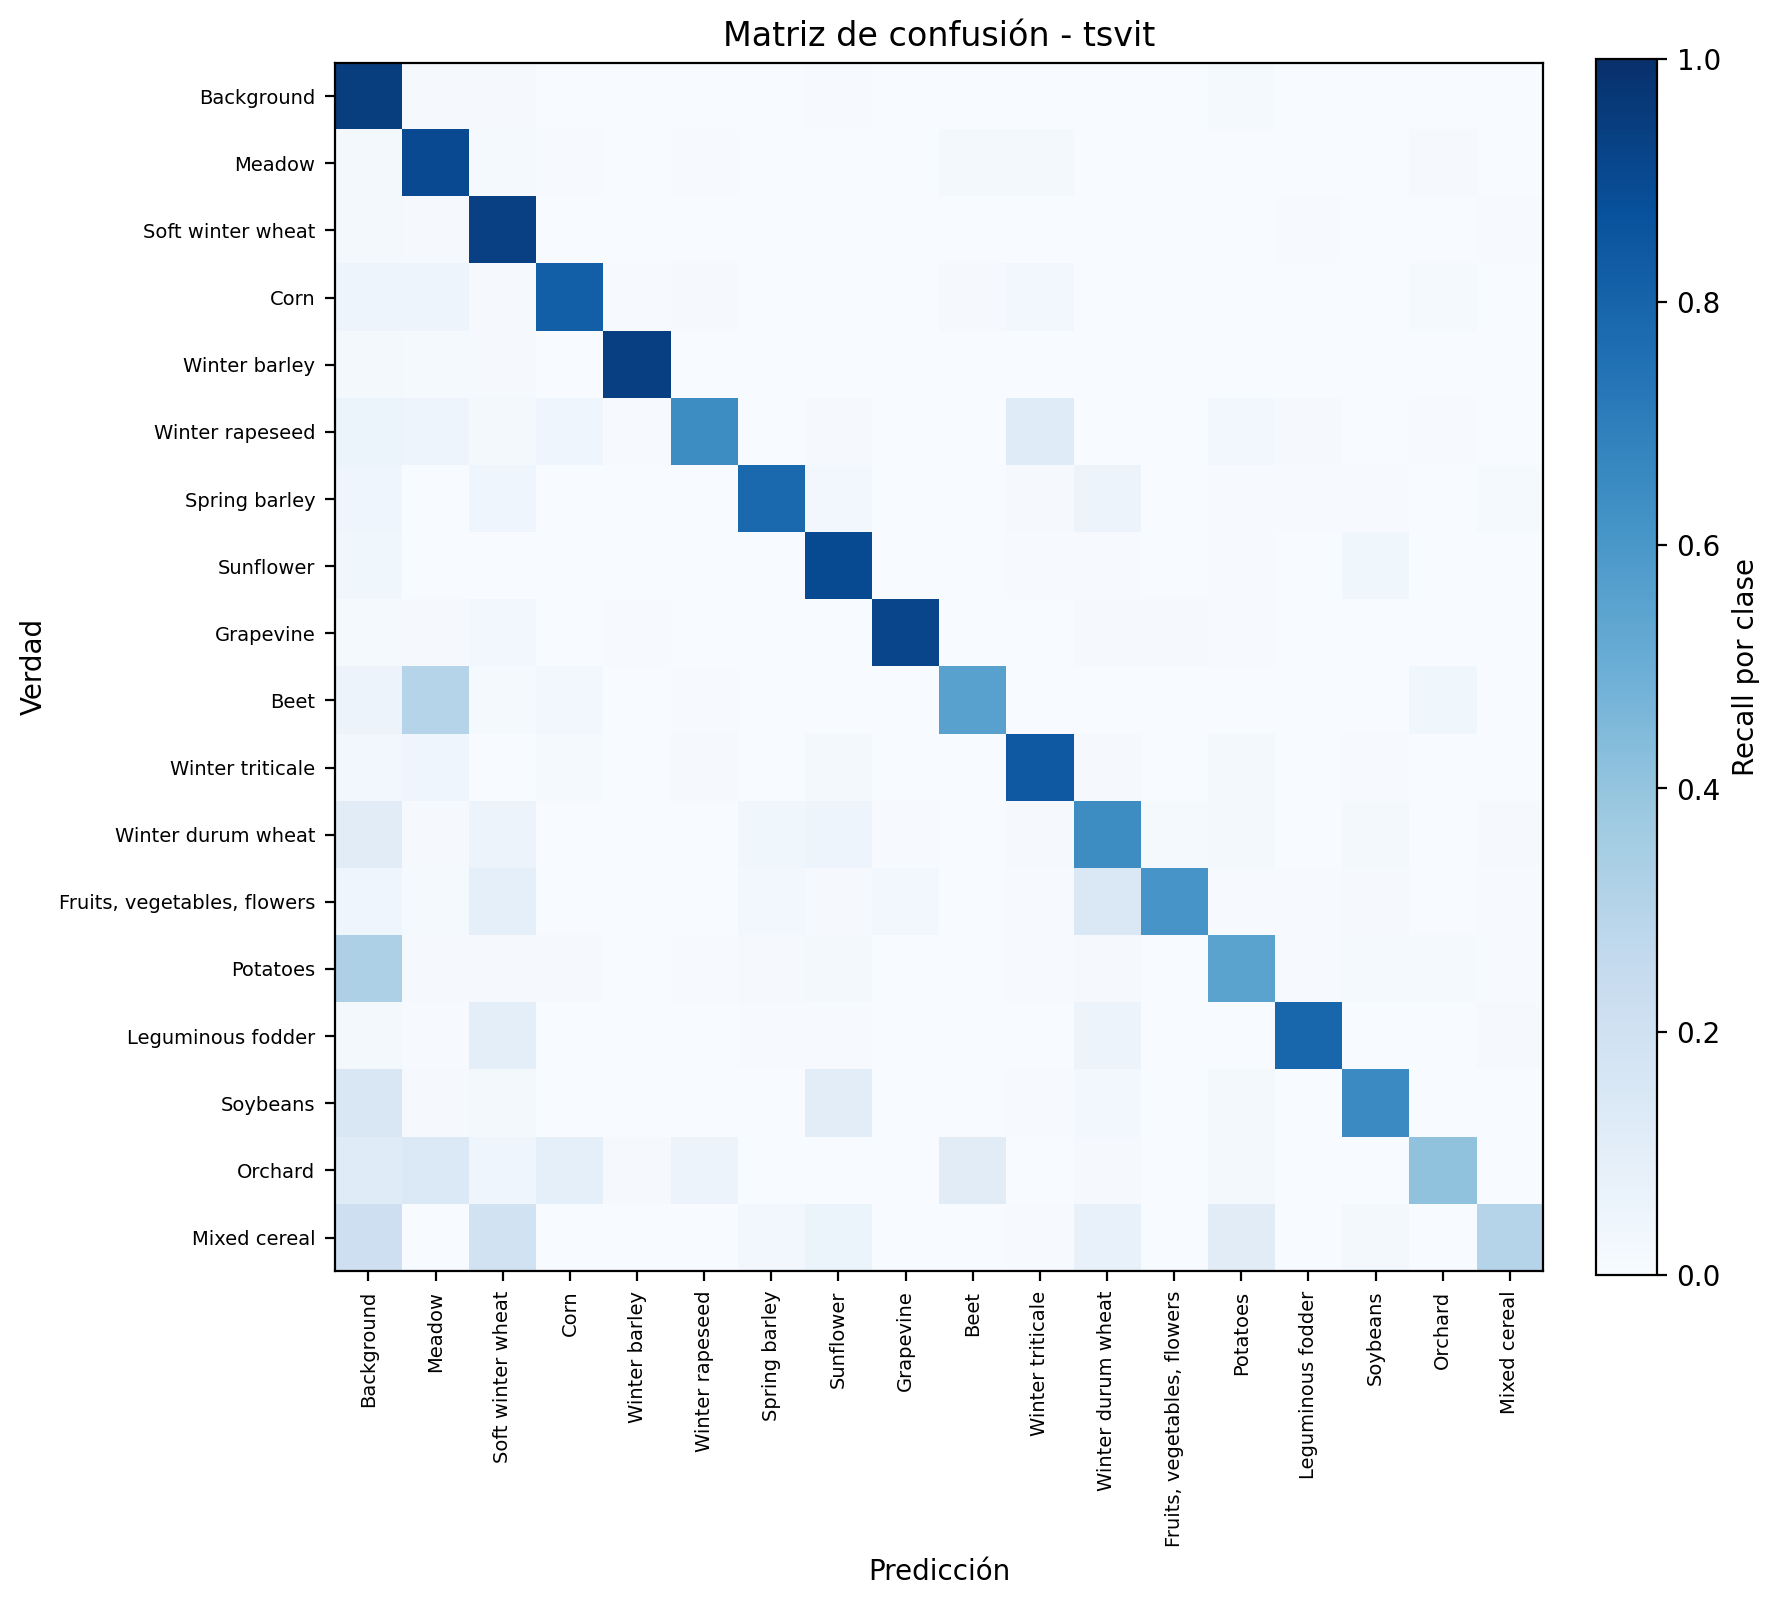

**RGB / verdad / prediccion**

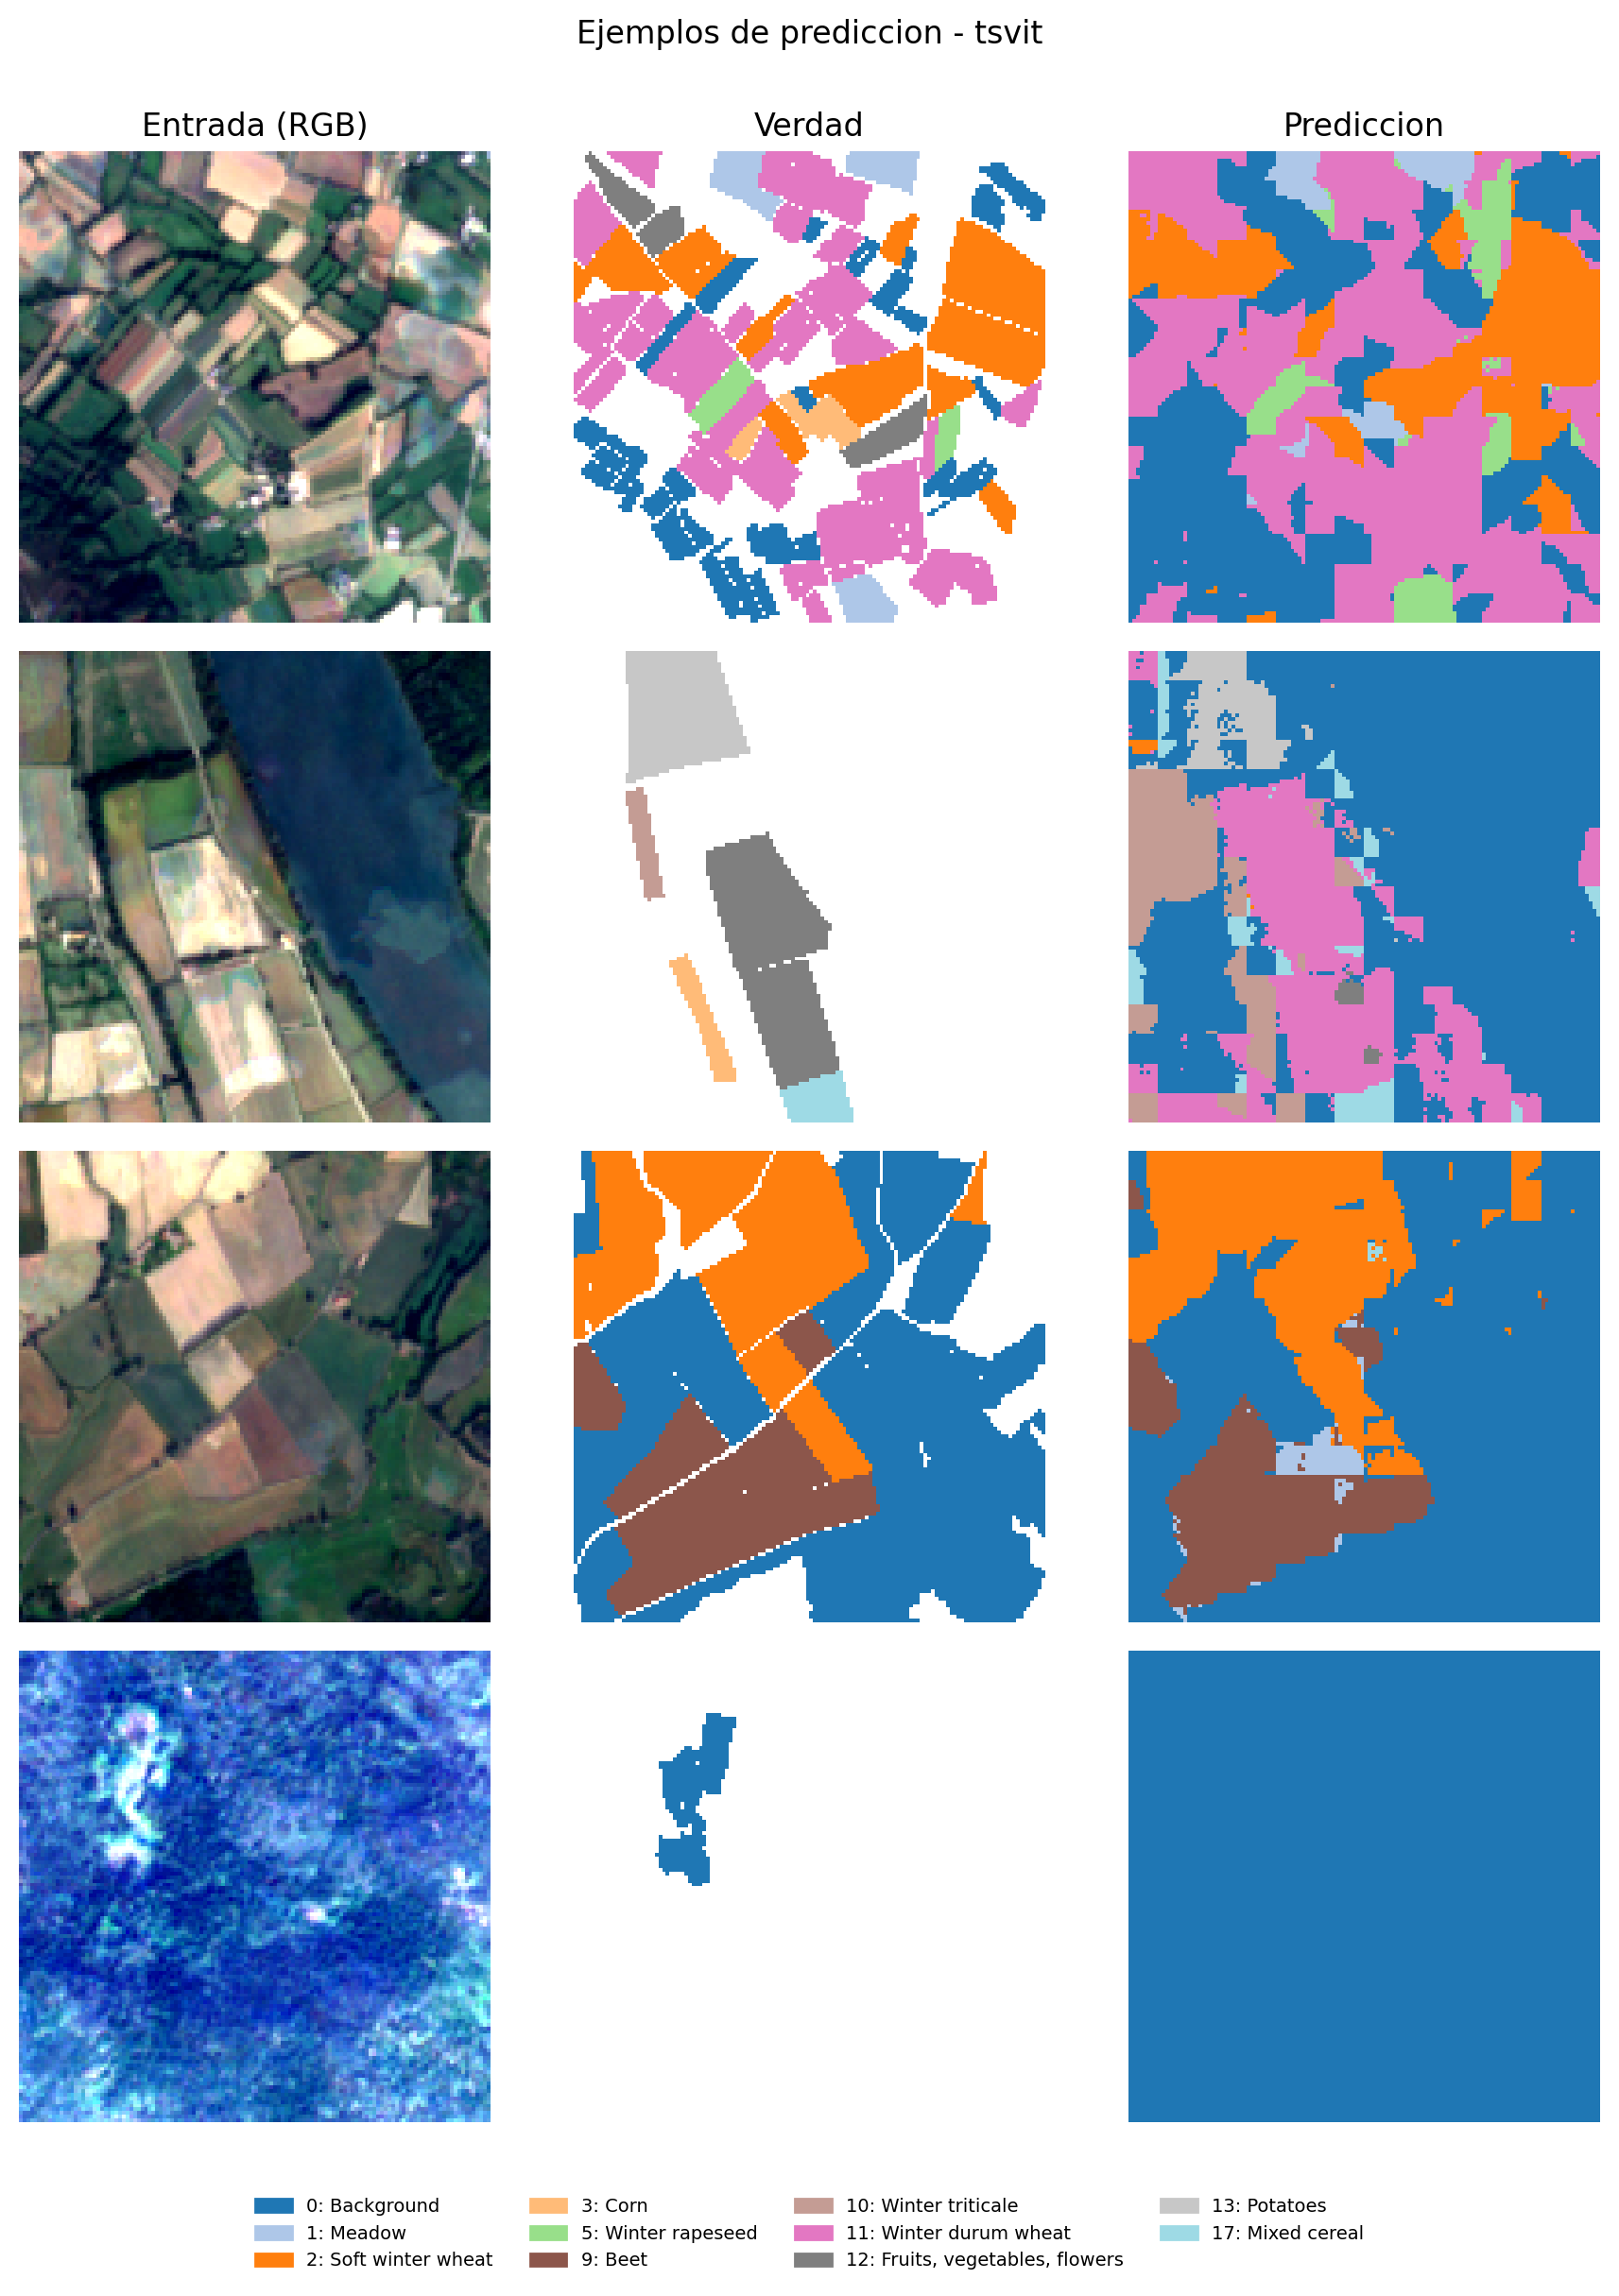

In [11]:
show_model_figs('tsvit')

## Seleccion de los 2 mejores modelos

Por la metrica principal (mIoU); empate se rompe por F1-macro -> pixel-accuracy.

In [12]:
# --- Top-2 ---
if table.height >= 2:
    top2 = table.head(2)
    print('Top-2 por mIoU:', top2['model'].to_list())
    top2.select([c for c in _cols if c in top2.columns])
else:
    print('Se requieren >=2 modelos para seleccionar el top-2.')
    top2 = table

Top-2 por mIoU: ['tsvit-pheno', 'tsvit']


## Ajuste fino del top-2

Cada modelo del top-2 se afina con **Optuna (30 trials)** sobre `lr`, `weight_decay` y `batch_size`. Los modelos temporales (tsvit-pheno, U-TAE) se afinan por warm-start desde su mejor checkpoint (fine-tuning corto de 3 épocas por trial); AnySat, con encoder congelado, afina solo su cabeza lineal sobre features cacheadas. Los resultados se exportan a `reports/segmentation/metrics/tuning_<modelo>.parquet` y se consolidan aquí.

In [13]:
# --- Resultados del ajuste fino (Optuna, >=30 trials por modelo) ---
# Cada estudio se exporta a metrics/tuning_<modelo>.parquet y se consolida aqui.
# Conviven dos esquemas: tsvit-pheno y utae (modelos temporales del top-2)
# guardan la metrica del trial en `value` (mIoU val) + `base_miou` del modelo de
# partida; anysat y unet la guardan en `miou_grouped` (mIoU 6 grupos HCAT). La
# columna `trial_miou` unifica ambas para el resumen comparativo.
tuning_parts = sorted(REPORTS.glob('tuning_*.parquet'))
if tuning_parts:
    frames = []
    for p in tuning_parts:
        t = pl.read_parquet(p)
        metric_col = 'value' if 'value' in t.columns else 'miou_grouped'
        t = t.with_columns(pl.col(metric_col).cast(pl.Float64).alias('trial_miou'))
        if 'base_miou' not in t.columns:
            t = t.with_columns(pl.lit(None, dtype=pl.Float64).alias('base_miou'))
        frames.append(t.select(
            ['model', 'trial', 'state', 'lr', 'weight_decay', 'batch_size',
             'trial_miou', 'base_miou']
        ))
    tuning = pl.concat(frames, how='vertical_relaxed')

    # Resumen por modelo: trials totales, completados/podados y mejor config.
    rows = []
    for model in tuning['model'].unique(maintain_order=True).to_list():
        sub = tuning.filter(pl.col('model') == model)
        completed = sub.filter(pl.col('state') == 'COMPLETE')
        ranked = completed if completed.height else sub
        best = ranked.sort('trial_miou', descending=True, nulls_last=True).row(0, named=True)
        base = best['base_miou']
        rows.append({
            'model': model,
            'n_trials': sub.height,
            'completados': completed.height,
            'podados': sub.filter(pl.col('state') == 'PRUNED').height,
            'best_miou': round(best['trial_miou'], 4) if best['trial_miou'] is not None else None,
            'base_miou': round(base, 4) if base is not None else None,
            'mejora': round(best['trial_miou'] - base, 4) if base is not None else None,
            'best_lr': float(best['lr']) if best['lr'] is not None else None,
            'best_weight_decay': float(best['weight_decay']) if best['weight_decay'] is not None else None,
            'best_batch_size': best['batch_size'],
        })
    tuning_summary = pl.DataFrame(rows).sort('best_miou', descending=True, nulls_last=True)
    print(f'Ajuste fino Optuna: {len(tuning_parts)} modelos, {tuning.height} trials en total.')
    display(tuning_summary)
else:
    print('Sin tuning_<modelo>.parquet en metrics/.')
    tuning = pl.DataFrame()
    tuning_summary = pl.DataFrame()

Ajuste fino Optuna: 4 modelos, 120 trials en total.


model,n_trials,completados,podados,best_miou,base_miou,mejora,best_lr,best_weight_decay,best_batch_size
str,i64,i64,i64,f64,f64,f64,f64,f64,i64
"""anysat""",30,21,9,0.631,null,null,0.006463,0.003836,1
"""tsvit-pheno""",30,23,7,0.6251,0.6253,-0.0002,0.000108,0.000005,16
"""utae""",30,12,18,0.4854,0.4826,0.0028,0.00005,0.000356,4
"""unet""",30,17,13,0.3487,null,null,0.000291,0.000009,8


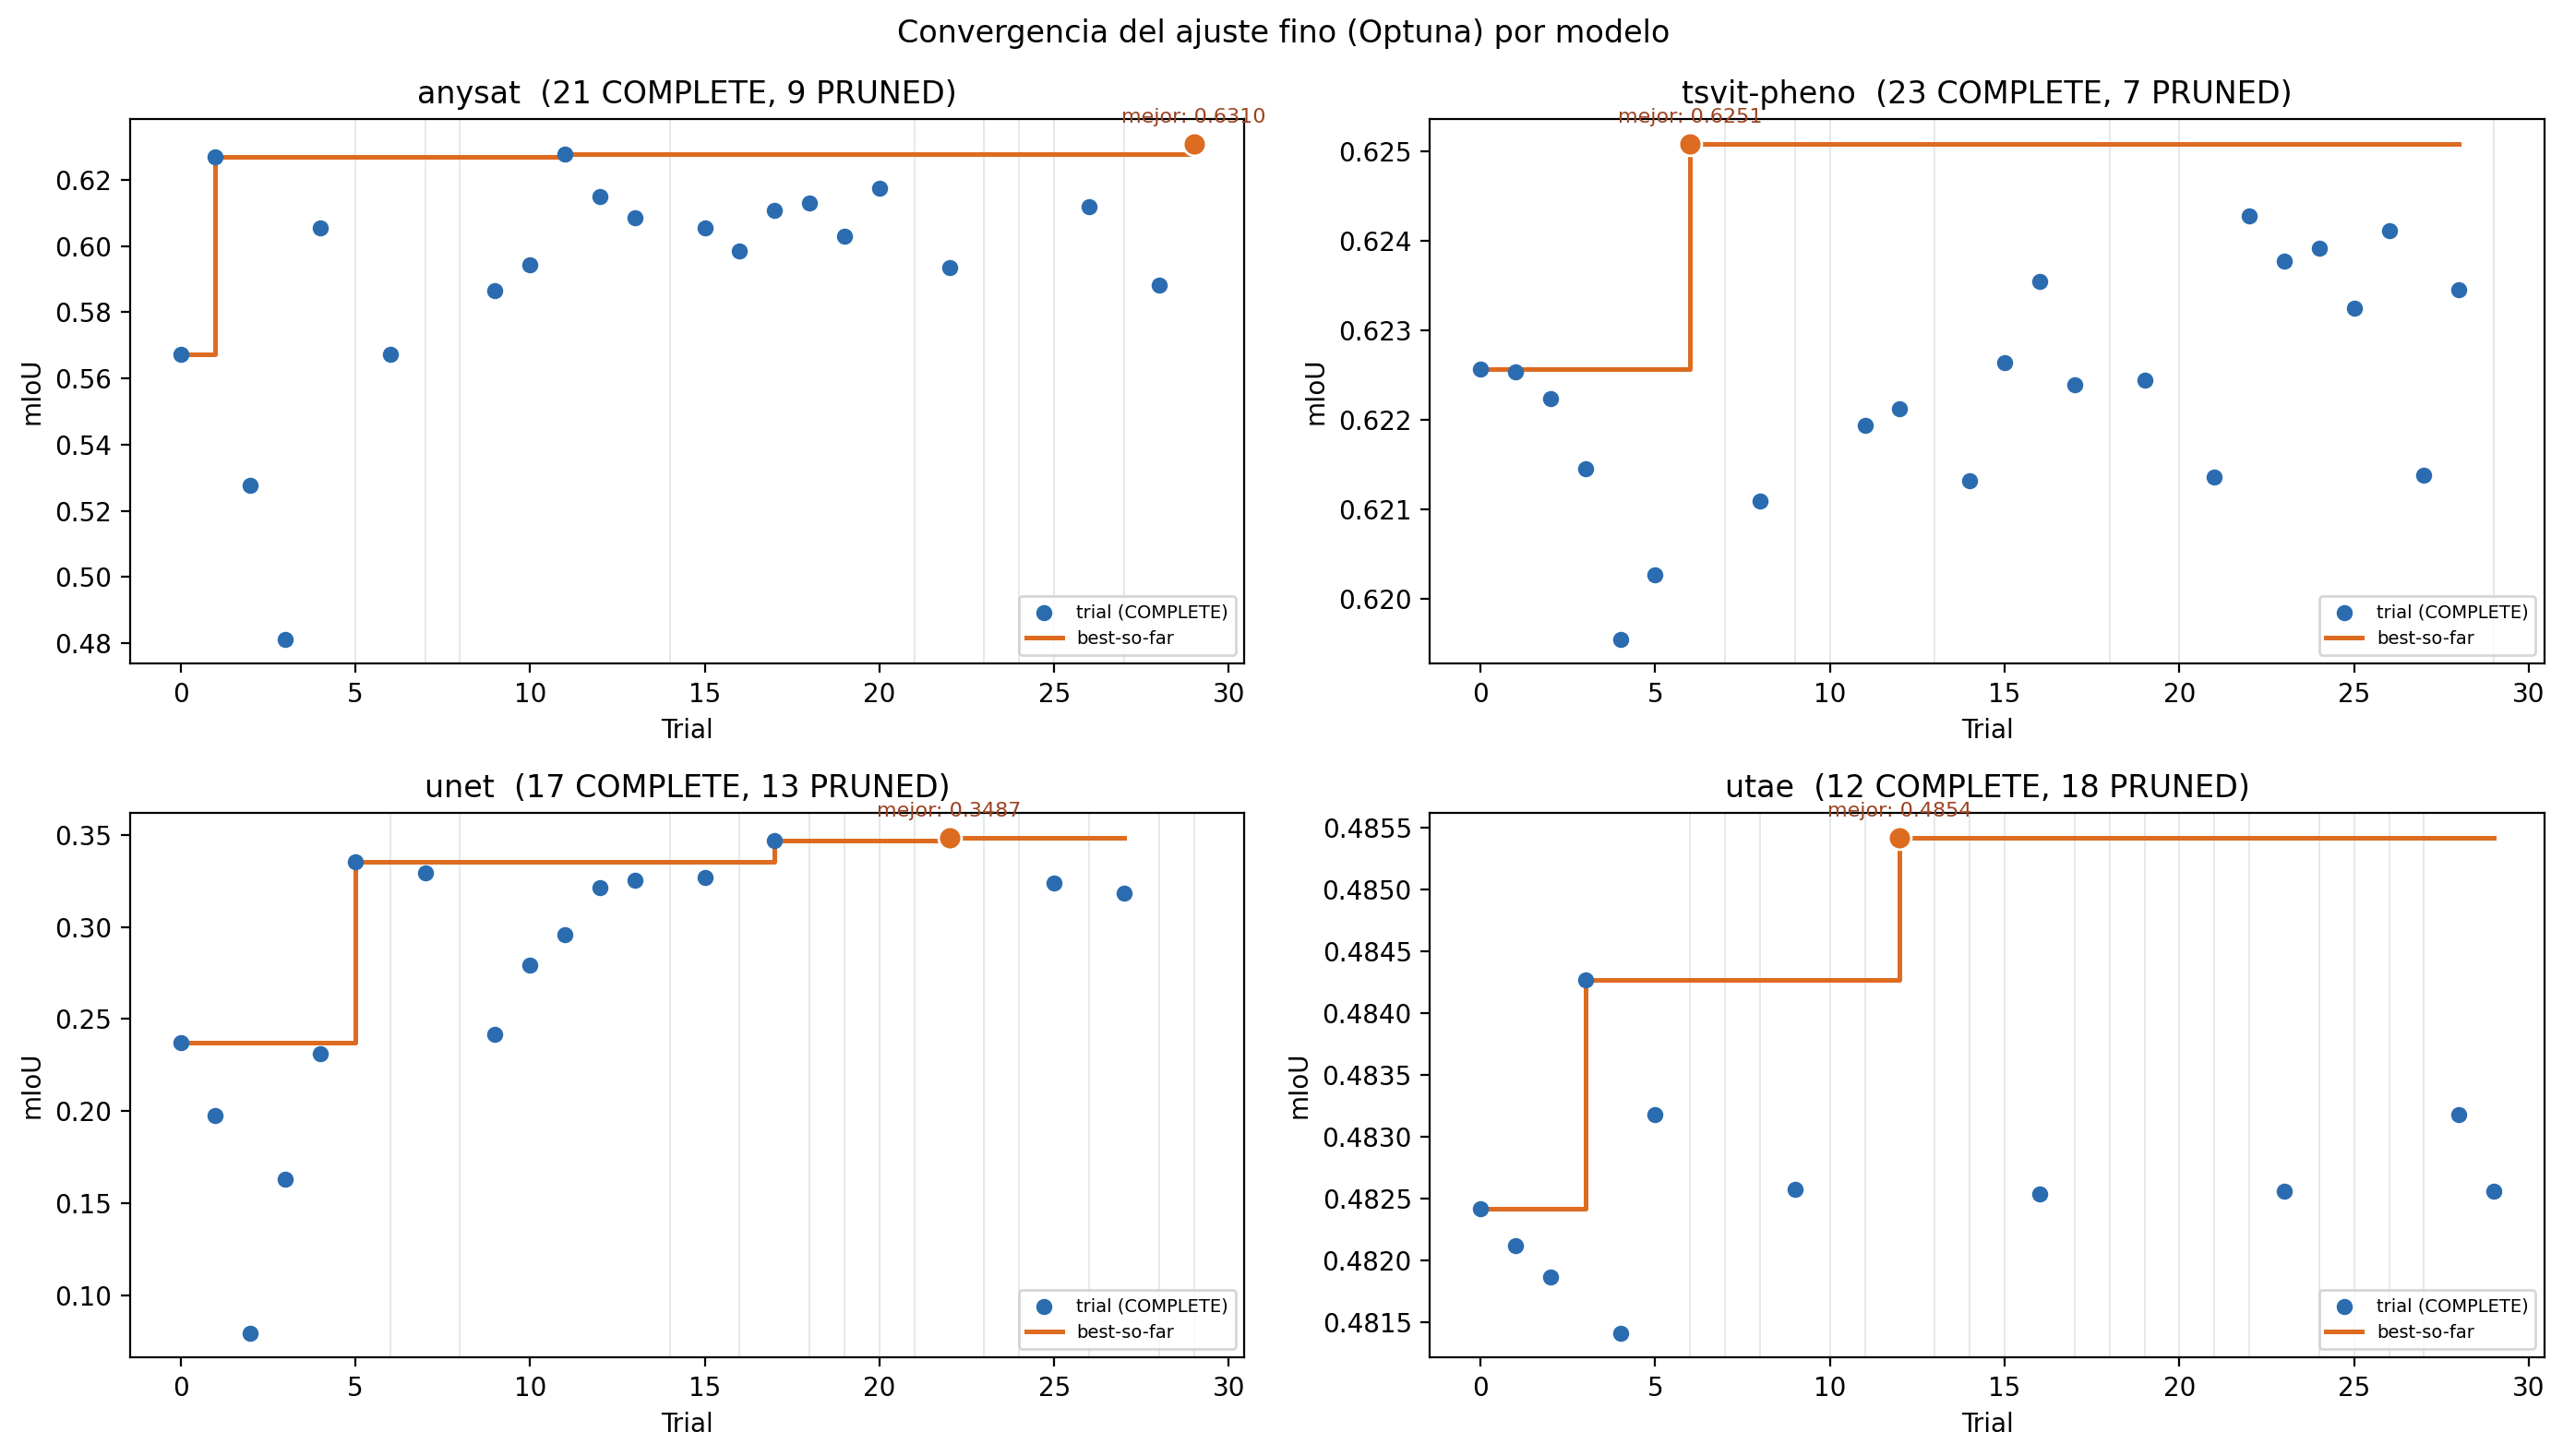

In [14]:
# --- Convergencia de Optuna: como mejoro cada modelo trial a trial ---
# Muestra, por modelo, el mIoU de cada trial (puntos) y la curva best-so-far
# (mejor valor hasta ese trial). Las lineas grises verticales son trials podados.
from IPython.display import Image, display

_conv = FIGURES / 'optuna_convergence.png'
if _conv.exists():
    display(Image(filename=str(_conv)))
else:
    print('Sin optuna_convergence.png (generar con ml.eval.avance4_figures.optuna_convergence_figure).')

Cada modelo se afinó con Optuna (30 trials, TPE + MedianPruner que corta los trials malos antes de gastar las épocas completas) variando learning rate, weight decay y tamaño de batch. Como reentrenar de cero 30 veces un modelo temporal es inviable, los modelos del top-2 (tsvit-pheno, U-TAE) se afinaron por **warm-start**: cada trial parte del mejor checkpoint ya entrenado y hace un fine-tuning corto de 3 épocas; así 3 épocas son significativas (se refina un modelo bueno, no se aprende de cero) y los 30 trials corren en un par de horas en una GPU L4.

La gráfica de convergencia de arriba muestra esto trial a trial: la curva **best-so-far** (naranja) sube rápido en los primeros trials y luego se aplana, señal de que Optuna encontró pronto una buena región de hiperparámetros; las líneas grises son los trials que el pruner descartó temprano.

Lo que muestra la tabla, leído por modelo:

- **U-TAE**: el mejor trial (lr 5.0e-05, weight_decay 3.6e-04, batch 4) sube de mIoU 0.4826 a **0.4854**, una mejora pequeña pero real: el modelo base ya estaba bien ajustado y el tuning solo lo afina al margen.
- **AnySat** (encoder congelado): cada trial entrena solo la cabeza lineal sobre features cacheadas, por eso corre en segundos; el mejor trial (lr 6.5e-03, batch 1) llega a mIoU 0.63 sobre los 6 grupos HCAT, por encima del 0.59 del modelo base de 30 épocas. Con mejor learning rate la cabeza converge más rápido y un poco mejor.
- **U-Net**: cada trial reentrena la red completa sobre un subset, así que el mejor trial (mIoU 0.35 sobre 6 grupos) queda por debajo del base de épocas completas; aquí el tuning sirve para rankear hiperparámetros, no para superar al base.
- **TSViT-pheno**: 30 trials rozan el base (0.6253) sin superarlo (mejor 0.6251); confirma que el modelo final ya estaba en su óptimo de hiperparámetros.

La lectura general es la misma: con el LR schedule y la configuración base ya cuidados, el margen de mejora por hiperparámetros es estrecho. El valor del ajuste fino está en **confirmar** que la configuración elegida es robusta, no en saltos grandes de métrica.

## Modelo individual final

La elección no se hace solo por la métrica, sino ponderando tres ejes:

- **Rendimiento.** Sobre las 18 clases planas de PASTIS-R, **TSViT con la rama fenológica (`tsvit-pheno`) es el mejor por amplio margen**: mIoU 0.6253 / F1-macro 0.7500, frente a 0.47 de U-TAE, 0.45 de AnySat (6 grupos) y 0.27 de DeepLabv3+. La distancia con los modelos no temporales (DeepLabv3+ 0.27, SegFormer 0.23) cuantifica cuánto aporta leer la serie temporal completa: cultivos que en una sola fecha se confunden se separan por su calendario de crecimiento. La rama fenológica añade un punto extra (0.6215 -> 0.6253) concentrado en las clases minoritarias de señal ambigua.

- **Costo de cómputo.** TSViT es el más caro de entrenar (~32 min/run de 30 épocas en RTX 4070; tiempos en la tabla comparativa), contra los segundos de la cabeza de AnySat (encoder congelado). Para el presupuesto del proyecto (L4/H100 con scale-to-zero) es un costo asumible porque el entrenamiento es puntual y la inferencia, una vez entrenado, es un único forward por parche.

- **Interpretabilidad y robustez.** Las CNN (U-Net, DeepLabv3+) son más fáciles de diagnosticar, pero pierden la dimensión temporal. AnySat ofrece un foundation model congelado con mínima capacidad entrenable (muy eficiente, pero techo de rendimiento más bajo). TSViT, además de la mejor métrica, expone vía los pesos de atención temporal **qué fechas** pesan en cada predicción, y la rama fenológica ancla las features a descripciones agronómicas por clase, lo que da una lectura interpretable del "por qué" de cada cultivo.

**Decisión: el modelo individual final es `tsvit-pheno`.** Gana en la métrica principal, su costo de entrenamiento es puntual y asumible, y es el único que combina mejor desempeño con una vía de interpretación (atención temporal + anclaje fenológico). U-TAE queda como segundo del top-2 y alternativa temporal más ligera; AnySat como la opción más eficiente cuando el presupuesto de cómputo manda sobre la última décima de mIoU.

**Modelo individual final (por mIoU): `tsvit-pheno`** - mIoU = 0.6253, F1-macro = 0.75

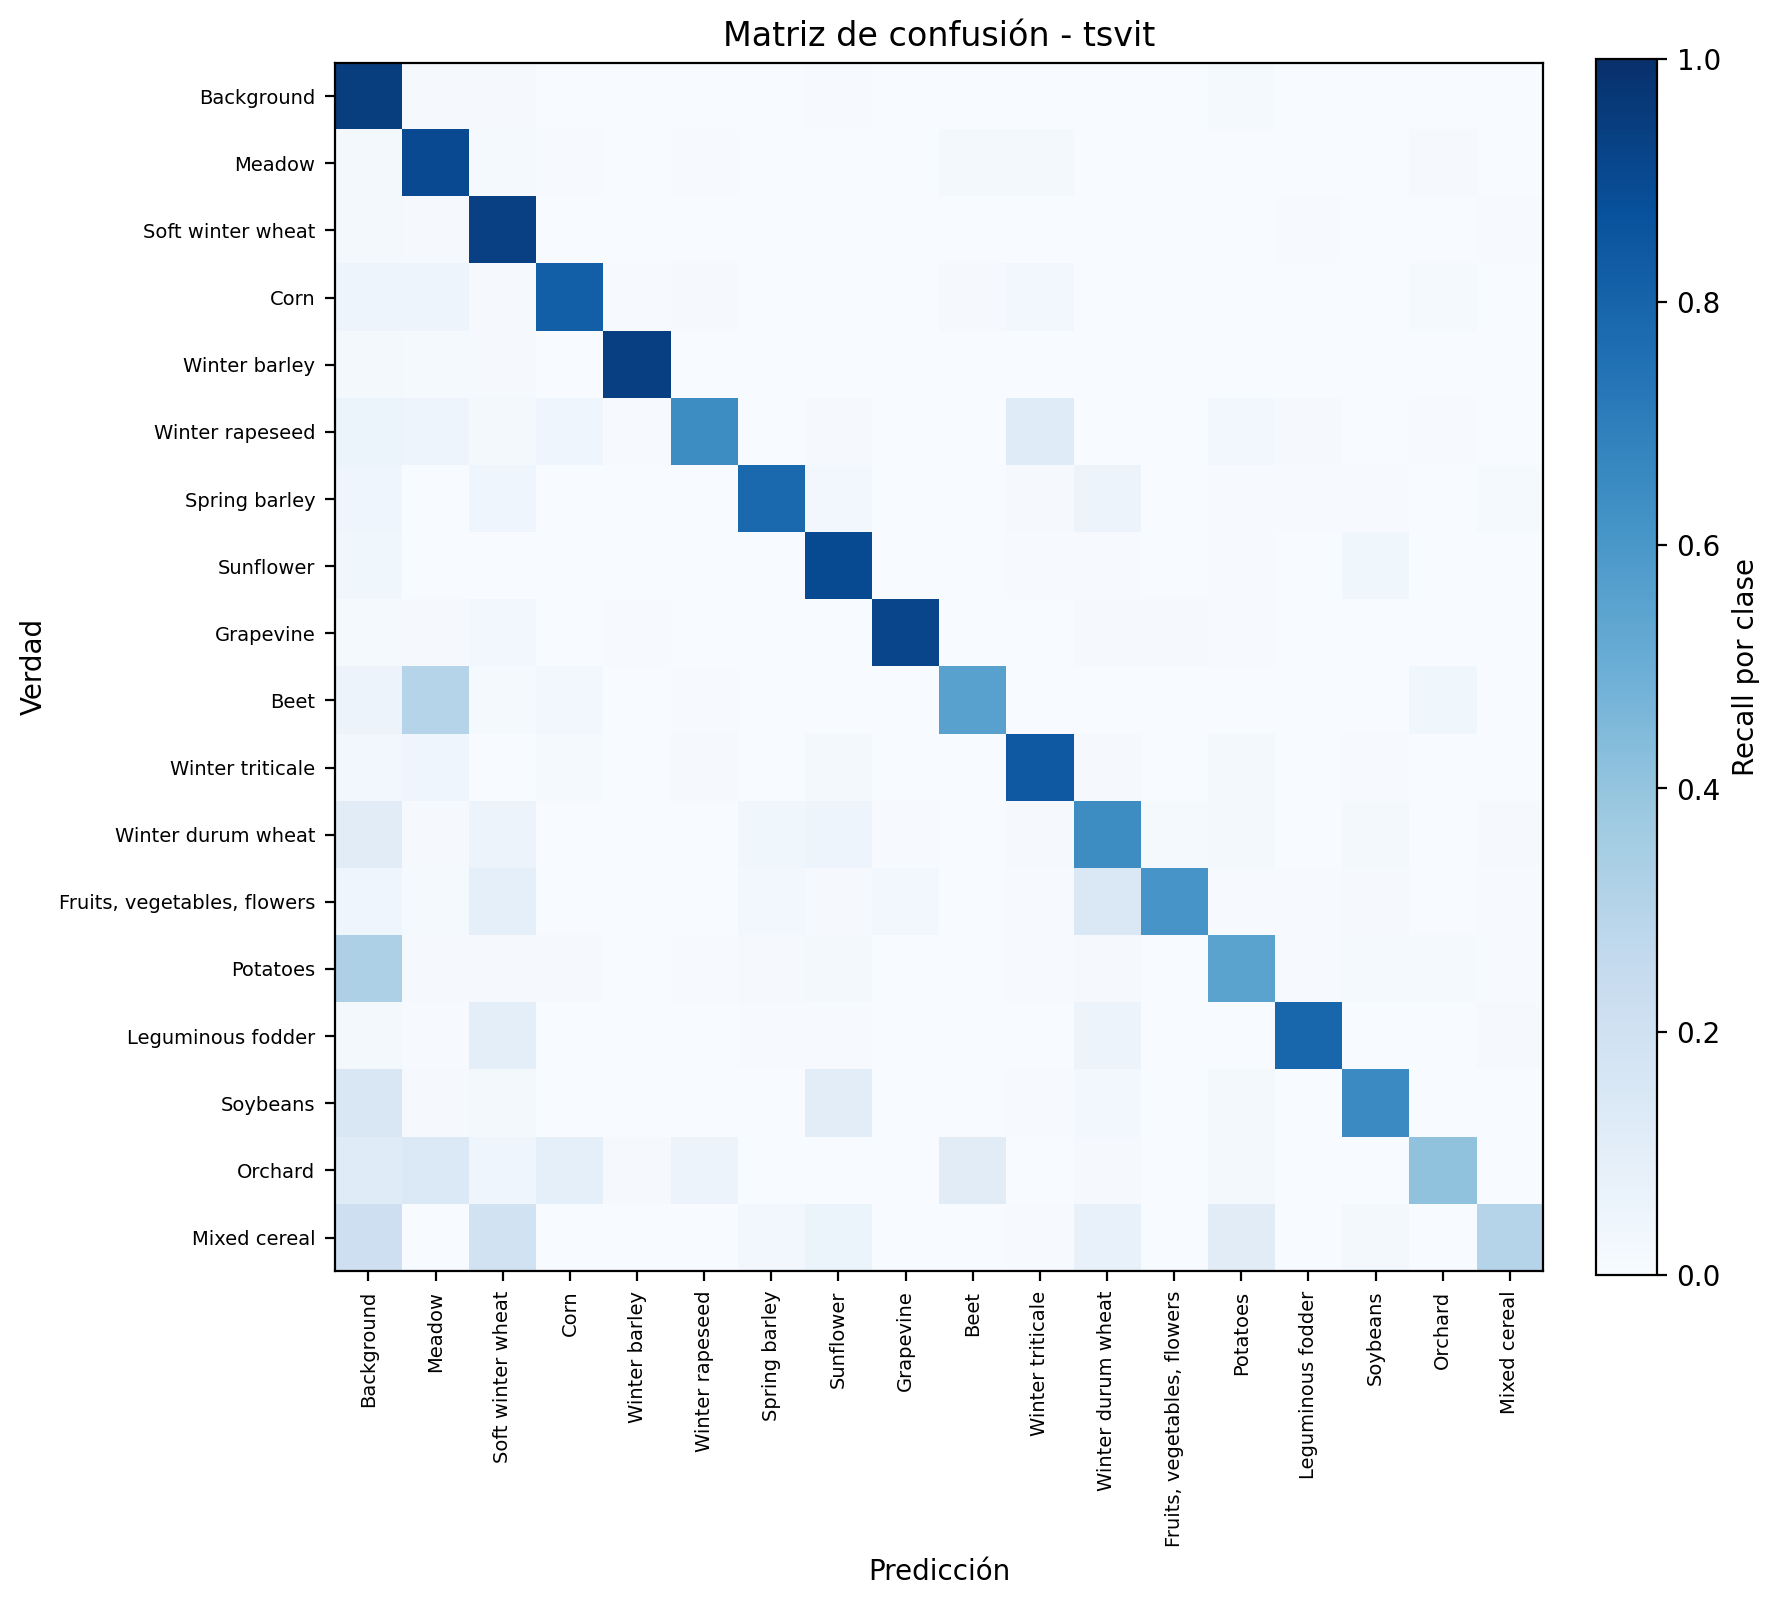

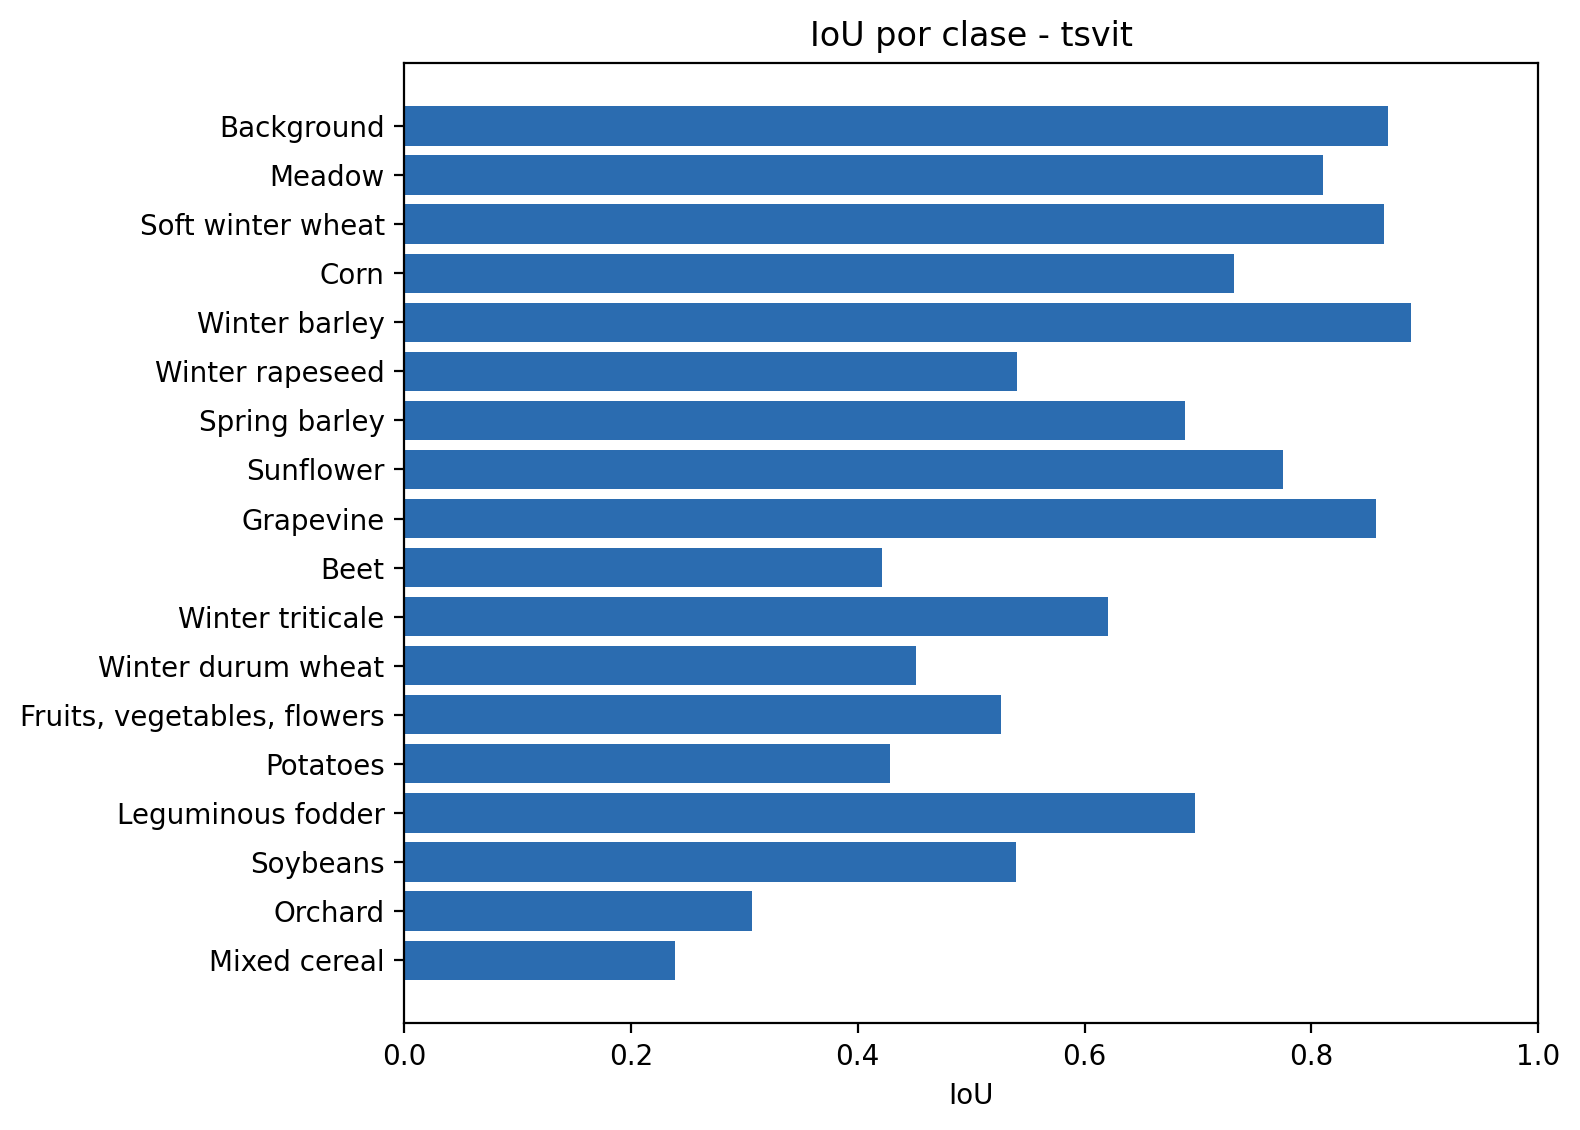

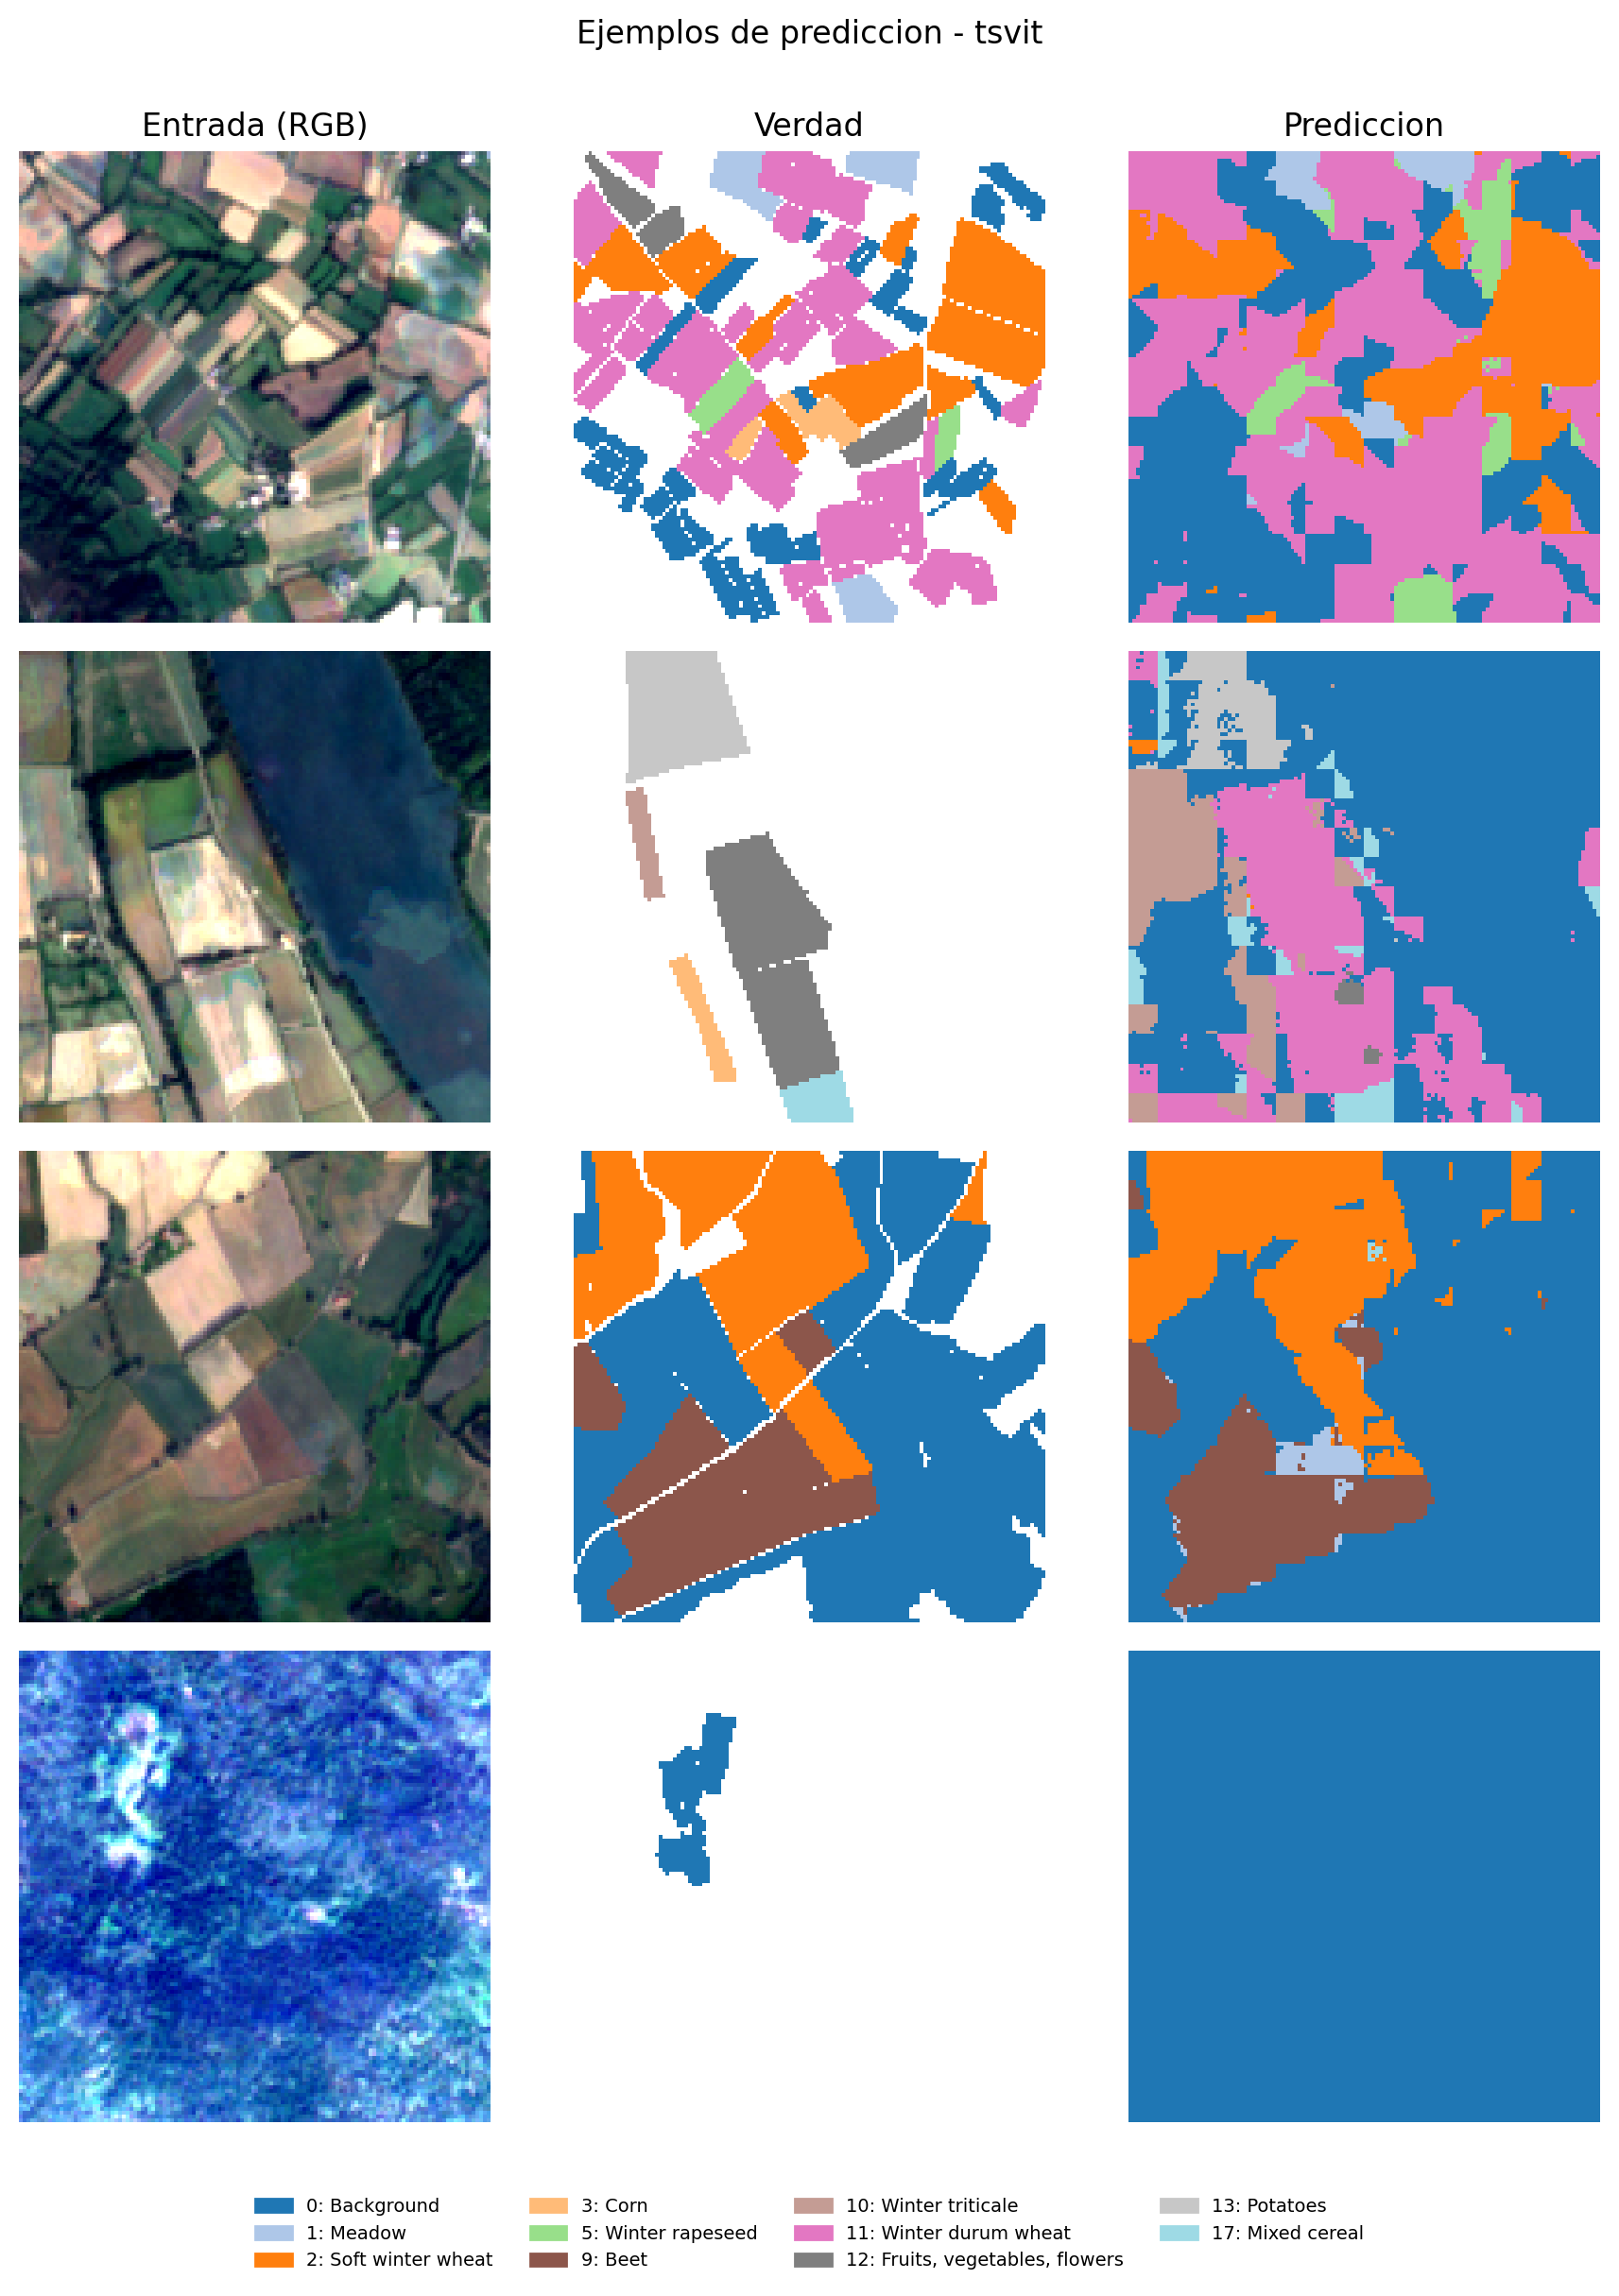

In [15]:
# --- Modelo final + sus reportes visuales ---
from IPython.display import Image, Markdown, display

if table.height:
    _r = table.row(0, named=True)  # top-1 por mIoU = modelo final
    final_model = _r['model']
    # mIoU plano (18 clases) es la metrica principal; el _grouped (6 HCAT) solo
    # lo tienen algunos modelos, se muestra si esta.
    _line = f"**Modelo individual final (por mIoU): `{final_model}`** - mIoU = {_r.get('miou')}"
    if _r.get('f1_macro') is not None:
        _line += f", F1-macro = {_r.get('f1_macro')}"
    if _r.get('miou_grouped') is not None:
        _line += f" (mIoU 6 grupos = {_r.get('miou_grouped')})"
    display(Markdown(_line))
    # El nombre de figura de tsvit-pheno usa la clave 'tsvit' (fallback us-025).
    _fig_key = 'tsvit' if final_model.startswith('tsvit') else final_model
    for _key in ('confusion', 'per_class_iou', 'samples'):
        _f = _find_fig(_key, _fig_key)
        if _f is not None:
            display(Image(filename=str(_f)))
else:
    print('Definir el modelo final tras consolidar los modelos.')

## Conclusiones

Las **6 arquitecturas** sobre PASTIS-R dejan un orden claro cuando se mira el mIoU de las 18 clases planas: los modelos que leen la **serie temporal completa** dominan. TSViT con rama fenológica encabeza con mIoU 0.6253 / F1-macro 0.7500, seguido de TSViT base (0.6215) y U-TAE (0.4742); por debajo quedan AnySat (0.45 en 6 grupos), U-Net (0.24) y los no temporales DeepLabv3+ (0.27) y SegFormer (0.23). La brecha entre TSViT (0.63) y DeepLabv3+ (0.27) mide directamente cuánto aporta el calendario de crecimiento: en una sola fecha muchos cultivos se confunden; a lo largo de la temporada se separan.

El **ajuste fino con Optuna** (30 trials por modelo, warm-start desde el mejor checkpoint en los temporales) confirma que las configuraciones base ya estaban bien elegidas: U-TAE mejora marginalmente (0.4826 -> 0.4854) y AnySat sube su cabeza a 0.63 sobre 6 grupos, pero en ningún caso hay saltos grandes. El tuning aquí vale por robustez, no por rescatar un modelo mal configurado.

El **modelo individual final es `tsvit-pheno`**: mejor métrica por amplio margen, costo de entrenamiento puntual y asumible para el presupuesto L4/H100, y la única vía interpretable del conjunto (atención temporal sobre las fechas + anclaje fenológico por clase). U-TAE queda como alternativa temporal más ligera y AnySat como la opción más eficiente en cómputo.

**Lo que sigue**: llevar `tsvit-pheno` a los ensambles como uno de sus miembros fuertes (voting top-3, stacking), y reentrenar a épocas completas la mejor configuración de hiperparámetros que devolvió Optuna para cada modelo del top-2.